In [1]:
import matplotlib as mpl

# Increase tick label font sizes and tick length/width globally for all plots
mpl.rcParams.update({
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

  NGC4396: 120537 HII pixels
  NGC4501: 299577 HII pixels

Total combined HII pixels: 420114

=== Combined BPT Diagram Summary (HII only) ===
  N2 BPT - Total HII: 420114 (100.0%)
  S2 BPT - Total HII: 420114 (100.0%)

Galaxy breakdown for HII spaxels:
  NGC4396: N2_HII=120537, S2_HII=120537
  NGC4501: N2_HII=299577, S2_HII=299577

Successfully created combined BPT diagrams (HII only) colored by galaxy from 2 galaxies
Galaxies included: NGC4396, NGC4501


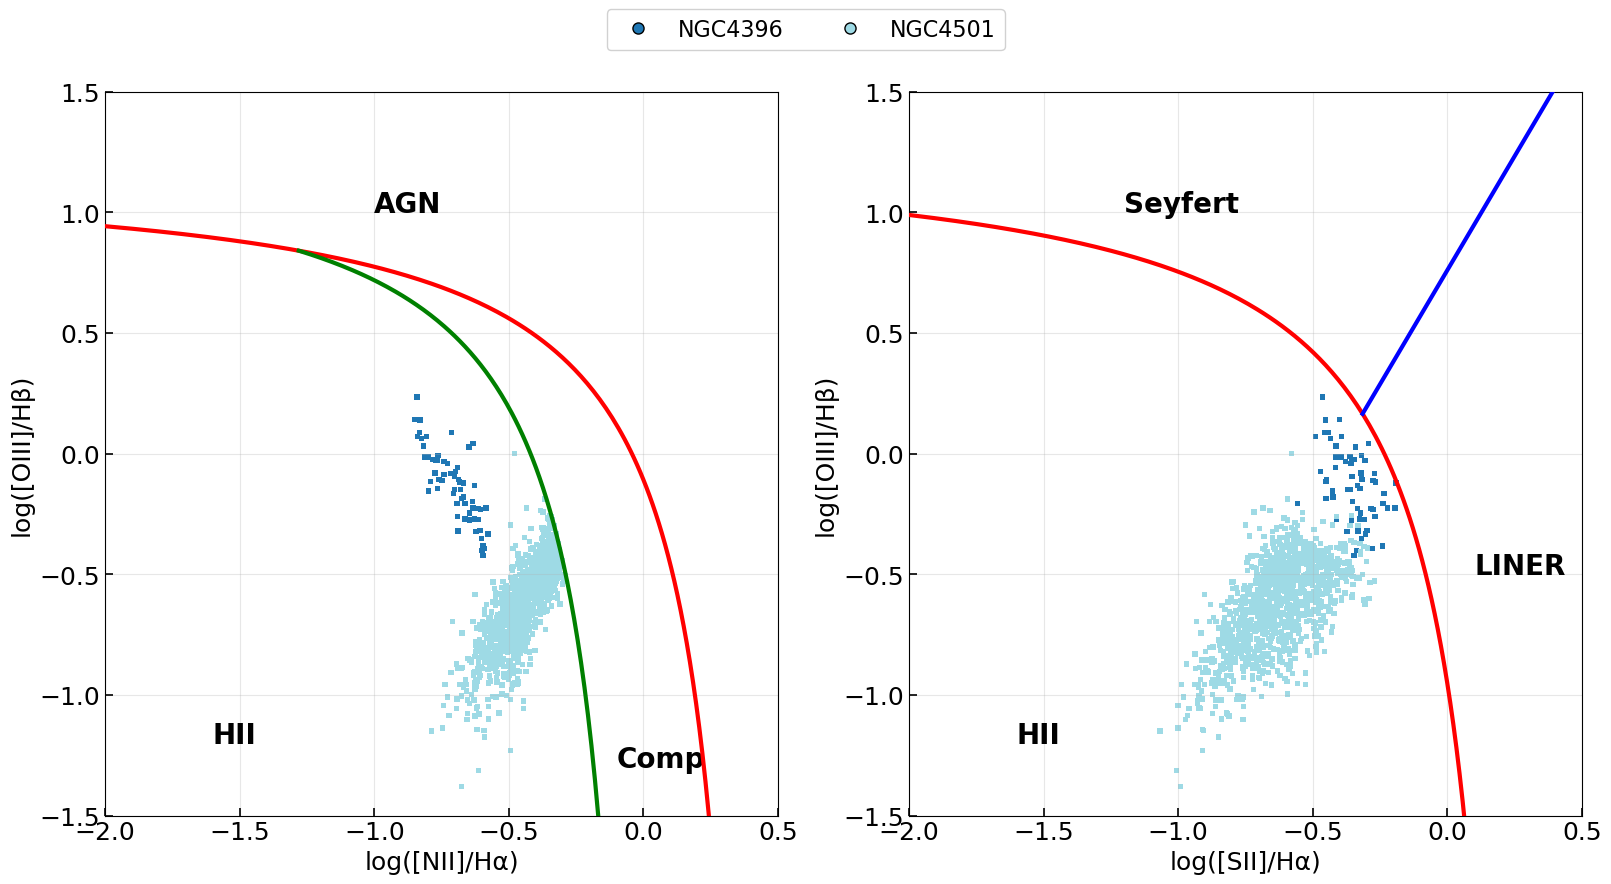

In [2]:
# ------------------------------------------------------------------

# Combined Analysis: NII and SII BPT Diagrams - Color-coded by Galaxy

# Collect all HII spaxels from all galaxies (HII only, no SF)

# Uses common spaxels across all 4 metallicity calibrations

# ------------------------------------------------------------------

import numpy as np

import matplotlib.pyplot as plt

from matplotlib.lines import Line2D

from pathlib import Path

from astropy.io import fits



# BPT reference line functions

def kewley01_N2(x):   # max-starburst

    return 0.61/(x-0.47) + 1.19



def kauff03_N2(x):    # empirical SF upper envelope

    return 0.61/(x-0.05) + 1.30



def kewley01_S2(x):

    return 0.72/(x-0.32) + 1.30



def kewley06_Sy_LIN(x):   # Seyfert/LINER division

    return 1.89*x + 0.76



# Create x arrays for the theoretical lines

x_kewley_N2 = np.linspace(-2.0, 0.3, 200)

x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)

x_kewley_S2 = np.linspace(-2.0, 0.3, 200)

x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)



# Get all galaxies from binning files

bins = sorted(Path('.').glob('*_v3tk_SNR200_spatial_binning_maps_extended.fits'))

galaxies = [f.name.split('_')[0] for f in bins]



# Create galaxy color mapping (consistent for all HII regions)

galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(galaxies)))

galaxy_color_dict = dict(zip(galaxies, galaxy_colors))



# Collect all spaxels from all galaxies - HII only (with galaxy indices)

all_logN2_hii = []

all_logO3_hii = []

all_logS2_hii = []

all_galaxy_indices_hii = []



print("Collecting HII data from all galaxies...")

for gal_idx, gal in enumerate(galaxies):

    gas_file = Path(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits')

    bin_file = Path(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits')



    if gas_file.exists() and bin_file.exists():

        # Load maps for this galaxy

        with fits.open(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits') as h:

            logSigmaM = h['LOGMASS_SURFACE_DENSITY'].data

        with fits.open(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits') as h:

            # HII quantities

            logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data

            oh_d16_HII = h['O_H_D16_HII'].data

            oh_pg16_HII = h['O_H_PG16_HII'].data

            oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data

            oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data



            # Load corrected emission line fluxes

            HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data

            HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data

            OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data

            NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data

            SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data

            SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data



        # Find common spaxels for HII

        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 

                           np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 

                           np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII) &

                           np.isfinite(HB4861_FLUX_corr) & np.isfinite(HA6562_FLUX_corr) &

                           np.isfinite(OIII5006_FLUX_corr) & np.isfinite(NII6583_FLUX_corr) &

                           np.isfinite(SII6716_FLUX_corr) & np.isfinite(SII6730_FLUX_corr))



        n_pixels_HII = np.sum(common_mask_HII)

        print(f"  {gal}: {n_pixels_HII} HII pixels")



        # Apply common_mask to get valid spaxels - HII

        HB_common_HII = HB4861_FLUX_corr[common_mask_HII]

        HA_common_HII = HA6562_FLUX_corr[common_mask_HII]

        OIII_common_HII = OIII5006_FLUX_corr[common_mask_HII]

        NII_common_HII = NII6583_FLUX_corr[common_mask_HII]

        SII6716_common_HII = SII6716_FLUX_corr[common_mask_HII]

        SII6730_common_HII = SII6730_FLUX_corr[common_mask_HII]



        # Calculate line ratios - HII

        logN2_hii = np.log10(NII_common_HII / HA_common_HII)

        logO3_hii = np.log10(OIII_common_HII / HB_common_HII)

        logS2_hii = np.log10((SII6716_common_HII + SII6730_common_HII) / HA_common_HII)



        # Append to combined arrays - HII only

        all_logN2_hii.extend(logN2_hii.flatten())

        all_logO3_hii.extend(logO3_hii.flatten())

        all_logS2_hii.extend(logS2_hii.flatten())

        all_galaxy_indices_hii.extend([gal_idx] * len(logN2_hii.flatten()))

    else:

        print(f"  {gal}: Data files not found")



# Convert to numpy arrays - HII

all_logN2_hii = np.array(all_logN2_hii)

all_logO3_hii = np.array(all_logO3_hii)

all_logS2_hii = np.array(all_logS2_hii)

all_galaxy_indices_hii = np.array(all_galaxy_indices_hii)



print(f"\nTotal combined HII pixels: {len(all_logN2_hii)}")



# Apply BPT classifications - HII only

mask_N2_HII = all_logO3_hii <= kauff03_N2(all_logN2_hii)

mask_N2_Comp = (all_logO3_hii > kauff03_N2(all_logN2_hii)) & (all_logO3_hii <= kewley01_N2(all_logN2_hii))

mask_N2_AGN = all_logO3_hii > kewley01_N2(all_logN2_hii)



mask_S2_HII = all_logO3_hii <= kewley01_S2(all_logS2_hii)

mask_S2_above_kewley = all_logO3_hii > kewley01_S2(all_logS2_hii)

mask_S2_LINER = mask_S2_above_kewley & (all_logO3_hii <= kewley06_Sy_LIN(all_logS2_hii))

mask_S2_Seyfert = mask_S2_above_kewley & (all_logO3_hii > kewley06_Sy_LIN(all_logS2_hii))



mask_HII_N2 = mask_N2_HII | mask_N2_Comp

mask_HII_S2 = mask_S2_HII



# Create BPT diagrams: HII only (single row, two panels)

# Use constrained_layout for better spacing with legend

fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)



# ===== HII REGIONS ONLY =====



# NII BPT Diagram - HII

ax = axes[0]



for gal_idx, gal in enumerate(galaxies):

    gal_mask = (all_galaxy_indices_hii == gal_idx) & mask_HII_N2

    if np.sum(gal_mask) > 0:

        ax.scatter(all_logN2_hii[gal_mask], all_logO3_hii[gal_mask], 

                   color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4, 

                   edgecolors='none', rasterized=True)



ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=3, label='Kewley+01', zorder=10)

ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=3, label='Kauffmann+03', zorder=10)



hii_count_N2 = np.sum(mask_HII_N2)

total_common_hii = len(all_logN2_hii)

hii_percent_N2 = hii_count_N2 / total_common_hii * 100 if total_common_hii > 0 else 0



ax.set_xlabel('log([NII]/Hα)', fontsize=18)

ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)

ax.tick_params(axis='both', which='major', labelsize=18)

ax.set_xlim(-2.0, 0.5)

ax.set_ylim(-1.5, 1.5)

# ax.set_title('NII BPT (Common HII spaxels by Galaxy)', fontsize=14)

ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')

ax.text(-0.1, -1.3, 'Comp', fontsize=20, fontweight='bold')

ax.text(-1.0, 1.0, 'AGN', fontsize=20, fontweight='bold')

ax.grid(True, alpha=0.3)



# SII BPT Diagram - HII

ax = axes[1]



for gal_idx, gal in enumerate(galaxies):

    gal_mask = (all_galaxy_indices_hii == gal_idx) & mask_HII_S2

    if np.sum(gal_mask) > 0:

        ax.scatter(all_logS2_hii[gal_mask], all_logO3_hii[gal_mask], 

                   color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4, 

                   edgecolors='none', rasterized=True)



ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=3, label='Kewley+01', zorder=10)

ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=3, label='Kewley+06', zorder=10)



hii_count_S2 = np.sum(mask_HII_S2)

hii_percent_S2 = hii_count_S2 / total_common_hii * 100 if total_common_hii > 0 else 0



ax.set_xlabel('log([SII]/Hα)', fontsize=18)

ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)

ax.tick_params(axis='both', which='major', labelsize=18)

ax.set_xlim(-2.0, 0.5)

ax.set_ylim(-1.5, 1.5)

# ax.set_title('SII BPT (Common HII spaxels by Galaxy)', fontsize=14)

ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')

ax.text(-1.2, 1.0, 'Seyfert', fontsize=20, fontweight='bold')

ax.text(0.1, -0.5, 'LINER', fontsize=20, fontweight='bold')

ax.grid(True, alpha=0.3)



# Build custom legend handles with larger markers

legend_handles = []

legend_labels = []

for gal_idx, gal in enumerate(galaxies):

    legend_handles.append(Line2D([0], [0], marker='o', color='none', 

                                 markerfacecolor=galaxy_colors[gal_idx], markersize=8, linestyle='None'))

    legend_labels.append(f'{gal}')



# Put legend above the axes at 1.1 (outside plot)

fig.legend(legend_handles, legend_labels, loc='upper center',

           bbox_to_anchor=(0.5, 1.1),

           ncol=min(len(legend_labels), 7), fontsize=16, framealpha=0.9)



# Save PNG tightly cropped, PDF with standard bbox (no cropping of legend)

# fig.savefig('Plot_Paper_1_referee/Combined_BPT_diagrams_by_Galaxy_HII.png', dpi=600, bbox_inches='tight', pad_inches=0.05)

# fig.savefig('Plot_Paper_1_referee/Combined_BPT_diagrams_by_Galaxy_HII.pdf', dpi=600, bbox_inches='tight', pad_inches=0.05)



# Print summary statistics (HII only)

print(f"\n=== Combined BPT Diagram Summary (HII only) ===")

print(f"  N2 BPT - Total HII: {hii_count_N2} ({hii_percent_N2:.1f}%)")

print(f"  S2 BPT - Total HII: {hii_count_S2} ({hii_percent_S2:.1f}%)")



# Print galaxy breakdown for HII spaxels

print(f"\nGalaxy breakdown for HII spaxels:")

for gal_idx, gal in enumerate(galaxies):

    gal_n2 = np.sum((all_galaxy_indices_hii == gal_idx) & mask_HII_N2)

    gal_s2 = np.sum((all_galaxy_indices_hii == gal_idx) & mask_HII_S2)

    print(f"  {gal}: N2_HII={gal_n2}, S2_HII={gal_s2}")



print(f"\nSuccessfully created combined BPT diagrams (HII only) colored by galaxy from {len(galaxies)} galaxies")

print(f"Galaxies included: {', '.join(galaxies)}")


In [3]:
# # ------------------------------------------------------------------

# # Combined Analysis: NII and SII diagrams - Color-coded by Galaxy

# # Collect all spaxels from all galaxies (no HII-only selection)

# # Use only dust-corrected emission line fluxes; no O/H needed

# # Apply SFR mask: keep spaxels with finite LOGSFR_SURFACE_DENSITY_HII

# #                  or LOGSFR_SURFACE_DENSITY_NONHII

# # ------------------------------------------------------------------

# import numpy as np

# import matplotlib.pyplot as plt

# from matplotlib.lines import Line2D

# from pathlib import Path

# from astropy.io import fits



# # BPT reference line functions (for drawing curves only, if desired)

# def kewley01_N2(x):   # max-starburst

#     return 0.61/(x-0.47) + 1.19



# def kauff03_N2(x):    # empirical SF upper envelope

#     return 0.61/(x-0.05) + 1.30



# def kewley01_S2(x):

#     return 0.72/(x-0.32) + 1.30



# def kewley06_Sy_LIN(x):   # Seyfert/LINER division

#     return 1.89*x + 0.76



# # Create x arrays for the theoretical lines (optional overlay)

# x_kewley_N2 = np.linspace(-2.0, 0.3, 200)

# x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)

# x_kewley_S2 = np.linspace(-2.0, 0.3, 200)

# x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)



# # Get all galaxies from binning files

# bins = sorted(Path('.').glob('*_v3tk_SNR200_spatial_binning_maps_extended.fits'))

# galaxies = [f.name.split('_')[0] for f in bins]



# # Create galaxy color mapping (consistent for all spaxels)

# galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(galaxies)))

# galaxy_color_dict = dict(zip(galaxies, galaxy_colors))



# # Collect all spaxels from all galaxies (no HII selection), with galaxy indices

# all_logN2 = []

# all_logO3 = []

# all_logS2 = []

# all_galaxy_indices = []



# print("Collecting all spaxels from all galaxies (using corrected fluxes only, with SFR mask)...")

# for gal_idx, gal in enumerate(galaxies):

#     gas_file = Path(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits')

#     bin_file = Path(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits')



#     if gas_file.exists() and bin_file.exists():

#         with fits.open(gas_file) as h:

#             # Load corrected emission line fluxes

#             HB4861_FLUX_corr = h['HB4861_FLUX_CORR'].data

#             HA6562_FLUX_corr = h['HA6562_FLUX_CORR'].data

#             OIII5006_FLUX_corr = h['OIII5006_FLUX_CORR'].data

#             NII6583_FLUX_corr = h['NII6583_FLUX_CORR'].data

#             SII6716_FLUX_corr = h['SII6716_FLUX_CORR'].data

#             SII6730_FLUX_corr = h['SII6730_FLUX_CORR'].data



#             # Load SFR surface density maps (HII and NONHII)

#             logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data

#             logSigmaSFR_NONHII = h['LOGSFR_SURFACE_DENSITY_NONHII'].data



#         # Valid where all corrected line fluxes are finite and positive

#         flux_mask = (

#             np.isfinite(HB4861_FLUX_corr) & (HB4861_FLUX_corr > 0) &

#             np.isfinite(HA6562_FLUX_corr) & (HA6562_FLUX_corr > 0) &

#             np.isfinite(OIII5006_FLUX_corr) & (OIII5006_FLUX_corr > 0) &

#             np.isfinite(NII6583_FLUX_corr) & (NII6583_FLUX_corr > 0) &

#             np.isfinite(SII6716_FLUX_corr) & (SII6716_FLUX_corr > 0) &

#             np.isfinite(SII6730_FLUX_corr) & (SII6730_FLUX_corr > 0)

#         )



#         # SFR mask: keep spaxels where either HII or NONHII SFR is finite

#         sfr_mask = (np.isfinite(logSigmaSFR_HII) | np.isfinite(logSigmaSFR_NONHII))



#         # Combined mask

#         valid_mask = flux_mask & sfr_mask



#         n_pixels = np.sum(valid_mask)

#         print(f"  {gal}: {n_pixels} valid spaxels (flux+SFR mask)")



#         HB_common = HB4861_FLUX_corr[valid_mask]

#         HA_common = HA6562_FLUX_corr[valid_mask]

#         OIII_common = OIII5006_FLUX_corr[valid_mask]

#         NII_common = NII6583_FLUX_corr[valid_mask]

#         SII6716_common = SII6716_FLUX_corr[valid_mask]

#         SII6730_common = SII6730_FLUX_corr[valid_mask]



#         # Calculate line ratios for all valid spaxels

#         logN2 = np.log10(NII_common / HA_common)

#         logO3 = np.log10(OIII_common / HB_common)

#         logS2 = np.log10((SII6716_common + SII6730_common) / HA_common)



#         all_logN2.extend(logN2.flatten())

#         all_logO3.extend(logO3.flatten())

#         all_logS2.extend(logS2.flatten())

#         all_galaxy_indices.extend([gal_idx] * len(logN2.flatten()))

#     else:

#         print(f"  {gal}: Data files not found")



# # Convert to numpy arrays

# all_logN2 = np.array(all_logN2)

# all_logO3 = np.array(all_logO3)

# all_logS2 = np.array(all_logS2)

# all_galaxy_indices = np.array(all_galaxy_indices)



# print(f"\nTotal combined valid spaxels (flux+SFR mask): {len(all_logN2)}")



# # Create diagrams for all spaxels (colored by galaxy), no BPT masks

# fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)



# # NII diagram

# ax = axes[0]

# for gal_idx, gal in enumerate(galaxies):

#     gal_mask = (all_galaxy_indices == gal_idx)

#     if np.sum(gal_mask) > 0:

#         ax.scatter(all_logN2[gal_mask], all_logO3[gal_mask],

#                    color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4,

#                    edgecolors='none', rasterized=True)



# # Optional: overlay BPT curves as reference only

# ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=2, label='Kewley+01', zorder=10)

# ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=2, label='Kauffmann+03', zorder=10)



# ax.set_xlabel('log([NII]/Hα)', fontsize=18)

# ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)

# ax.tick_params(axis='both', which='major', labelsize=18)

# ax.set_xlim(-2.0, 0.5)

# ax.set_ylim(-1.5, 1.5)

# ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')

# ax.text(-0.1, -1.3, 'Comp', fontsize=20, fontweight='bold')

# ax.text(-1.0, 1.0, 'AGN', fontsize=20, fontweight='bold')

# ax.grid(True, alpha=0.3)



# # SII diagram

# ax = axes[1]

# for gal_idx, gal in enumerate(galaxies):

#     gal_mask = (all_galaxy_indices == gal_idx)

#     if np.sum(gal_mask) > 0:

#         ax.scatter(all_logS2[gal_mask], all_logO3[gal_mask],

#                    color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4,

#                    edgecolors='none', rasterized=True)



# ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=2, label='Kewley+01', zorder=10)

# ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=2, label='Kewley+06', zorder=10)



# ax.set_xlabel('log([SII]/Hα)', fontsize=18)

# ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)

# ax.tick_params(axis='both', which='major', labelsize=18)

# ax.set_xlim(-2.0, 0.5)

# ax.set_ylim(-1.5, 1.5)

# # ax.set_title('SII BPT (Common HII spaxels by Galaxy)', fontsize=14)

# ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')

# ax.text(-1.2, 1.0, 'Seyfert', fontsize=20, fontweight='bold')

# ax.text(0.1, -0.5, 'LINER', fontsize=20, fontweight='bold')

# ax.grid(True, alpha=0.3)



# # Build custom legend handles with larger markers

# legend_handles = []

# legend_labels = []

# for gal_idx, gal in enumerate(galaxies):

#     legend_handles.append(Line2D([0], [0], marker='o', color='none',

#                                  markerfacecolor=galaxy_colors[gal_idx], markersize=8, linestyle='None'))

#     legend_labels.append(f'{gal}')



# # Put legend above the axes at 1.1 (outside plot)

# fig.legend(legend_handles, legend_labels, loc='upper center',

#            bbox_to_anchor=(0.5, 1.1),

#            ncol=min(len(legend_labels), 7), fontsize=16, framealpha=0.9)



# # Save figures

# fig.savefig('Plot_Paper_1_referee/Combined_BPT_diagrams_by_Galaxy_HII_NONHII.png', dpi=600, bbox_inches='tight', pad_inches=0.05)

# fig.savefig('Plot_Paper_1_referee/Combined_BPT_diagrams_by_Galaxy_HII_NONHII.pdf', dpi=600, bbox_inches='tight', pad_inches=0.05)



# print(f"\nSuccessfully created combined NII/SII diagrams (flux+SFR mask, no BPT masks) colored by galaxy from {len(galaxies)} galaxies")

# print(f"Galaxies included: {', '.join(galaxies)}")


  NGC4396: 155296 valid spaxels (flux+SFR mask)
  NGC4501: 621832 valid spaxels (flux+SFR mask)

Total combined valid spaxels (flux+SFR mask): 777128

SFR component counts (finite spaxels, all galaxies combined):
  HII: 420395 (53.918%)
  NONHII: 351928 (45.137%)
  UNCLASSIFIED2: 7369 (0.945%)

SF component counts (finite spaxels, all galaxies combined):
  SF: 600628 (77.034%)
  NONSF: 76396 (9.798%)
  UNCLASSIFIED1: 7369 (0.945%)

Mean log-error (spaxel subsets):
  HII only       - log([NII]/Hα): 0.0005, log([SII]/Hα): 0.0005, log([OIII]/Hβ): 0.0013
  NONHII only    - log([NII]/Hα): 0.0036, log([SII]/Hα): 0.0029, log([OIII]/Hβ): 0.0044
  UNCLASS only   - log([NII]/Hα): 0.0011, log([SII]/Hα): 0.0020, log([OIII]/Hβ): 0.0035
  HII+NONHII     - log([NII]/Hα): 0.0019, log([SII]/Hα): 0.0016, log([OIII]/Hβ): 0.0027
  HII+NONHII+UNC - log([NII]/Hα): 0.0019, log([SII]/Hα): 0.0016, log([OIII]/Hβ): 0.0027


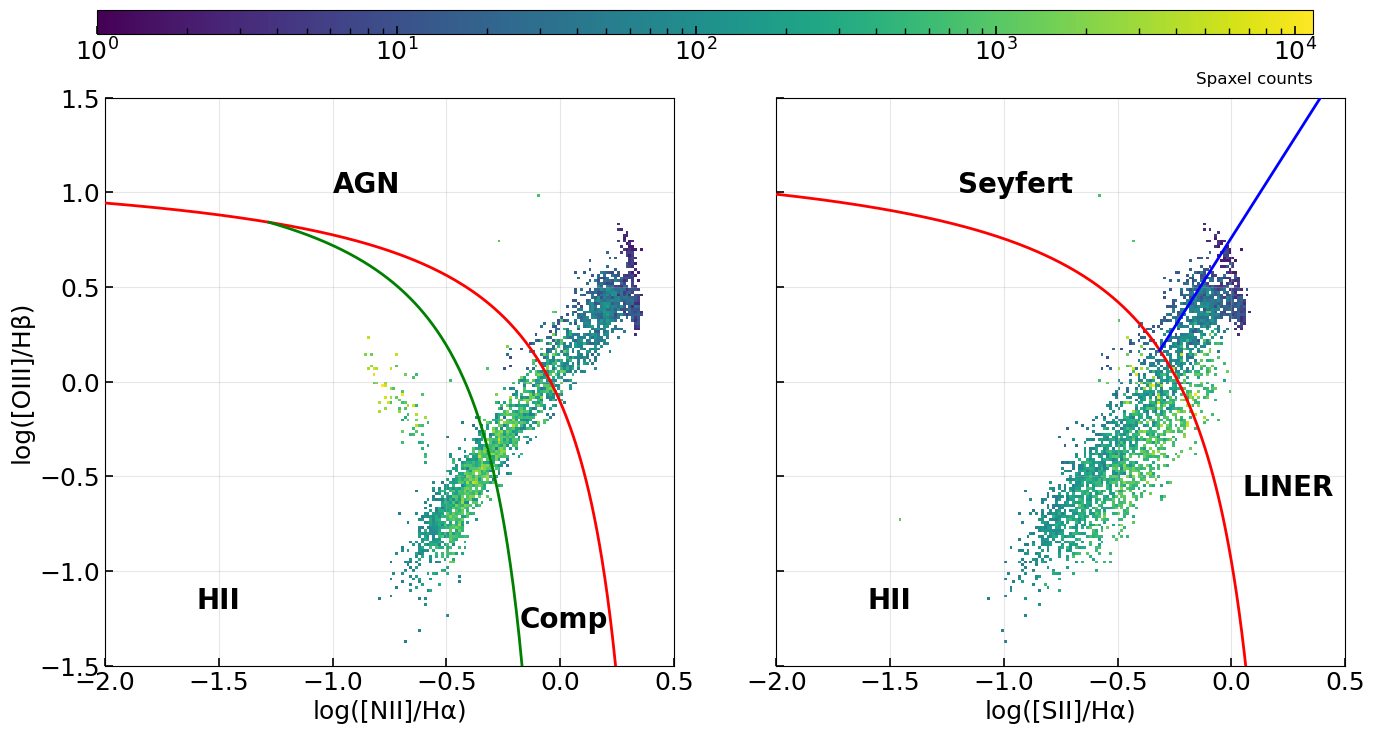


Successfully created combined NII/SII diagrams (flux+SFR mask, no BPT masks) as 2D spaxel density
Galaxies included: NGC4396, NGC4501


In [4]:
# ------------------------------------------------------------------
# Combined Analysis: NII and SII diagrams - 2D spaxel density
# Collect all spaxels from all galaxies (no HII-only selection)
# Use only dust-corrected emission line fluxes; no O/H needed
# Apply SFR mask: keep spaxels with finite LOGSFR_SURFACE_DENSITY_HII,
#                  LOGSFR_SURFACE_DENSITY_NONHII, or LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
from astropy.io import fits


# BPT reference line functions (for drawing curves only, if desired)
def kewley01_N2(x):   # max-starburst
    return 0.61/(x-0.47) + 1.19


def kauff03_N2(x):    # empirical SF upper envelope
    return 0.61/(x-0.05) + 1.30


def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30


def kewley06_Sy_LIN(x):   # Seyfert/LINER division
    return 1.89*x + 0.76


# Error propagation for BPT ratios (log10 numerator/denominator)
def bpt_error_propagation(numerator, denominator, numerator_err, denominator_err):
    with np.errstate(divide='ignore', invalid='ignore'):
        log_ratio_err = 1/(np.log(10)) * np.sqrt((numerator_err / numerator)**2 + (denominator_err / denominator)**2)
        return log_ratio_err


# Create x arrays for the theoretical lines (optional overlay)
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)


# Get all galaxies from binning files
bins = sorted(Path('.').glob('*_v3tk_SNR200_spatial_binning_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]


# Collect all spaxels from all galaxies (no HII selection)
all_logN2 = []
all_logO3 = []
all_logS2 = []

# Stats for SFR components
count_hii = 0
count_nonhii = 0
count_unclass = 0
count_union = 0
sum_check_total = 0
sum_check_ok = 0
sum_check_maxabs = []

# Stats for SF/NONSF/UNCLASSIFIED1 components
count_sf = 0
count_nonsf = 0
count_unclass1 = 0
count_union_sf = 0

# Error arrays for spaxel subsets
err_hii_logN2, err_hii_logS2, err_hii_logO3 = [], [], []
err_nonhii_logN2, err_nonhii_logS2, err_nonhii_logO3 = [], [], []
err_unclass_logN2, err_unclass_logS2, err_unclass_logO3 = [], [], []
err_hii_nonhii_logN2, err_hii_nonhii_logS2, err_hii_nonhii_logO3 = [], [], []
err_allclasses_logN2, err_allclasses_logS2, err_allclasses_logO3 = [], [], []

print("Collecting all spaxels from all galaxies (using corrected fluxes only, with SFR mask)...")
for gal in galaxies:
    gas_file = Path(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits')
    bin_file = Path(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits')

    if gas_file.exists() and bin_file.exists():
        with fits.open(gas_file) as h:
            # Load corrected emission line fluxes
            HB4861_FLUX_corr = h['HB4861_FLUX_CORR'].data
            HA6562_FLUX_corr = h['HA6562_FLUX_CORR'].data
            OIII5006_FLUX_corr = h['OIII5006_FLUX_CORR'].data
            NII6583_FLUX_corr = h['NII6583_FLUX_CORR'].data
            SII6716_FLUX_corr = h['SII6716_FLUX_CORR'].data
            SII6730_FLUX_corr = h['SII6730_FLUX_CORR'].data

            # Load corrected emission line flux errors
            HB4861_FLUX_ERR = h['HB4861_FLUX_ERR'].data
            HA6562_FLUX_ERR = h['HA6562_FLUX_ERR'].data
            OIII5006_FLUX_ERR = h['OIII5006_FLUX_ERR'].data
            NII6583_FLUX_ERR = h['NII6583_FLUX_ERR'].data
            SII6716_FLUX_ERR = h['SII6716_FLUX_ERR'].data
            SII6730_FLUX_ERR = h['SII6730_FLUX_ERR'].data

            # Load SFR surface density maps
            logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
            logSigmaSFR_NONHII = h['LOGSFR_SURFACE_DENSITY_NONHII'].data
            logSigmaSFR_UNCLASS = h['LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2'].data
            logSigmaSFR_TOTAL = h['LOGSFR_SURFACE_DENSITY'].data

            # Load SF / NONSF / UNCLASSIFIED1 maps
            logSigmaSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
            logSigmaSFR_NONSF = h['LOGSFR_SURFACE_DENSITY_NONSF'].data
            logSigmaSFR_UNCLASS1 = h['LOGSFR_SURFACE_DENSITY_UNCLASSIFIED1'].data

        # SFR masks
        hii_mask = np.isfinite(logSigmaSFR_HII)
        nonhii_mask = np.isfinite(logSigmaSFR_NONHII)
        unclass_mask = np.isfinite(logSigmaSFR_UNCLASS)
        total_mask = np.isfinite(logSigmaSFR_TOTAL)
        union_mask = hii_mask | nonhii_mask | unclass_mask

        count_hii += np.sum(hii_mask)
        count_nonhii += np.sum(nonhii_mask)
        count_unclass += np.sum(unclass_mask)
        count_union += np.sum(union_mask)

        # SF / NONSF / UNCLASSIFIED1 masks
        sf_mask = np.isfinite(logSigmaSFR_SF)
        nonsf_mask = np.isfinite(logSigmaSFR_NONSF)
        unclass1_mask = np.isfinite(logSigmaSFR_UNCLASS1)
        union_sf_mask = sf_mask | nonsf_mask | unclass1_mask

        count_sf += np.sum(sf_mask)
        count_nonsf += np.sum(nonsf_mask)
        count_unclass1 += np.sum(unclass1_mask)
        count_union_sf += np.sum(union_sf_mask)

        # Check add-up consistency where all components and total are finite
        sum_mask = hii_mask & nonhii_mask & unclass_mask & total_mask
        if np.any(sum_mask):
            diff = logSigmaSFR_TOTAL[sum_mask] - (
                logSigmaSFR_HII[sum_mask] + logSigmaSFR_NONHII[sum_mask] + logSigmaSFR_UNCLASS[sum_mask]
            )
            sum_check_total += diff.size
            sum_check_ok += np.sum(np.isclose(diff, 0.0, atol=1e-6, rtol=0))
            sum_check_maxabs.append(np.nanmax(np.abs(diff)))

        # Valid where all corrected line fluxes are finite and positive
        flux_mask = (
            np.isfinite(HB4861_FLUX_corr) & (HB4861_FLUX_corr > 0) &
            np.isfinite(HA6562_FLUX_corr) & (HA6562_FLUX_corr > 0) &
            np.isfinite(OIII5006_FLUX_corr) & (OIII5006_FLUX_corr > 0) &
            np.isfinite(NII6583_FLUX_corr) & (NII6583_FLUX_corr > 0) &
            np.isfinite(SII6716_FLUX_corr) & (SII6716_FLUX_corr > 0) &
            np.isfinite(SII6730_FLUX_corr) & (SII6730_FLUX_corr > 0)
        )

        # SFR mask: keep spaxels where any class is finite
        sfr_mask = union_mask

        # Combined mask for plotting
        valid_mask = flux_mask & sfr_mask
        n_pixels = np.sum(valid_mask)
        print(f"  {gal}: {n_pixels} valid spaxels (flux+SFR mask)")

        HB_common = HB4861_FLUX_corr[valid_mask]
        HA_common = HA6562_FLUX_corr[valid_mask]
        OIII_common = OIII5006_FLUX_corr[valid_mask]
        NII_common = NII6583_FLUX_corr[valid_mask]
        SII6716_common = SII6716_FLUX_corr[valid_mask]
        SII6730_common = SII6730_FLUX_corr[valid_mask]

        # Calculate line ratios for all valid spaxels
        logN2 = np.log10(NII_common / HA_common)
        logO3 = np.log10(OIII_common / HB_common)
        logS2 = np.log10((SII6716_common + SII6730_common) / HA_common)

        all_logN2.extend(logN2.flatten())
        all_logO3.extend(logO3.flatten())
        all_logS2.extend(logS2.flatten())

        # Error propagation for spaxel subsets
        err_mask = (
            np.isfinite(HB4861_FLUX_ERR) & (HB4861_FLUX_ERR > 0) &
            np.isfinite(HA6562_FLUX_ERR) & (HA6562_FLUX_ERR > 0) &
            np.isfinite(OIII5006_FLUX_ERR) & (OIII5006_FLUX_ERR > 0) &
            np.isfinite(NII6583_FLUX_ERR) & (NII6583_FLUX_ERR > 0) &
            np.isfinite(SII6716_FLUX_ERR) & (SII6716_FLUX_ERR > 0) &
            np.isfinite(SII6730_FLUX_ERR) & (SII6730_FLUX_ERR > 0)
        )

        def collect_errs(sub_mask, out_N2, out_S2, out_O3):
            valid_err_mask = flux_mask & err_mask & sub_mask
            if np.any(valid_err_mask):
                hb = HB4861_FLUX_corr[valid_err_mask]
                ha = HA6562_FLUX_corr[valid_err_mask]
                o3 = OIII5006_FLUX_corr[valid_err_mask]
                n2 = NII6583_FLUX_corr[valid_err_mask]
                s2_1 = SII6716_FLUX_corr[valid_err_mask]
                s2_2 = SII6730_FLUX_corr[valid_err_mask]

                hb_err = HB4861_FLUX_ERR[valid_err_mask]
                ha_err = HA6562_FLUX_ERR[valid_err_mask]
                o3_err = OIII5006_FLUX_ERR[valid_err_mask]
                n2_err = NII6583_FLUX_ERR[valid_err_mask]
                s2_1_err = SII6716_FLUX_ERR[valid_err_mask]
                s2_2_err = SII6730_FLUX_ERR[valid_err_mask]

                s2 = s2_1 + s2_2
                s2_err = np.sqrt(s2_1_err**2 + s2_2_err**2)

                err_logN2 = bpt_error_propagation(n2, ha, n2_err, ha_err)
                err_logS2 = bpt_error_propagation(s2, ha, s2_err, ha_err)
                err_logO3 = bpt_error_propagation(o3, hb, o3_err, hb_err)

                out_N2.extend(err_logN2[np.isfinite(err_logN2)])
                out_S2.extend(err_logS2[np.isfinite(err_logS2)])
                out_O3.extend(err_logO3[np.isfinite(err_logO3)])

        collect_errs(hii_mask, err_hii_logN2, err_hii_logS2, err_hii_logO3)
        collect_errs(nonhii_mask, err_nonhii_logN2, err_nonhii_logS2, err_nonhii_logO3)
        collect_errs(unclass_mask, err_unclass_logN2, err_unclass_logS2, err_unclass_logO3)
        collect_errs(hii_mask | nonhii_mask, err_hii_nonhii_logN2, err_hii_nonhii_logS2, err_hii_nonhii_logO3)
        collect_errs(union_mask, err_allclasses_logN2, err_allclasses_logS2, err_allclasses_logO3)
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logN2 = np.array(all_logN2)
all_logO3 = np.array(all_logO3)
all_logS2 = np.array(all_logS2)

# Report SFR component stats
print(f"\nTotal combined valid spaxels (flux+SFR mask): {len(all_logN2)}")
if count_union > 0:
    print("\nSFR component counts (finite spaxels, all galaxies combined):")
    print(f"  HII: {count_hii} ({count_hii / count_union * 100:.3f}%)")
    print(f"  NONHII: {count_nonhii} ({count_nonhii / count_union * 100:.3f}%)")
    print(f"  UNCLASSIFIED2: {count_unclass} ({count_unclass / count_union * 100:.3f}%)")

if count_union > 0:
    print("\nSF component counts (finite spaxels, all galaxies combined):")
    print(f"  SF: {count_sf} ({count_sf / count_union * 100:.3f}%)")
    print(f"  NONSF: {count_nonsf} ({count_nonsf / count_union * 100:.3f}%)")
    print(f"  UNCLASSIFIED1: {count_unclass1} ({count_unclass1 / count_union * 100:.3f}%)")

if sum_check_total > 0:
    max_abs_diff = np.nanmax(sum_check_maxabs) if len(sum_check_maxabs) > 0 else np.nan
    print("\nCheck LOGSFR_SURFACE_DENSITY ≈ HII + NONHII + UNCLASSIFIED2 (finite spaxels):")
    print(f"  Passed: {sum_check_ok} / {sum_check_total} ({sum_check_ok / sum_check_total:.3f})")
    print(f"  Max |Δ|: {max_abs_diff:.3e}")

# Mean log-errors for requested subsets

def mean_or_nan(arr):
    return np.nanmean(arr) if len(arr) > 0 else np.nan

print("\nMean log-error (spaxel subsets):")
print(f"  HII only       - log([NII]/Hα): {mean_or_nan(err_hii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_hii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_hii_logO3):.4f}")
print(f"  NONHII only    - log([NII]/Hα): {mean_or_nan(err_nonhii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_nonhii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_nonhii_logO3):.4f}")
print(f"  UNCLASS only   - log([NII]/Hα): {mean_or_nan(err_unclass_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_unclass_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_unclass_logO3):.4f}")
print(f"  HII+NONHII     - log([NII]/Hα): {mean_or_nan(err_hii_nonhii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_hii_nonhii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_hii_nonhii_logO3):.4f}")
print(f"  HII+NONHII+UNC - log([NII]/Hα): {mean_or_nan(err_allclasses_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_allclasses_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_allclasses_logO3):.4f}")

# Create diagrams for all spaxels (2D density)
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
plt.subplots_adjust(wspace=0.18, top=0.82)

# Binning and ranges
xlim = (-2.0, 0.5)
ylim = (-1.5, 1.5)
bins_2d = 200

# NII diagram
ax = axes[0]
hist_N2, xedges_N2, yedges_N2 = np.histogram2d(
    all_logN2, all_logO3, bins=bins_2d, range=[xlim, ylim]
)

# SII diagram
hist_S2, xedges_S2, yedges_S2 = np.histogram2d(
    all_logS2, all_logO3, bins=bins_2d, range=[xlim, ylim]
)

img_N2 = ax.pcolormesh(
    xedges_N2,
    yedges_N2,
    np.ma.masked_where(hist_N2.T == 0, hist_N2.T),
    cmap="viridis",
    norm=LogNorm(vmin=1),
    shading="auto",
)

# Optional: overlay BPT curves as reference only
ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=2, label='Kewley+01', zorder=10)
ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=2, label='Kauffmann+03', zorder=10)

ax.set_xlabel('log([NII]/Hα)', fontsize=18)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
ax.text(-0.18, -1.3, 'Comp', fontsize=20, fontweight='bold')
ax.text(-1.0, 1.0, 'AGN', fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.3)

# SII diagram
ax = axes[1]
img_S2 = ax.pcolormesh(
    xedges_S2,
    yedges_S2,
    np.ma.masked_where(hist_S2.T == 0, hist_S2.T),
    cmap="viridis",
    norm=LogNorm(vmin=1),
    shading="auto",
)

ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=2, label='Kewley+01', zorder=10)
ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=2, label='Kewley+06', zorder=10)

ax.set_xlabel('log([SII]/Hα)', fontsize=18)
ax.set_ylabel('')
ax.tick_params(axis='both', which='major', labelsize=18)
ax.tick_params(axis='y', labelleft=False)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
ax.text(-1.2, 1.0, 'Seyfert', fontsize=20, fontweight='bold')
ax.text(0.05, -0.6, 'LINER', fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.3)

# Shared log-scale colorbar (top, spanning both panels)
vmax_shared = np.nanmax([hist_N2.max(), hist_S2.max()]) if hist_N2.size and hist_S2.size else None
if vmax_shared is not None and vmax_shared > 0:
    norm = LogNorm(vmin=1, vmax=vmax_shared)
    img_N2.set_norm(norm)
    img_S2.set_norm(norm)
    cax = fig.add_axes([0.12, 0.9, 0.76, 0.03])
    cbar = fig.colorbar(img_N2, cax=cax, orientation="horizontal")
    cbar.set_label("Spaxel counts", fontsize=12, loc="right")
    cbar.ax.tick_params(labelsize=18)

# Save figures
# fig.savefig('Plot_Paper_1_referee/Combined_BPT_diagrams_by_SpaxelDensity_HII_NONHII.png', dpi=600, bbox_inches='tight')
# fig.savefig('Plot_Paper_1_referee/Combined_BPT_diagrams_by_SpaxelDensity_HII_NONHII.pdf', bbox_inches='tight')
plt.show()

print(f"\nSuccessfully created combined NII/SII diagrams (flux+SFR mask, no BPT masks) as 2D spaxel density")
print(f"Galaxies included: {', '.join(galaxies)}")

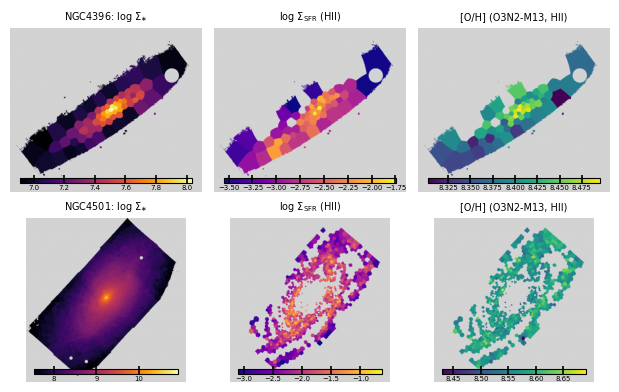

In [5]:
# --------------------------------------------------------------
# Maps: Σ_M*, Σ_SFR and [O/H] (O3N2-M13) maps for each galaxy
# Using HII spaxels (common HII for Σ_SFR and O/H only)
# Layout: up to 14 galaxies in 7 rows × 6 columns
# Columns per row: [Σ_M*, Σ_SFR, [O/H]] × 2 blocks
# --------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path
from astropy.io import fits

# 0 · discover galaxies
gas_bins = sorted(Path('.').glob('*_gas_bin_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in gas_bins]          # 14 expected
ngal     = len(galaxies)
assert ngal <= 14, "This layout assumes ≤ 14 galaxies."

# 1 · helpers to load maps (no mask for mass; HII mask for Σ_SFR and O/H)
def load_maps_hii(gal):
    """
    Load stellar-mass surface density (from spatial-binning file),
    Σ_SFR (HII), and [O/H] (O3N2-M13, HII) for a galaxy.

    - Σ_M* is shown wherever it is finite (no HII mask).
    - Σ_SFR and [O/H] use a common HII mask requiring both to be finite.
    """
    with fits.open(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits') as h_bin:
        logSigmaM = h_bin['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits') as h_gas:
        sigSFR_HII     = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2m13_HII = h_gas['O_H_O3N2_M13_HII'].data

    # Mass: just require Σ_M* to be finite
    mass_mask   = np.isfinite(logSigmaM)
    logSigmaM_c = np.where(mass_mask, logSigmaM, np.nan)

    # HII common mask for Σ_SFR and O/H
    hii_mask        = (np.isfinite(sigSFR_HII) & np.isfinite(oh_o3n2m13_HII))
    sigSFR_HII_c    = np.where(hii_mask, sigSFR_HII, np.nan)
    oh_o3n2m13_c    = np.where(hii_mask, oh_o3n2m13_HII, np.nan)

    return logSigmaM_c, sigSFR_HII_c, oh_o3n2m13_c

# 2 · figure & GridSpec  (rows=7, cols=6 → two 3-column blocks per row)
# Use constrained_layout for better handling of colorbars and spacing
fig = plt.figure(figsize=(12, 12), constrained_layout=True)
gs  = GridSpec(
        nrows=7, ncols=6, figure=fig,
        width_ratios=[1, 1, 1, 1, 1, 1],      # [Σ_M*, Σ_SFR, [O/H]] × 2 blocks
        wspace=0.00, hspace=0.00
)

for idx, gal in enumerate(galaxies):
    row  = idx % 7                      # 0–6
    blk  = idx // 7                     # 0 or 1   (left / right 3-column block)
    col0 = blk * 3                      # 0 or 3   (start col of that block)

    logSigmaM_c, sigSFR_HII_c, oh_o3n2m13_c = load_maps_hii(gal)

    # Σ_M* map with NaN shown as light gray
    axM = fig.add_subplot(gs[row, col0])
    cmap_M = plt.cm.inferno.copy(); cmap_M.set_bad('lightgray')
    imM = axM.imshow(logSigmaM_c, origin='lower', cmap=cmap_M)
    axM.set_title(rf'{gal}: $\log\,\Sigma_{{\ast}}$', fontsize=7)
    axM.axis('off')
    caxM = inset_axes(axM, width='90%', height='3%', loc='lower center', borderpad=0.6)
    fig.colorbar(imM, cax=caxM, orientation='horizontal')
    caxM.tick_params(labelsize=5, pad=1)

    # Σ_SFR (HII) map with NaN shown as light gray
    axS = fig.add_subplot(gs[row, col0+1])
    cmap_S = plt.cm.plasma.copy(); cmap_S.set_bad('lightgray')
    imS = axS.imshow(sigSFR_HII_c, origin='lower', cmap=cmap_S)
    axS.set_title(r'$\log\,\Sigma_{\mathrm{SFR}}$ (HII)', fontsize=7)
    axS.axis('off')
    caxS = inset_axes(axS, width='90%', height='3%', loc='lower center', borderpad=0.6)
    fig.colorbar(imS, cax=caxS, orientation='horizontal')
    caxS.tick_params(labelsize=5, pad=1)

    # [O/H] O3N2-M13 (HII) map with NaN shown as light gray
    axOH = fig.add_subplot(gs[row, col0+2])
    cmap_OH = plt.cm.viridis.copy(); cmap_OH.set_bad('lightgray')
    imOH = axOH.imshow(oh_o3n2m13_c, origin='lower', cmap=cmap_OH)
    axOH.set_title(r'[O/H] (O3N2-M13, HII)', fontsize=7)
    axOH.axis('off')
    caxOH = inset_axes(axOH, width='90%', height='3%', loc='lower center', borderpad=0.6)
    fig.colorbar(imOH, cax=caxOH, orientation='horizontal')
    caxOH.tick_params(labelsize=5, pad=1)

# Save figure in both PNG and PDF formats
# Add a little extra space below plots via pad_inches
# fig.savefig('Plot_Paper_1_referee/MAUVE_MUSE_SigmaM_SigmaSFR_OH_Maps_HII_6x7.png', dpi=600, bbox_inches='tight', pad_inches=0.05)
# fig.savefig('Plot_Paper_1_referee/MAUVE_MUSE_SigmaM_SigmaSFR_OH_Maps_HII_6x7.pdf', dpi=600, pad_inches=0.05)

plt.show()

In [6]:
# # ------------------------------------------------------------------
# # Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# # Using O3N2-M13 indicator only
# # 2x2 subplot layout:
# #   Top-left: rMZR scatter
# #   Top-right: Z_gas-Σ_SFR scatter
# #   Bottom-left: rMZR median trends
# #   Bottom-right: Z_gas-Σ_SFR median trends
# # ------------------------------------------------------------------
# import numpy as np
# import matplotlib.pyplot as plt
# from pathlib import Path
# from astropy.io import fits
# import scipy.stats as stats

# def load_maps_o3n2_m13(gal):
#     """Load O3N2-M13 metallicity calibration for HII regions"""
#     with fits.open(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits') as h:
#         sigM = h['LOGMASS_SURFACE_DENSITY'].data
#     with fits.open(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits') as h:
#         # HII regions
#         sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
#         oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
#     return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

# def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
#     """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
#     # Define bins
#     x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
#     bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
#     medians = []
#     stds = []
#     counts = []
#     valid_centers = []
#     valid_bin_indices = []
    
#     for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
#         # Select data in this bin
#         in_bin = (x_data >= bin_start) & (x_data < bin_end)
#         y_in_bin = y_data[in_bin]
        
#         if len(np.unique(y_in_bin)) >= min_pixels:
#             medians.append(np.median(y_in_bin))
#             stds.append(np.std(y_in_bin))
#             counts.append(len(y_in_bin))
#             valid_centers.append(bin_centers[i])
#             valid_bin_indices.append(i)
    
#     return (np.array(valid_centers), np.array(medians), np.array(stds), 
#             np.array(counts), np.array(valid_bin_indices))

# # Get all galaxies
# bins = sorted(Path('.').glob('*_v3tk_SNR200_spatial_binning_maps_extended.fits'))
# galaxies = [f.name.split('_')[0] for f in bins]

# # Galaxies to exclude entirely
# excluded_galaxies = {'NGC4383'}
# included_galaxies = []

# # ==============================================================================
# # STEP 1: Collect all spaxels from all galaxies for HII regions
# # ==============================================================================
# all_logSigmaM_HII = []
# all_logSigmaSFR_HII = []
# all_oh_o3n2_m13_HII = []

# print("="*80)
# print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
# print("="*80)

# for gal in galaxies:
#     if gal in excluded_galaxies:
#         print(f"  {gal}: excluded from analysis")
#         continue

#     bin_file = Path(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits')
#     gas_file = Path(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits')

#     if bin_file.exists() and gas_file.exists():
#         included_galaxies.append(gal)
#         # Load data for HII regions
#         (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

#         # Find common spaxels for HII regions
#         common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
#                            np.isfinite(oh_o3n2_m13_HII))
        
#         print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
#         # Append HII data
#         all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
#         all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
#         all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
#     else:
#         print(f"  {gal}: Data files not found")

# # Convert to numpy arrays
# all_logSigmaM_HII = np.array(all_logSigmaM_HII)
# all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
# all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

# print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# # ==============================================================================
# # STEP 2: Define 8 Σ_SFR bins for rMZR analysis
# # Bins: <-3.5, [-3.5,-3.0), [-3.0,-2.5), [-2.5,-2.0), [-2.0,-1.5), [-1.5,-1.0), [-1.0,-0.5), >=-0.5
# # ==============================================================================
# print("\n" + "="*80)
# print("STEP 2: Defining 8 SFR bins for rMZR")
# print("="*80)

# # Define 8 bins with specific boundaries
# n_bins = 8
# # Bin edges: -inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf
# sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]

# print(f"\nΣ_SFR bins:")
# print(f"  Number of bins: {n_bins}")

# # Create bin labels
# bin_labels = [
#     '<-3.5',
#     '-3.5–-3.0',
#     '-3.0–-2.5',
#     '-2.5–-2.0',
#     '-2.0–-1.5',
#     '-1.5–-1.0',
#     '-1.0–-0.5',
#     '>-0.5'
# ]

# print(f"\n8 SFR bins:")
# for i, label in enumerate(bin_labels):
#     print(f"  Bin {i+1}: {label}")

# # Colors for different bins using rainbow colormap
# colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# # ==============================================================================
# # STEP 3: Define 8 Σ_* bins for Z_gas-Σ_SFR analysis
# # Bins: <6.5, [6.5,7.0), [7.0,7.5), [7.5,8.0), [8.0,8.5), [8.5,9.0), [9.0,9.5), >=9.5
# # ==============================================================================
# print("\n" + "="*80)
# print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
# print("="*80)

# # Define 8 Σ_* bins with specific boundaries
# n_bins_sigmaM = 8
# # Bin edges: -inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, +inf
# sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]

# print(f"\nΣ_* bins:")
# print(f"  Number of bins: {n_bins_sigmaM}")

# # Create bin labels for Σ_* bins
# bin_labels_sigmaM = [
#     '<6.5',
#     '6.5–7.0',
#     '7.0–7.5',
#     '7.5–8.0',
#     '8.0–8.5',
#     '8.5–9.0',
#     '9.0–9.5',
#     '>9.5'
# ]

# print(f"\n8 Σ_* bins:")
# for i, label in enumerate(bin_labels_sigmaM):
#     print(f"  Bin {i+1}: {label}")

# # Colors for 8 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
# colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# # ==============================================================================
# # STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# # ==============================================================================
# print("\n" + "="*80)
# print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
# print("="*80)

# # Set uniform y-axis range
# common_ylim = (8.2, 8.9)

# print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# # Create figure with 2 rows x 2 columns, sharing axes
# # sharex='col': Top-Left shares with Bottom-Left, Top-Right shares with Bottom-Right
# # sharey='all': All panels share Y axis (since all are [O/H])
# fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
# plt.subplots_adjust(wspace=0.05, hspace=0.05)

# # Use O3N2-M13 data
# oh_data_HII = all_oh_o3n2_m13_HII
# calib_name_HII = 'O3N2-M13'

# print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
# print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# # Assign axes (swap top-right with bottom-left)
# ax_rMZR_scatter = axes[0, 0]
# ax_Zgas_scatter = axes[0, 1]
# ax_rMZR_median = axes[1, 0]
# ax_Zgas_median = axes[1, 1]

# # =============================================================================
# # TOP ROW LEFT: rMZR scatter (in 8 Σ_SFR bins)
# # =============================================================================
# print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")

# legend_handles_sfr = []
# legend_labels_sfr = []

# valid_bins_rMZR = 0
# for i in range(n_bins):
#     # HII regions processing - handle all bins uniformly
#     in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
#     n_pixels_HII = np.sum(in_bin_HII)
    
#     if n_pixels_HII >= 10:
#         # Get data for this bin (x=Σ_*, y=[O/H])
#         x_bin_HII = all_logSigmaM_HII[in_bin_HII]
#         y_bin_HII = oh_data_HII[in_bin_HII]
        
#         # Scatter plot
#         scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sfr[i]], s=15, alpha=0.6, 
#                              edgecolors='none', rasterized=True)
        
#         legend_handles_sfr.append(scatter_hii)
#         legend_labels_sfr.append(bin_labels[i])
        
#         # Median trends
#         mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
#             x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
#         if len(mass_centers_HII) > 0:
#             ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
#                        color=colors_sfr[i], marker='o', markersize=6, 
#                        linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
#             # Add lines between adjacent bins
#             for j in range(len(valid_bin_indices_HII) - 1):
#                 current_bin_idx = valid_bin_indices_HII[j]
#                 next_bin_idx = valid_bin_indices_HII[j + 1]
#                 if next_bin_idx - current_bin_idx == 1:
#                     ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
#                            [medians_HII[j], medians_HII[j + 1]], 
#                            color=colors_sfr[i], linewidth=2, alpha=0.8)
#             valid_bins_rMZR += 1

# # Format rMZR scatter plot
# # No title
# # No xlabel (shared with bottom)
# ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
# ax_rMZR_scatter.grid(True, alpha=0.3)
# ax_rMZR_scatter.set_xlim(6, 10)
# ax_rMZR_scatter.set_ylim(common_ylim)

# # =============================================================================
# # BOTTOM ROW LEFT: rMZR median trends
# # =============================================================================
# # No title
# ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
# ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
# ax_rMZR_median.grid(True, alpha=0.3)
# ax_rMZR_median.set_xlim(6, 10)
# ax_rMZR_median.set_ylim(common_ylim)

# # Add legend to bottom panel
# ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
#                      ncol=4, fontsize=12, framealpha=0.9,
#                      title='rMZR: log(ΣSFR) bins', title_fontsize=12)

# print(f"  rMZR valid bins: {valid_bins_rMZR}")

# # =============================================================================
# # TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 8 Σ_* bins)
# # =============================================================================
# print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")

# legend_handles_sigmaM = []
# legend_labels_sigmaM_display = []

# valid_bins_Zgas = 0
# for i in range(n_bins_sigmaM):
#     # HII regions processing - handle all bins uniformly
#     in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
#     n_pixels_HII = np.sum(in_bin_HII)
    
#     if n_pixels_HII >= 10:
#         # Get data for this bin (x=Σ_SFR, y=[O/H])
#         x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
#         y_bin_HII = oh_data_HII[in_bin_HII]
        
#         # Scatter plot
#         scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
#                              edgecolors='none', rasterized=True)
        
#         legend_handles_sigmaM.append(scatter_hii)
#         legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
#         # Median trends (now bin by Σ_SFR)
#         sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
#             x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
#         if len(sfr_centers_HII) > 0:
#             ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
#                        color=colors_sigmaM[i], marker='o', markersize=6, 
#                        linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
#             # Add lines between adjacent bins
#             for j in range(len(valid_bin_indices_HII) - 1):
#                 current_bin_idx = valid_bin_indices_HII[j]
#                 next_bin_idx = valid_bin_indices_HII[j + 1]
#                 if next_bin_idx - current_bin_idx == 1:
#                     ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
#                            [medians_HII[j], medians_HII[j + 1]], 
#                            color=colors_sigmaM[i], linewidth=2, alpha=0.8)
#             valid_bins_Zgas += 1

# # Format Z_gas-Σ_SFR scatter plot
# # No title
# # No xlabel (shared with bottom)
# # No ylabel (shared with left)
# ax_Zgas_scatter.grid(True, alpha=0.3)
# ax_Zgas_scatter.set_xlim(-5.0, 0.5)
# ax_Zgas_scatter.set_ylim(common_ylim)

# # =============================================================================
# # BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# # =============================================================================
# # No title
# ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
# # No ylabel (shared with left)
# ax_Zgas_median.grid(True, alpha=0.3)
# ax_Zgas_median.set_xlim(-5.0, 0.5)
# ax_Zgas_median.set_ylim(common_ylim)

# # Add legend to bottom panel
# ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
#                      ncol=4, fontsize=12, framealpha=0.9,
#                      title='Z_gas-Σ_SFR: log(Σ*) bins', title_fontsize=12)

# print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1_referee/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1_referee/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
# plt.show()

# print("\n" + "="*80)
# print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
# print("="*80)
# print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
# print(f"Galaxies included: {', '.join(included_galaxies)}")
# print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
# print("\nPanel summary:")
# print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
# print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
# print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
# print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
# print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")


Offset relations and Spearman rho vs Σ_* (excluding: {'NGC4383'})
All galaxies (for color assignment): NGC4396, NGC4501
Galaxies used in this analysis: NGC4396, NGC4501

Processing NGC4396 ...
  Σ* range (95%): 6.908 to 7.826
  Global Δlog(Σ_SFR) axis limits: ±0.979
  Global Δ[O/H] axis limits: ±0.079
  Spearman rho in each Σ_* bin (no 3σ clip, no trend gate, per galaxy):
    Bin 01 (7.06): n=76823, r=-0.381 (p=0)
    Bin 02 (7.37): n=29604, r=-0.186 (p=4.38e-229)
    Bin 03 (7.67): n=11433, r=-0.004 (p=0.705)

Processing NGC4501 ...
  Σ* range (95%): 7.766 to 8.941
  Global Δlog(Σ_SFR) axis limits: ±1.182
  Global Δ[O/H] axis limits: ±0.141
  Spearman rho in each Σ_* bin (no 3σ clip, no trend gate, per galaxy):
    Bin 01 (7.86): n=43659, r=0.440 (p=0)
    Bin 02 (8.06): n=67069, r=0.568 (p=0)
    Bin 03 (8.26): n=59356, r=0.518 (p=0)
    Bin 04 (8.45): n=45566, r=0.679 (p=0)
    Bin 05 (8.65): n=40673, r=0.468 (p=0)
    Bin 06 (8.84): n=28623, r=0.395 (p=0)

Summary: number of Σ_* bi

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_93684/3332925806.py:373: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


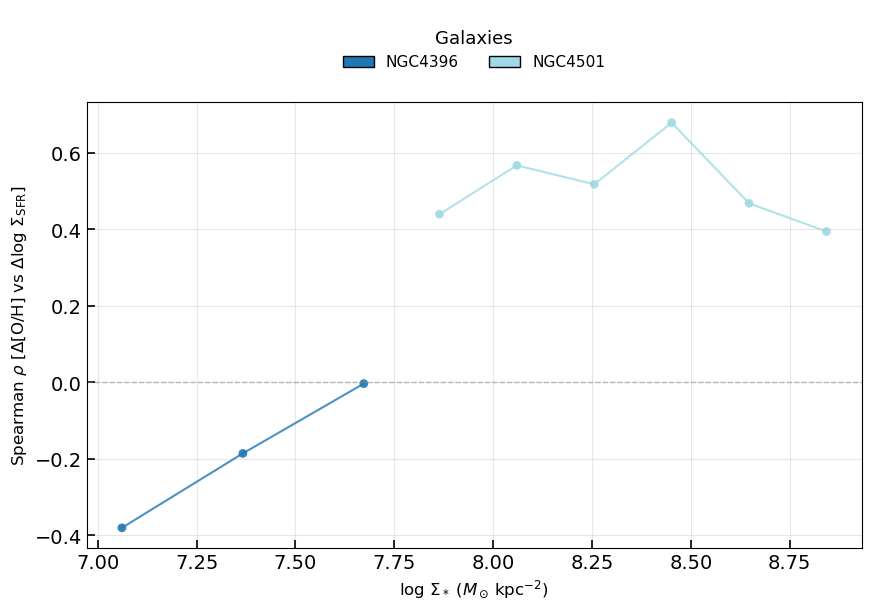

In [7]:
# ------------------------------------------------------------------
# Offset relations: Δ[O/H] vs Δlog Σ_SFR in Σ_* bins
# For all galaxies (excluding NGC4383) and Spearman rho vs Σ_* summary
# Spearman rho uses only points inside 95% contour and only if trend exists
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits'
    gas_path = f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Galaxy list and color map (reserve color for excluded galaxy)
# ------------------------------------------------------------------
all_bin_centers = []  # Σ_* bin centers for which rho is valid (per-galaxy)
all_rho_values = []     # Spearman rho (per-galaxy)
all_galaxy_indices = []

# Also store all spaxels across galaxies to compute a global trend
global_sigM_list = []
global_sigSFR_list = []
global_oh_list = []
global_gal_index_list = []

# Build full galaxy list from available FITS files (including excluded)
bins = sorted(Path('.').glob('*_v3tk_SNR200_spatial_binning_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}

# Build galaxy -> color mapping over ALL galaxies (so excluded keeps its color)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print(f"Offset relations and Spearman rho vs Σ_* (excluding: {excluded_galaxies})")
print("All galaxies (for color assignment):", ", ".join(galaxies_all))
print("Galaxies used in this analysis:", ", ".join(galaxies))
print("=" * 80)

# ------------------------------------------------------------------
# Loop over galaxies and compute Spearman rho per Σ_* bin (per-galaxy)
# and collect global spaxels for combined trend
# ------------------------------------------------------------------
for gal_index, gal in enumerate(galaxies):
    print(f"\nProcessing {gal} ...")
    try:
        sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"  Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        print("  No valid pixels.")
        continue

    # Collect into global arrays for combined analysis
    global_sigM_list.append(sigM[valid_all].ravel())
    global_sigSFR_list.append(sigSFR[valid_all].ravel())
    global_oh_list.append(oh_o3n2_map[valid_all].ravel())
    global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

    # 1. Define Σ_* bins for this galaxy (spanning 95% population)
    n_bins = 3 if gal == 'NGC4396' else 6
    sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
    sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

    # 2. Global symmetric limits for this galaxy (for reference / consistency)
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            if np.any(np.isfinite(sfr_offset)):
                global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            if np.any(np.isfinite(oh_offset)):
                global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    print(f"  Σ* range (95%): {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")

    # 3. Compute Spearman rho in each Σ_* bin using all valid points (per galaxy)
    print("  Spearman rho in each Σ_* bin (no 3σ clip, no trend gate, per galaxy):")
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        n_pixels = np.sum(bin_mask)

        if n_pixels <= 0:
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, r=N/A")
            continue

        # Values in this Σ_* bin
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_o3n2_map[bin_mask]

        # Offsets within this bin
        sfr_bin_mean = np.mean(sfr_bin)
        oh_bin_mean = np.mean(oh_bin)

        sfr_offset = sfr_bin - sfr_bin_mean
        oh_offset = oh_bin - oh_bin_mean

        valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

        if np.sum(valid_corr) <= 2:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (insufficient valid points)")
            continue

        # Spearman rho from all valid points in this Σ_* bin (no trend gate)
        x_corr = sfr_offset[valid_corr]
        y_corr = oh_offset[valid_corr]

        if np.unique(x_corr).size < 2 or np.unique(y_corr).size < 2:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (insufficient dynamic range)")
        else:
            try:
                spearman_rho, spearman_p = spearmanr(x_corr, y_corr)
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r={spearman_rho:.3f} (p={spearman_p:.3g})")
            except Exception:
                spearman_rho = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (error)")

        # Store only valid rho values
        if np.isfinite(spearman_rho):
            all_bin_centers.append(sigmaM_bin_centers[i])
            all_rho_values.append(spearman_rho)
            all_galaxy_indices.append(gal_index)

# ------------------------------------------------------------------
# Prepare global arrays for combined Spearman vs Σ_* (all galaxies)
# ------------------------------------------------------------------
if global_sigM_list:
    global_sigM = np.concatenate(global_sigM_list)
    global_sigSFR = np.concatenate(global_sigSFR_list)
    global_oh = np.concatenate(global_oh_list)
else:
    global_sigM = np.array([])
    global_sigSFR = np.array([])
    global_oh = np.array([])

# ------------------------------------------------------------------
# Convert collected per-galaxy Spearman rho data to arrays
# ------------------------------------------------------------------
all_bin_centers = np.array(all_bin_centers)
all_rho_values = np.array(all_rho_values)
all_galaxy_indices = np.array(all_galaxy_indices)

print("\n" + "=" * 80)
print("Summary: number of Σ_* bins with valid Spearman rho (per galaxy):", len(all_rho_values))
print("=" * 80)

# ------------------------------------------------------------------
# Compute combined Spearman rho vs Σ_* over all galaxies (same method)
# ------------------------------------------------------------------
global_bin_centers = []
global_rho_values = []

if global_sigM.size > 0:
    # Define 6 Σ_* bins for the combined sample (spanning 95% population)
    n_bins_global = 6
    sigmaM_min_g = np.nanpercentile(global_sigM, 2.5)
    sigmaM_max_g = np.nanpercentile(global_sigM, 97.5)
    sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
    sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

    print("\nComputing combined Spearman rho in Σ_* bins (all galaxies together)...")
    for i in range(n_bins_global):
        if i == 0:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
        elif i == n_bins_global - 1:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
        else:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

        n_pix_g = np.sum(bin_mask_g)
        if n_pix_g <= 0:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, r=N/A")
            continue

        sfr_bin_g = global_sigSFR[bin_mask_g]
        oh_bin_g = global_oh[bin_mask_g]

        sfr_mean_g = np.mean(sfr_bin_g)
        oh_mean_g = np.mean(oh_bin_g)

        sfr_off_g = sfr_bin_g - sfr_mean_g
        oh_off_g = oh_bin_g - oh_mean_g

        valid_corr_g = np.isfinite(sfr_off_g) & np.isfinite(oh_off_g)
        if np.sum(valid_corr_g) <= 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (insufficient valid points)")
            continue

        x_corr_g = sfr_off_g[valid_corr_g]
        y_corr_g = oh_off_g[valid_corr_g]

        if np.unique(x_corr_g).size < 2 or np.unique(y_corr_g).size < 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (insufficient dynamic range)")
            continue

        try:
            rho_g, p_g = spearmanr(x_corr_g, y_corr_g)
            global_bin_centers.append(sigmaM_centers_g[i])
            global_rho_values.append(rho_g)
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r={rho_g:.3f} (p={p_g:.3g})")
        except Exception:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (error)")

global_bin_centers = np.array(global_bin_centers)
global_rho_values = np.array(global_rho_values)

# ------------------------------------------------------------------
# Plot Spearman rho vs Σ_* for all galaxies, with galaxy color legend
# ------------------------------------------------------------------
if len(all_rho_values) > 0:
    
    galaxy_indices_unique = np.unique(all_galaxy_indices)
    
    # Create figure with main axis and a thin top axis for legend
    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis('off')
    
    plotted_galaxies = [] # Keep track of which galaxies are actually plotted
    
    # Plot Spearman rho vs Σ_* for each galaxy
    for idx in galaxy_indices_unique:
        mask = all_galaxy_indices == idx
        gal_name = galaxies[idx]
        color = galaxy_color_dict[gal_name]
        
        # Sort by Σ_* so lines are not scrambled
        x_vals = all_bin_centers[mask]
        y_vals = all_rho_values[mask]
        
        # Skip only empty series; keep single-point series as scatter
        if len(x_vals) == 0:
            continue
            
        plotted_galaxies.append(gal_name)
        
        order = np.argsort(x_vals)
        x_sorted = x_vals[order]
        y_sorted = y_vals[order]
        
        if len(x_sorted) > 1:
            ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(x_sorted, y_sorted, color=color, s=40, alpha=0.9, edgecolors='none', rasterized=True)
    
    
    # Axis formatting
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Spearman $\rho$ [Δ[O/H] vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
    # ax.set_title(r'Spearman $\rho$ vs $\log\,\Sigma_*$ (all galaxies, excluding NGC4383)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------
    # Galaxy legend at the top using dummy patches (excluding NGC4383)
    # ------------------------------------------------------------------
    legend_elements = [
        Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
        for gal in plotted_galaxies
    ]
    if len(plotted_galaxies) > 0:
        legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(plotted_galaxies), 6),
                        frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)
    
    plt.tight_layout()
    # plt.savefig('Plot_Paper_1_referee/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383.png',
    #             dpi=600, bbox_inches='tight')
    # plt.savefig('Plot_Paper_1_referee/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383.pdf',
    #             bbox_inches='tight')
    plt.show()
else:
    print("No valid Spearman rho values to plot.")

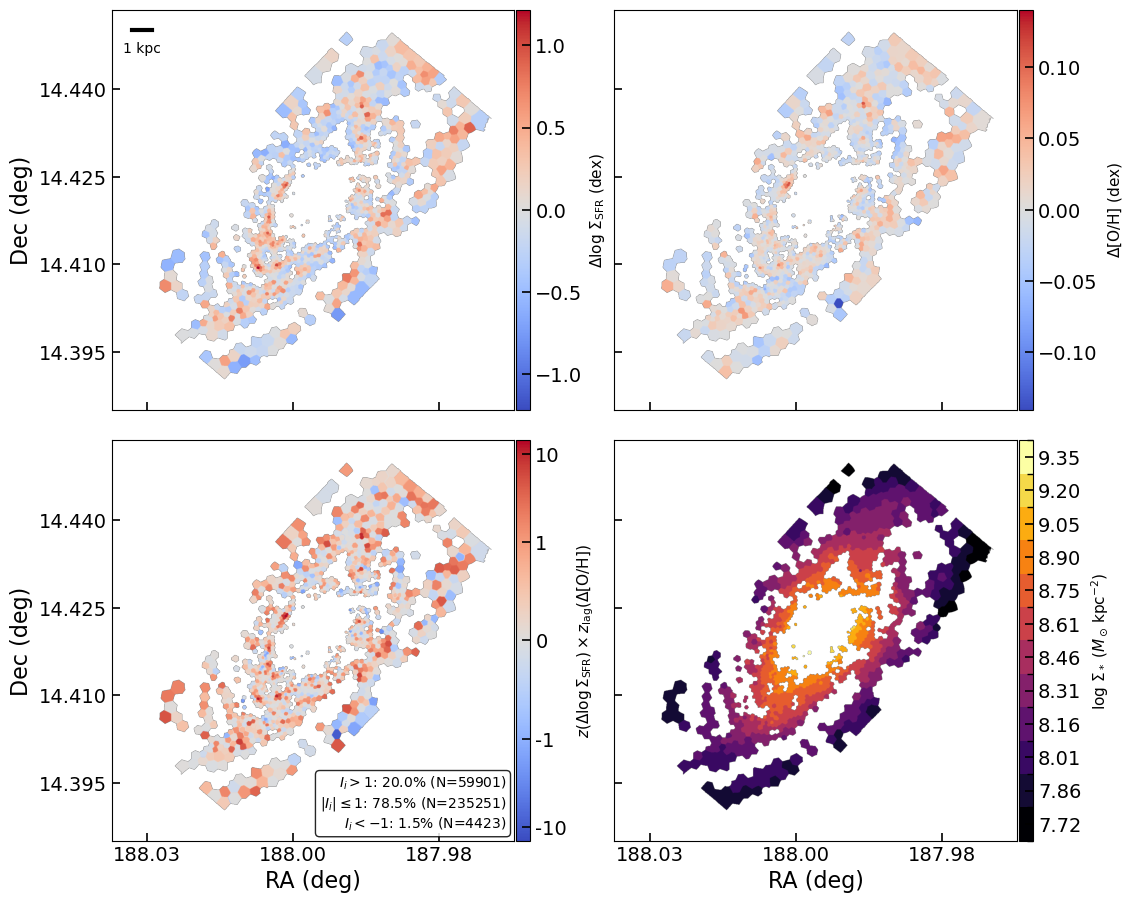

In [8]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter

# Only focus on NGC4501 for this visualisation
galaxies = ['NGC4501']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits'
    gas_path = f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran(A, B, valid_mask, neighbourhood='queen'):
        """
        Simple Moran-style local bivariate association between A and B.

        Parameters
        ----------
        A, B : 2D arrays
            Maps (e.g. sfr_offset, oh_offset).
        valid_mask : 2D bool
            True where both maps are valid.
        neighbourhood : {'queen', 'rook'}
            'queen' = 8-connected neighbours, 'rook' = 4-connected.

        Returns
        -------
        I_map : 2D array
            Local bivariate Moran-like statistic (sign & amplitude).
        quad_map : 2D int array
            Quadrant type:
            0 = invalid / no neighbours
            1 = high A, high lag(B)
            2 = low A,  high lag(B)
            3 = low A,  low lag(B)
            4 = high A, low lag(B)
        """
        ny, nx = A.shape
        I_map = np.full_like(A, np.nan, dtype=float)
        quad_map = np.zeros_like(A, dtype=int)

        # standardise A,B on valid pixels only
        Aval = A[valid_mask]
        Bval = B[valid_mask]
        Az = (A - np.nanmean(Aval)) / np.nanstd(Aval)
        Bz = (B - np.nanmean(Bval)) / np.nanstd(Bval)

        if neighbourhood == 'queen':
            offsets = [(-1,-1), (-1,0), (-1,1),
                       ( 0,-1),          ( 0,1),
                       ( 1,-1), ( 1,0), ( 1,1)]
        elif neighbourhood == 'rook':
            offsets = [(-1,0), (0,-1), (0,1), (1,0)]
        else:
            raise ValueError("neighbourhood must be 'queen' or 'rook'")

        for i in range(ny):
            for j in range(nx):
                if not valid_mask[i, j]:
                    continue

                # collect neighbouring Bz values
                neigh_vals = []
                for dy, dx in offsets:
                    ii, jj = i + dy, j + dx
                    if 0 <= ii < ny and 0 <= jj < nx and valid_mask[ii, jj]:
                        neigh_vals.append(Bz[ii, jj])

                if len(neigh_vals) == 0:
                    continue

                lag_B = np.mean(neigh_vals)   # spatial lag of B
                I_val = Az[i, j] * lag_B      # Moran-style product
                I_map[i, j] = I_val

                # quadrant classification (like LISA maps)
                if Az[i, j] >= 0 and lag_B >= 0:
                    quad_map[i, j] = 1  # high A – high B_neigh
                elif Az[i, j] < 0 and lag_B >= 0:
                    quad_map[i, j] = 2  # low A – high B_neigh
                elif Az[i, j] < 0 and lag_B < 0:
                    quad_map[i, j] = 3  # low A – low B_neigh
                else:
                    quad_map[i, j] = 4  # high A – low B_neigh

        return I_map, quad_map

    I_map, quad_map = local_bivariate_moran(sfr_offset, oh_offset, valid_all,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 5b.  Scale bar: 1 kpc for 0.2 arcsec/pixel at 16.5 Mpc
    # ------------------------------------------------------------------
    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    def add_scalebar(ax, length_deg, label='1 kpc'):
        x0, x1 = ax.get_xlim()
        x_range = abs(x1 - x0)
        if x_range == 0:
            return
        frac_len = length_deg / x_range
        x_start = 0.05
        y_start = 0.95
        x_end = x_start + frac_len
        line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                        color='k', lw=3, clip_on=False)
        line.set_in_layout(False)
        txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                      transform=ax.transAxes, ha='center', va='top', color='k')
        txt.set_in_layout(False)

    # ------------------------------------------------------------------
    # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
    # ------------------------------------------------------------------
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    # Auto-derive a reasonable figsize from the map extent
    dx = abs(extent[1] - extent[0])   # RA span
    dy = abs(extent[3] - extent[2])   # Dec span
    data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

    panel_h = 4.2   # inches per panel height (tune once)
    panel_w = panel_h * data_ratio
    cbar_w = 0.35   # inches per colorbar (tune once)

    W = 2 * panel_w + 2 * cbar_w + 1.2
    H = 2 * panel_h + 0.8

    fig, axs = plt.subplots(
        2, 2, figsize=(W, H), sharex=True, sharey=True
    )

    # Make space for the appended colorbars (right margin matters)
    fig.subplots_adjust(
        left=0.07, right=0.96, bottom=0.07, top=0.98,
        wspace=0.20, hspace=0.06
    )

    ax1, ax2 = axs[0, 0], axs[0, 1]
    ax3, ax4 = axs[1, 0], axs[1, 1]

    def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    # --- Ticks / formatting (readable RA, no +1.834e2)
    for ax in (ax1, ax2, ax3, ax4):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Hide inner tick labels
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax2.get_yticklabels(), visible=False)
    plt.setp(ax4.get_yticklabels(), visible=False)

    # Axis labels (outer only)
    ax3.set_xlabel("RA (deg)", fontsize=16)
    ax4.set_xlabel("RA (deg)", fontsize=16)
    ax1.set_ylabel("Dec (deg)", fontsize=16)
    ax3.set_ylabel("Dec (deg)", fontsize=16)

    # ---- Panel 1: SFR offset
    im_sfr = ax1.imshow(
        np.ma.masked_invalid(sfr_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max,
        aspect="equal"
    )
    add_scalebar(ax1, scalebar_length_deg, label="1 kpc")
    add_cbar(ax1, im_sfr, r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (dex)', labelpad=4)

    # ---- Panel 2: OH offset
    im_oh = ax2.imshow(
        np.ma.masked_invalid(oh_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max,
        aspect="equal"
    )
    add_cbar(ax2, im_oh, r'$\Delta$[O/H] (dex)')

    # ---- Panel 3: Moran-like
    vI = np.nanmax(np.abs(I_map))
    norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

    imI = ax3.imshow(
        np.ma.masked_invalid(I_map),
        origin="lower", cmap="coolwarm",
        extent=extent, norm=norm,
        aspect="equal"
    )
    cbarI = add_cbar(
        ax3, imI,
        r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$'
    )

    # Keep your symmetric-log ticks logic
    max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
    pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f"{t:g}" for t in ticks])

    legend_text = (
        rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
        '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
        '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
    )
    ax3.text(
        0.98, 0.02, legend_text, transform=ax3.transAxes,
        fontsize=10, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    # ---- Panel 4: binned Σ*
    cmap_discrete = plt.cm.inferno
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    im_sigM_binned = ax4.imshow(
        np.ma.masked_invalid(sigM_binned_map),
        origin="lower", cmap=cmap_discrete, norm=norm_discrete,
        extent=extent,
        aspect="equal"
    )
    cbar_binned = add_cbar(
        ax4, im_sigM_binned,
        r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$'
    )

    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f"{bc:.2f}" for bc in bin_centers])

    # fig.savefig(f'Plot_Paper_1_referee/{gal}_v3tk_SNR200_correlation_map_moran.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
    # fig.savefig(f'Plot_Paper_1_referee/{gal}_v3tk_SNR200_correlation_map_moran.pdf', bbox_inches="tight", pad_inches=0.02)
    plt.show()

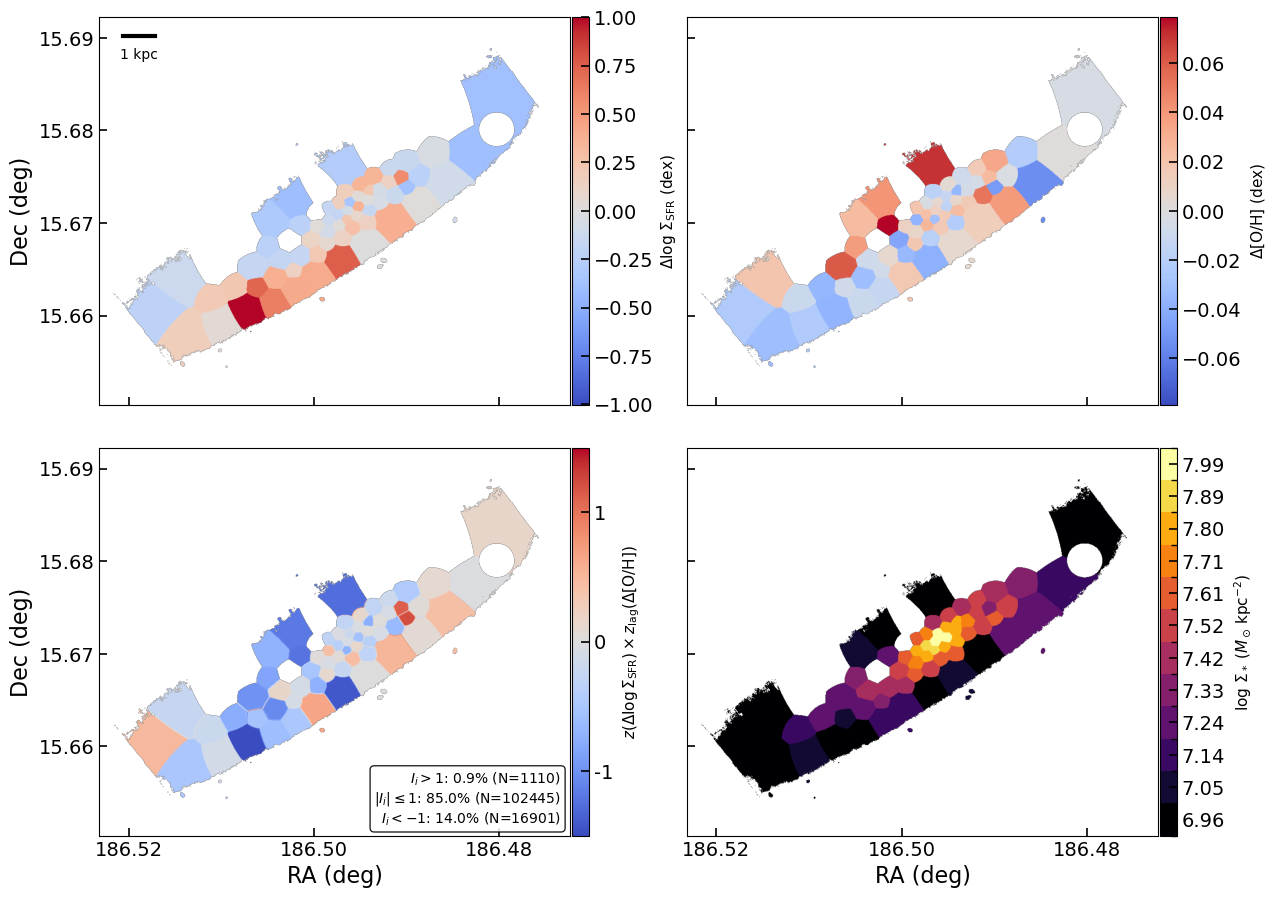

In [9]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter

# Only focus on NGC4396 for this visualisation
galaxies = ['NGC4396']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits'
    gas_path = f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran(A, B, valid_mask, neighbourhood='queen'):
        """
        Simple Moran-style local bivariate association between A and B.

        Parameters
        ----------
        A, B : 2D arrays
            Maps (e.g. sfr_offset, oh_offset).
        valid_mask : 2D bool
            True where both maps are valid.
        neighbourhood : {'queen', 'rook'}
            'queen' = 8-connected neighbours, 'rook' = 4-connected.

        Returns
        -------
        I_map : 2D array
            Local bivariate Moran-like statistic (sign & amplitude).
        quad_map : 2D int array
            Quadrant type:
            0 = invalid / no neighbours
            1 = high A, high lag(B)
            2 = low A,  high lag(B)
            3 = low A,  low lag(B)
            4 = high A, low lag(B)
        """
        ny, nx = A.shape
        I_map = np.full_like(A, np.nan, dtype=float)
        quad_map = np.zeros_like(A, dtype=int)

        # standardise A,B on valid pixels only
        Aval = A[valid_mask]
        Bval = B[valid_mask]
        Az = (A - np.nanmean(Aval)) / np.nanstd(Aval)
        Bz = (B - np.nanmean(Bval)) / np.nanstd(Bval)

        if neighbourhood == 'queen':
            offsets = [(-1,-1), (-1,0), (-1,1),
                       ( 0,-1),          ( 0,1),
                       ( 1,-1), ( 1,0), ( 1,1)]
        elif neighbourhood == 'rook':
            offsets = [(-1,0), (0,-1), (0,1), (1,0)]
        else:
            raise ValueError("neighbourhood must be 'queen' or 'rook'")

        for i in range(ny):
            for j in range(nx):
                if not valid_mask[i, j]:
                    continue

                # collect neighbouring Bz values
                neigh_vals = []
                for dy, dx in offsets:
                    ii, jj = i + dy, j + dx
                    if 0 <= ii < ny and 0 <= jj < nx and valid_mask[ii, jj]:
                        neigh_vals.append(Bz[ii, jj])

                if len(neigh_vals) == 0:
                    continue

                lag_B = np.mean(neigh_vals)   # spatial lag of B
                I_val = Az[i, j] * lag_B      # Moran-style product
                I_map[i, j] = I_val

                # quadrant classification (like LISA maps)
                if Az[i, j] >= 0 and lag_B >= 0:
                    quad_map[i, j] = 1  # high A – high B_neigh
                elif Az[i, j] < 0 and lag_B >= 0:
                    quad_map[i, j] = 2  # low A – high B_neigh
                elif Az[i, j] < 0 and lag_B < 0:
                    quad_map[i, j] = 3  # low A – low B_neigh
                else:
                    quad_map[i, j] = 4  # high A – low B_neigh

        return I_map, quad_map

    I_map, quad_map = local_bivariate_moran(sfr_offset, oh_offset, valid_all,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 5b.  Scale bar: 1 kpc for 0.2 arcsec/pixel at 16.5 Mpc
    # ------------------------------------------------------------------
    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    def add_scalebar(ax, length_deg, label='1 kpc'):
        x0, x1 = ax.get_xlim()
        x_range = abs(x1 - x0)
        if x_range == 0:
            return
        frac_len = length_deg / x_range
        x_start = 0.05
        y_start = 0.95
        x_end = x_start + frac_len
        line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                        color='k', lw=3, clip_on=False)
        line.set_in_layout(False)
        txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                      transform=ax.transAxes, ha='center', va='top', color='k')
        txt.set_in_layout(False)

    # ------------------------------------------------------------------
    # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
    # ------------------------------------------------------------------
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    # Auto-derive a reasonable figsize from the map extent
    dx = abs(extent[1] - extent[0])   # RA span
    dy = abs(extent[3] - extent[2])   # Dec span
    data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

    panel_h = 4.2   # inches per panel height (tune once)
    panel_w = panel_h * data_ratio
    cbar_w = 0.35   # inches per colorbar (tune once)

    W = 2 * panel_w + 2 * cbar_w + 1.2
    H = 2 * panel_h + 0.8

    fig, axs = plt.subplots(
        2, 2, figsize=(W, H), sharex=True, sharey=True
    )

    # Make space for the appended colorbars (right margin matters)
    fig.subplots_adjust(
        left=0.07, right=0.96, bottom=0.07, top=0.98,
        wspace=0.20, hspace=0.06
    )

    ax1, ax2 = axs[0, 0], axs[0, 1]
    ax3, ax4 = axs[1, 0], axs[1, 1]

    def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    # --- Ticks / formatting (readable RA, no +1.834e2)
    for ax in (ax1, ax2, ax3, ax4):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Hide inner tick labels
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax2.get_yticklabels(), visible=False)
    plt.setp(ax4.get_yticklabels(), visible=False)

    # Axis labels (outer only)
    ax3.set_xlabel("RA (deg)", fontsize=16)
    ax4.set_xlabel("RA (deg)", fontsize=16)
    ax1.set_ylabel("Dec (deg)", fontsize=16)
    ax3.set_ylabel("Dec (deg)", fontsize=16)

    # ---- Panel 1: SFR offset
    im_sfr = ax1.imshow(
        np.ma.masked_invalid(sfr_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max,
        aspect="equal"
    )
    add_scalebar(ax1, scalebar_length_deg, label="1 kpc")
    add_cbar(ax1, im_sfr, r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (dex)', labelpad=4)

    # ---- Panel 2: OH offset
    im_oh = ax2.imshow(
        np.ma.masked_invalid(oh_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max,
        aspect="equal"
    )
    add_cbar(ax2, im_oh, r'$\Delta$[O/H] (dex)')

    # ---- Panel 3: Moran-like
    vI = np.nanmax(np.abs(I_map))
    norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

    imI = ax3.imshow(
        np.ma.masked_invalid(I_map),
        origin="lower", cmap="coolwarm",
        extent=extent, norm=norm,
        aspect="equal"
    )
    cbarI = add_cbar(
        ax3, imI,
        r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$'
    )

    # Keep your symmetric-log ticks logic
    max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
    pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f"{t:g}" for t in ticks])

    legend_text = (
        rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
        '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
        '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
    )
    ax3.text(
        0.98, 0.02, legend_text, transform=ax3.transAxes,
        fontsize=10, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    # ---- Panel 4: binned Σ*
    cmap_discrete = plt.cm.inferno
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    im_sigM_binned = ax4.imshow(
        np.ma.masked_invalid(sigM_binned_map),
        origin="lower", cmap=cmap_discrete, norm=norm_discrete,
        extent=extent,
        aspect="equal"
    )
    cbar_binned = add_cbar(
        ax4, im_sigM_binned,
        r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$'
    )

    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f"{bc:.2f}" for bc in bin_centers])

    # fig.savefig(f'Plot_Paper_1_referee/{gal}_v3tk_SNR200_correlation_map_moran.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
    # fig.savefig(f'Plot_Paper_1_referee/{gal}_v3tk_SNR200_correlation_map_moran.pdf', bbox_inches="tight", pad_inches=0.02)
    plt.show()

Processing 2 galaxies (excluding NGC4383 for stats): NGC4396, NGC4501
Computing global Spearman trends...


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_93684/2083863858.py:593: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.85])


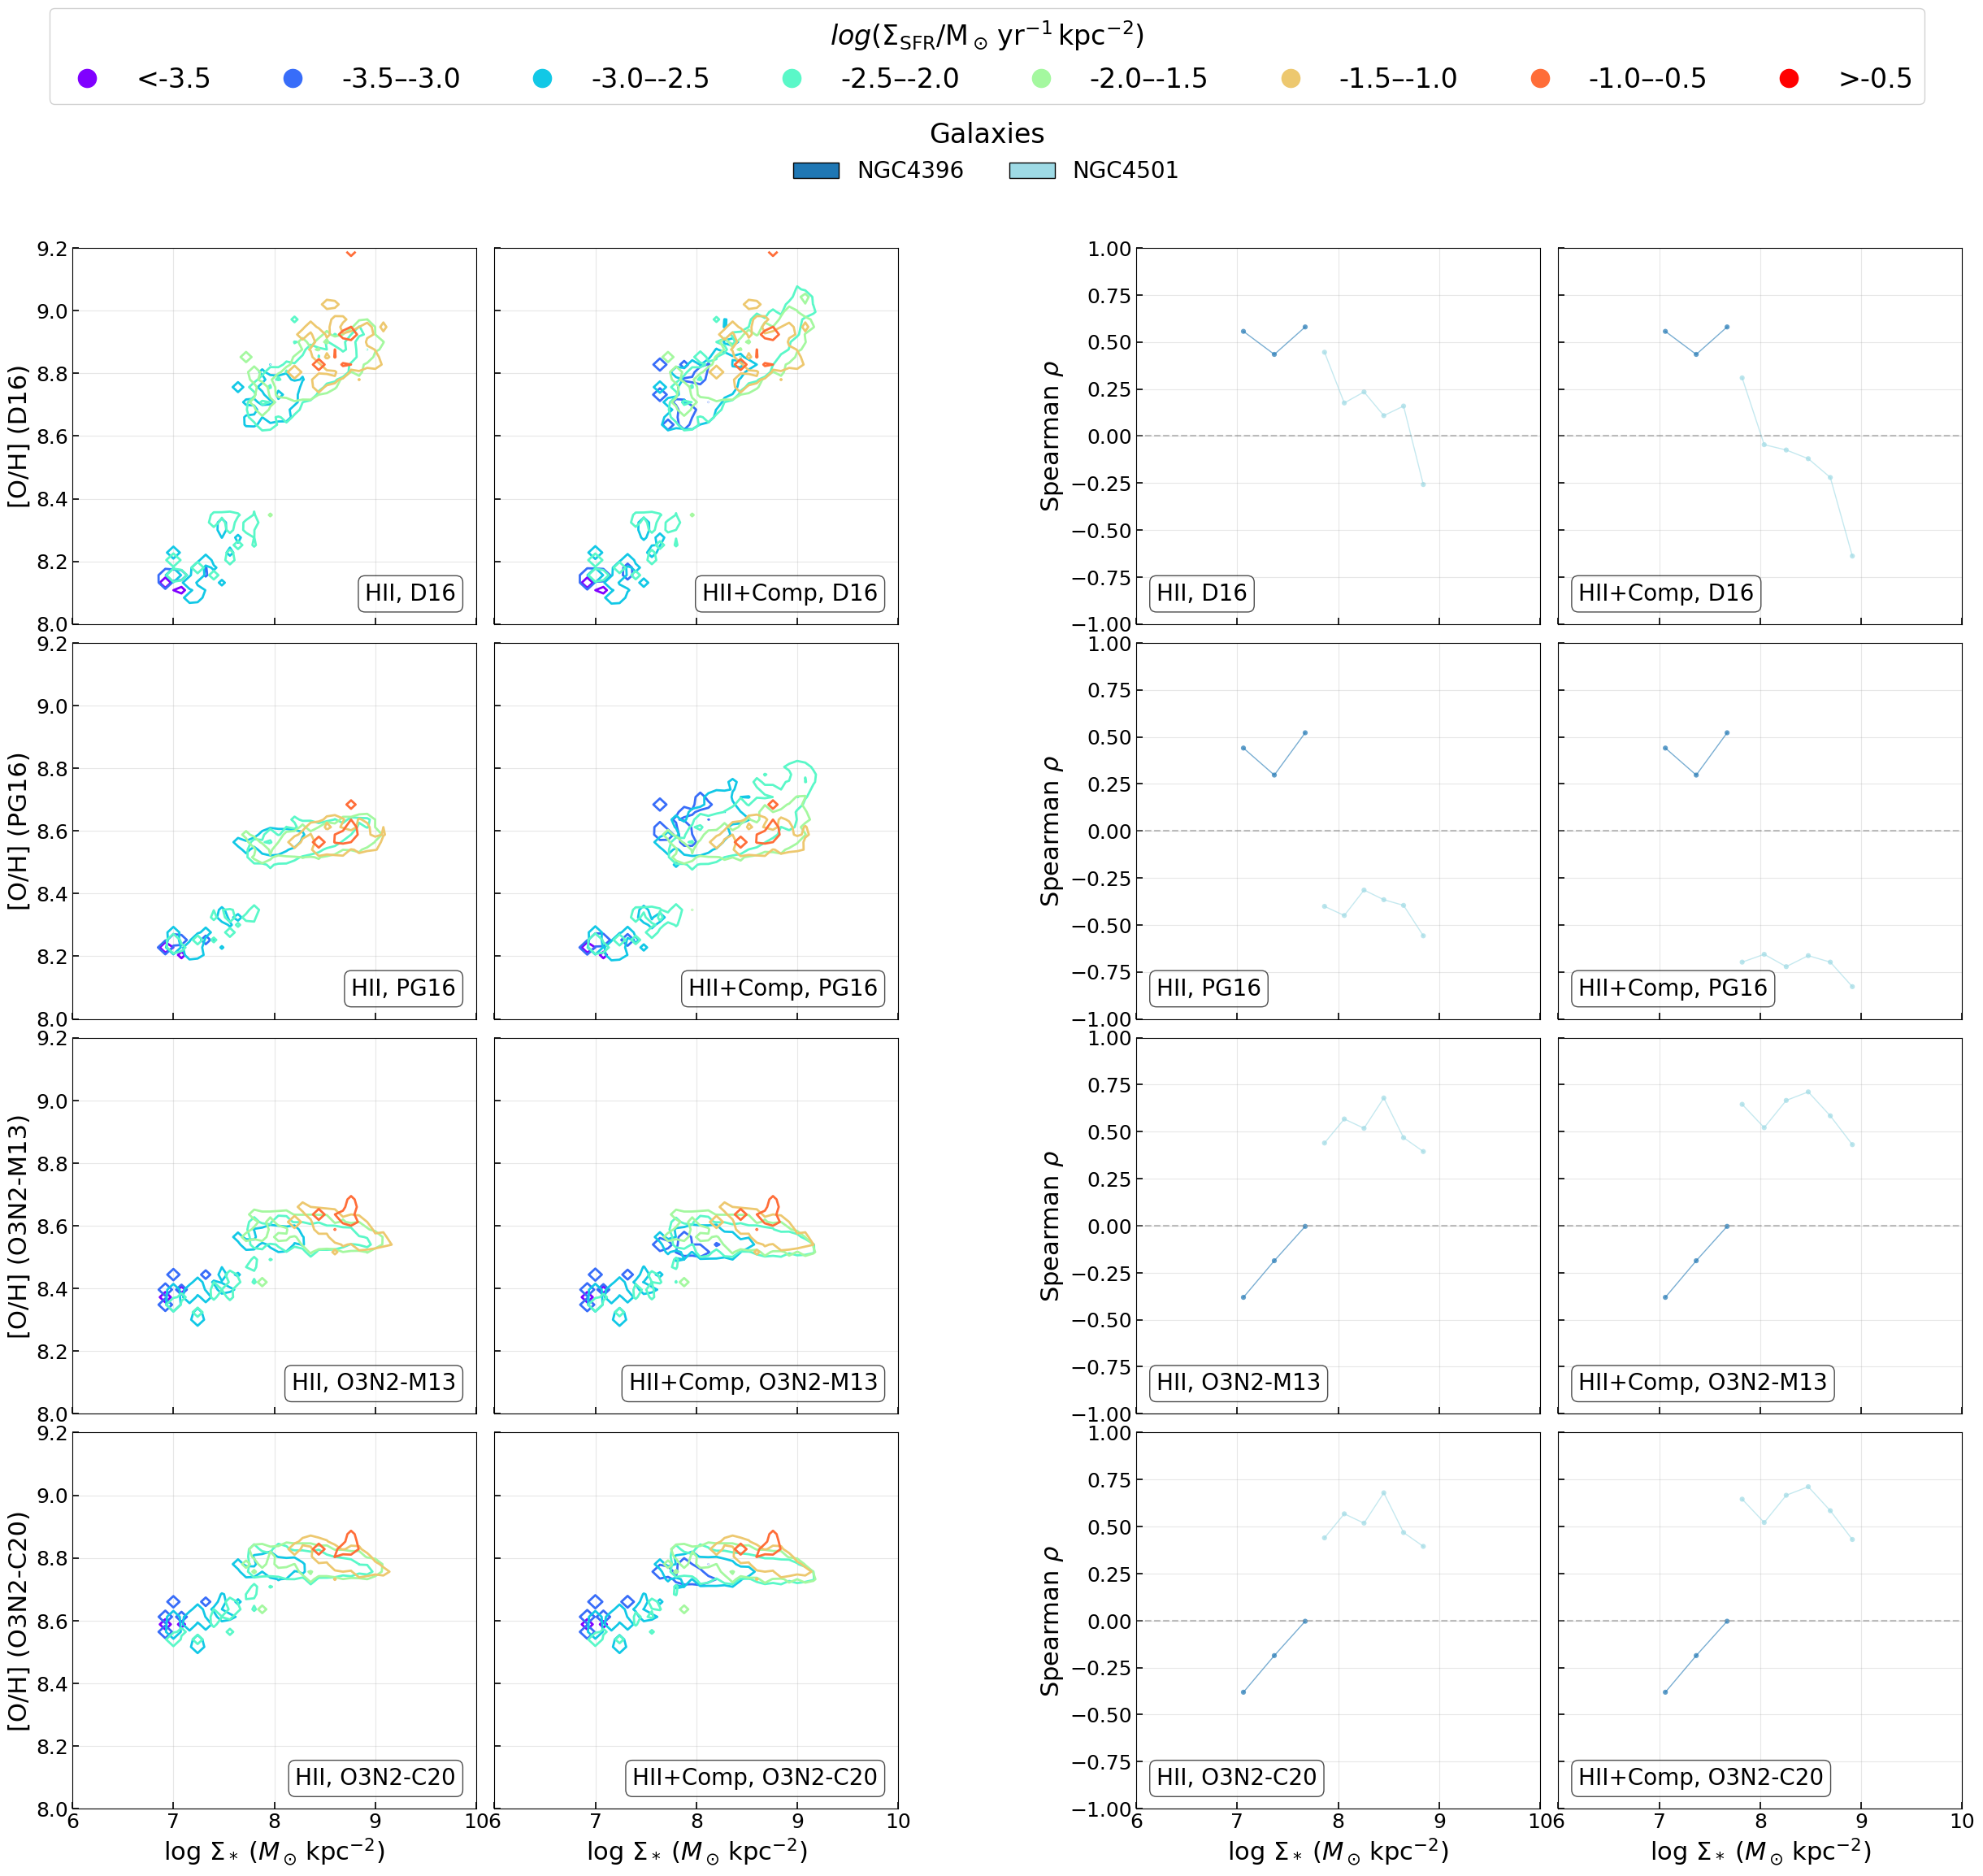

In [10]:
# ------------------------------------------------------------------
# COMBINED FIGURE: rMZR Scatter (Cols 1-2) and Spearman rho (Cols 3-4)
# WITH NGC4383 (Dotted Contours/Lines)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
from scipy.stats import spearmanr
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import matplotlib.lines as mlines

# ==========================================
# PART 1: FUNCTIONS & SETUP
# ==========================================

def load_maps_mzr(gal):
    """Load all metallicity calibrations for both HII and SF regions (MZR version)"""
    with fits.open(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
        # SF regions
        sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
        oh_d16_SF = h['O_H_D16_SF'].data
        oh_pg16_SF = h['O_H_PG16_SF'].data
        oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
        oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
        # Emission lines
        HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
        HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
        OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
        NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
        SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
        SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
            sigSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
            HB4861_FLUX_corr, HA6562_FLUX_corr, OIII5006_FLUX_corr, 
            NII6583_FLUX_corr, SII6716_FLUX_corr, SII6730_FLUX_corr)

def calculate_binned_stats_spearman(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins (Spearman version)"""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)
    
    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue
            
        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            
    return (np.array(valid_centers), np.array(medians), 
            np.array(stds), np.array(counts))

def compute_spearman_track(sigM, sigSFR, oh_map, n_bins=6):
    valid_all = np.isfinite(sigM) & np.isfinite(sigSFR) & np.isfinite(oh_map)
    if np.sum(valid_all) == 0:
        return np.array([]), np.array([])

    sigM = sigM[valid_all]
    sigSFR = sigSFR[valid_all]
    oh_map = oh_map[valid_all]

    sigmaM_min = np.nanpercentile(sigM, 2.5)
    sigmaM_max = np.nanpercentile(sigM, 97.5)
    sigmaM_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_centers = 0.5 * (sigmaM_edges[:-1] + sigmaM_edges[1:])
    
    valid_centers = []
    rho_values = []
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM < sigmaM_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM <= sigmaM_edges[i+1])
        else:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM < sigmaM_edges[i+1])
            
        if np.sum(bin_mask) <= 20: 
            continue
            
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_map[bin_mask]
        
        sfr_off = sfr_bin - np.mean(sfr_bin)
        oh_off = oh_bin - np.mean(oh_bin)
        
        valid_corr = np.isfinite(sfr_off) & np.isfinite(oh_off)
        
        if np.sum(valid_corr) <= 2:
            continue

        x_corr = sfr_off[valid_corr]
        y_corr = oh_off[valid_corr]

        if np.unique(x_corr).size < 2 or np.unique(y_corr).size < 2:
            continue

        try:
            rho, _ = spearmanr(x_corr, y_corr)
            if np.isfinite(rho):
                valid_centers.append(sigmaM_centers[i])
                rho_values.append(rho)
        except:
            pass
                
    return np.array(valid_centers), np.array(rho_values)

# ==========================================
# PART 2: DATA COLLECTION
# ==========================================

# Get galaxies
bins = sorted(Path('.').glob('*_v3tk_SNR200_spatial_binning_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]
print(f"Processing {len(galaxies)} galaxies (excluding NGC4383 for stats): {', '.join(galaxies)}")

# --- MZR Data Containers (Main) ---
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_d16_HII = []
all_oh_pg16_HII = []
all_oh_o3n2_m13_HII = []
all_oh_o3n2_c20_HII = []

all_logSigmaM_SF = []
all_logSigmaSFR_SF = []
all_oh_d16_SF = []
all_oh_pg16_SF = []
all_oh_o3n2_m13_SF = []
all_oh_o3n2_c20_SF = []

all_logSFR_hii = [] # For binning
all_logSFR_sf = []

# --- Spearman Data Containers (Main) ---
spearman_results = {
    'HII': {ind: {'galaxies': {}, 'global_pixels': {'sigM': [], 'sigSFR': [], 'oh': []}} for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']},
    'SF': {ind: {'galaxies': {}, 'global_pixels': {'sigM': [], 'sigSFR': [], 'oh': []}} for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']}
}

# --- NGC4383 Data Container ---
ngc4383_data = {
    'HII': {'sigM': [], 'sigSFR': [], 'D16': [], 'PG16': [], 'O3N2-M13': [], 'O3N2-C20': []},
    'SF': {'sigM': [], 'sigSFR': [], 'D16': [], 'PG16': [], 'O3N2-M13': [], 'O3N2-C20': []}
}
ngc4383_spearman = {
    'HII': {ind: ([], []) for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']},
    'SF': {ind: ([], []) for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']}
}

print("Collecting data...")
for gal in galaxies_all:
    # Load data using the MZR loader (it has everything)
    try:
        (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
         logSigmaSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
         HB, HA, OIII, NII, SII6716, SII6730) = load_maps_mzr(gal)
    except Exception as e:
        print(f"Skipping {gal}: {e}")
        continue

    # --- Process MZR Data ---
    common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                       np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                       np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII))
    
    common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
                      np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
                      np.isfinite(oh_o3n2_m13_SF) & np.isfinite(oh_o3n2_c20_SF))
    
    mass_bins = 3 if gal == 'NGC4396' else 6
    
    if gal == 'NGC4383':
        # Store NGC4383 data separately
        ngc4383_data['HII']['sigM'] = logSigmaM[common_mask_HII].flatten()
        ngc4383_data['HII']['sigSFR'] = logSigmaSFR_HII[common_mask_HII].flatten()
        ngc4383_data['HII']['D16'] = oh_d16_HII[common_mask_HII].flatten()
        ngc4383_data['HII']['PG16'] = oh_pg16_HII[common_mask_HII].flatten()
        ngc4383_data['HII']['O3N2-M13'] = oh_o3n2_m13_HII[common_mask_HII].flatten()
        ngc4383_data['HII']['O3N2-C20'] = oh_o3n2_c20_HII[common_mask_HII].flatten()
        
        ngc4383_data['SF']['sigM'] = logSigmaM[common_mask_SF].flatten()
        ngc4383_data['SF']['sigSFR'] = logSigmaSFR_SF[common_mask_SF].flatten()
        ngc4383_data['SF']['D16'] = oh_d16_SF[common_mask_SF].flatten()
        ngc4383_data['SF']['PG16'] = oh_pg16_SF[common_mask_SF].flatten()
        ngc4383_data['SF']['O3N2-M13'] = oh_o3n2_m13_SF[common_mask_SF].flatten()
        ngc4383_data['SF']['O3N2-C20'] = oh_o3n2_c20_SF[common_mask_SF].flatten()
        
        # Compute Spearman for NGC4383
        maps_4383 = {
            'HII': {
                'D16': (logSigmaM, logSigmaSFR_HII, oh_d16_HII),
                'PG16': (logSigmaM, logSigmaSFR_HII, oh_pg16_HII),
                'O3N2-M13': (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII),
                'O3N2-C20': (logSigmaM, logSigmaSFR_HII, oh_o3n2_c20_HII)
            },
            'SF': {
                'D16': (logSigmaM, logSigmaSFR_SF, oh_d16_SF),
                'PG16': (logSigmaM, logSigmaSFR_SF, oh_pg16_SF),
                'O3N2-M13': (logSigmaM, logSigmaSFR_SF, oh_o3n2_m13_SF),
                'O3N2-C20': (logSigmaM, logSigmaSFR_SF, oh_o3n2_c20_SF)
            }
        }
        for reg in ['HII', 'SF']:
            for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']:
                sM, sSFR, oh = maps_4383[reg][ind]
                x, y = compute_spearman_track(sM, sSFR, oh, n_bins=mass_bins)
                ngc4383_spearman[reg][ind] = (x, y)

    else:
        # Append Main MZR data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_d16_HII.extend(oh_d16_HII[common_mask_HII].flatten())
        all_oh_pg16_HII.extend(oh_pg16_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
        all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())
        all_logSFR_hii.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        
        all_logSigmaM_SF.extend(logSigmaM[common_mask_SF].flatten())
        all_logSigmaSFR_SF.extend(logSigmaSFR_SF[common_mask_SF].flatten())
        all_oh_d16_SF.extend(oh_d16_SF[common_mask_SF].flatten())
        all_oh_pg16_SF.extend(oh_pg16_SF[common_mask_SF].flatten())
        all_oh_o3n2_m13_SF.extend(oh_o3n2_m13_SF[common_mask_SF].flatten())
        all_oh_o3n2_c20_SF.extend(oh_o3n2_c20_SF[common_mask_SF].flatten())
        all_logSFR_sf.extend(logSigmaSFR_SF[common_mask_SF].flatten())

        # --- Process Spearman Data (Main) ---
        maps = {
            'HII': {
                'D16': (logSigmaM, logSigmaSFR_HII, oh_d16_HII),
                'PG16': (logSigmaM, logSigmaSFR_HII, oh_pg16_HII),
                'O3N2-M13': (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII),
                'O3N2-C20': (logSigmaM, logSigmaSFR_HII, oh_o3n2_c20_HII)
            },
            'SF': {
                'D16': (logSigmaM, logSigmaSFR_SF, oh_d16_SF),
                'PG16': (logSigmaM, logSigmaSFR_SF, oh_pg16_SF),
                'O3N2-M13': (logSigmaM, logSigmaSFR_SF, oh_o3n2_m13_SF),
                'O3N2-C20': (logSigmaM, logSigmaSFR_SF, oh_o3n2_c20_SF)
            }
        }
        
        for reg in ['HII', 'SF']:
            for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']:
                sM, sSFR, oh = maps[reg][ind]
                # Compute per-galaxy track
                x, y = compute_spearman_track(sM, sSFR, oh, n_bins=mass_bins)
                if len(x) > 0:
                    spearman_results[reg][ind]['galaxies'][gal] = (x, y)
                # Collect global pixels
                valid = np.isfinite(sM) & np.isfinite(sSFR) & np.isfinite(oh)
                if np.sum(valid) > 0:
                    spearman_results[reg][ind]['global_pixels']['sigM'].extend(sM[valid])
                    spearman_results[reg][ind]['global_pixels']['sigSFR'].extend(sSFR[valid])
                    spearman_results[reg][ind]['global_pixels']['oh'].extend(oh[valid])

# Convert MZR lists to arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_d16_HII = np.array(all_oh_d16_HII)
all_oh_pg16_HII = np.array(all_oh_pg16_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)
all_logSFR_hii = np.array(all_logSFR_hii)

all_logSigmaM_SF = np.array(all_logSigmaM_SF)
all_logSigmaSFR_SF = np.array(all_logSigmaSFR_SF)
all_oh_d16_SF = np.array(all_oh_d16_SF)
all_oh_pg16_SF = np.array(all_oh_pg16_SF)
all_oh_o3n2_m13_SF = np.array(all_oh_o3n2_m13_SF)
all_oh_o3n2_c20_SF = np.array(all_oh_o3n2_c20_SF)
all_logSFR_sf = np.array(all_logSFR_sf)

# Compute global Spearman tracks (Main only)
print("Computing global Spearman trends...")
for reg in ['HII', 'SF']:
    for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']:
        g_data = spearman_results[reg][ind]['global_pixels']
        if len(g_data['sigM']) > 0:
            x, y = compute_spearman_track(
                np.array(g_data['sigM']), 
                np.array(g_data['sigSFR']), 
                np.array(g_data['oh'])
            )
            spearman_results[reg][ind]['global_track'] = (x, y)
        else:
            spearman_results[reg][ind]['global_track'] = (np.array([]), np.array([]))

# ==========================================
# PART 3: PLOTTING
# ==========================================

# Setup MZR bins
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
n_bins = len(sfr_bin_edges) - 1
mzr_colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
bin_labels = ['<-3.5', '-3.5–-3.0', '-3.0–-2.5', '-2.5–-2.0', '-2.0–-1.5', '-1.5–-1.0', '-1.0–-0.5', '>-0.5']

# Setup Galaxy colors (using ALL galaxies to preserve color mapping)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Create Figure with more top space for legends
fig = plt.figure(figsize=(30, 24))
# 4 rows, 5 columns (use 5 cols with middle one as spacer). Large top margin for two legends stacked vertically.
# Columns: 0=HII, 1=SF, 2=SPACER, 3=Spearman HII, 4=Spearman SF
# Width ratios: normal, normal, wide spacer, normal, normal
# Use subplots for fine control over spacing
gs = gridspec.GridSpec(4, 5, figure=fig, hspace=0.05, top=0.85, bottom=0.05,
                       width_ratios=[1, 1, 0.5, 1, 1],  # Middle column is spacer
                       wspace=0.05)  # Base spacing (will be 0.2x of original 0.25)

calibrations = ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']
mzr_data_HII = [all_oh_d16_HII, all_oh_pg16_HII, all_oh_o3n2_m13_HII, all_oh_o3n2_c20_HII]
mzr_data_SF = [all_oh_d16_SF, all_oh_pg16_SF, all_oh_o3n2_m13_SF, all_oh_o3n2_c20_SF]

mzr_legend_handles = []
mzr_legend_labels = []

for row_idx, calib_name in enumerate(calibrations):
    # --- COL 0 & 1: MZR (Scatter) ---
    # Note: Using columns 0 and 1 for MZR, column 2 is spacer, columns 3 and 4 for Spearman
    ax_mzr_HII = fig.add_subplot(gs[row_idx, 0])
    ax_mzr_SF = fig.add_subplot(gs[row_idx, 1])
    
    oh_HII = mzr_data_HII[row_idx]
    oh_SF = mzr_data_SF[row_idx]
    
    # Plot MZR HII (Contours for 13 galaxies - solid lines)
    for i in range(n_bins):
        in_bin = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
        if np.sum(in_bin) > 20:  # Need enough points for density estimation
            try:
                x = all_logSigmaM_HII[in_bin]
                y = oh_HII[in_bin]
                
                # Use 2D histogram directly (much faster than KDE)
                xmin, xmax = 6, 10
                ymin, ymax = 8.0, 9.2
                H, xedges, yedges = np.histogram2d(x, y, bins=50, range=[[xmin, xmax], [ymin, ymax]], density=True)
                
                # Find 95% density threshold
                H_flat = H.flatten()
                H_sorted = np.sort(H_flat)[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum /= H_cumsum[-1]
                threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
                
                # Create grid centers for contour plotting
                x_centers = (xedges[:-1] + xedges[1:]) / 2
                y_centers = (yedges[:-1] + yedges[1:]) / 2
                
                # Plot solid contour at 95% threshold level for 13 galaxies
                ax_mzr_HII.contour(x_centers, y_centers, H.T, levels=[threshold_95], colors=[mzr_colors[i]], linestyles='solid', linewidths=2)
            except:
                pass
            
        if row_idx == 0 and len(mzr_legend_handles) < n_bins:
             mzr_legend_handles.append(mlines.Line2D([], [], color=mzr_colors[i], marker='o', linestyle='None', markersize=16, label=bin_labels[i]))
             mzr_legend_labels.append(bin_labels[i])
        
        # Plot NGC4383 Contours (HII) - 95% population (dotted)
        if len(ngc4383_data['HII']['sigM']) > 0:
            ngc_sigM = np.array(ngc4383_data['HII']['sigM'])
            ngc_oh = np.array(ngc4383_data['HII'][calib_name])
            ngc_sfr = np.array(ngc4383_data['HII']['sigSFR'])
            
            in_bin_ngc = (ngc_sfr >= sfr_bin_edges[i]) & (ngc_sfr < sfr_bin_edges[i+1])
            if np.sum(in_bin_ngc) > 20: # Need enough points for density estimation
                try:
                    x = ngc_sigM[in_bin_ngc]
                    y = ngc_oh[in_bin_ngc]
                    
                    # Use 2D histogram directly (much faster than KDE)
                    xmin, xmax = 6, 10
                    ymin, ymax = 8.0, 9.2
                    H, xedges, yedges = np.histogram2d(x, y, bins=50, range=[[xmin, xmax], [ymin, ymax]], density=True)
                    
                    # Find 95% density threshold
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
                    
                    # Create grid centers for contour plotting
                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2
                    
                    # Plot dotted contour at 95% threshold level
                    ax_mzr_HII.contour(x_centers, y_centers, H.T, levels=[threshold_95], colors=[mzr_colors[i]], linestyles='dotted', linewidths=2)
                except:
                    pass

    # Plot MZR SF (Contours for 13 galaxies - solid lines)
    for i in range(n_bins):
        in_bin = (all_logSigmaSFR_SF >= sfr_bin_edges[i]) & (all_logSigmaSFR_SF < sfr_bin_edges[i+1])
        if np.sum(in_bin) > 20:  # Need enough points for density estimation
            try:
                x = all_logSigmaM_SF[in_bin]
                y = oh_SF[in_bin]
                
                # Create 2D histogram to find 95% density threshold
                # Use 2D histogram directly (much faster than KDE)
                xmin, xmax = 6, 10
                ymin, ymax = 8.0, 9.2
                H, xedges, yedges = np.histogram2d(x, y, bins=50, range=[[xmin, xmax], [ymin, ymax]], density=True)
                
                # Find 95% density threshold
                H_flat = H.flatten()
                H_sorted = np.sort(H_flat)[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum /= H_cumsum[-1]
                threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
                
                # Create grid centers for contour plotting
                x_centers = (xedges[:-1] + xedges[1:]) / 2
                y_centers = (yedges[:-1] + yedges[1:]) / 2
                
                # Plot solid contour at 95% threshold level for 13 galaxies
                ax_mzr_SF.contour(x_centers, y_centers, H.T, levels=[threshold_95], colors=[mzr_colors[i]], linestyles='solid', linewidths=2)
            except:
                pass
        
        # Plot NGC4383 Contours (SF) - 95% population (dotted)
        if len(ngc4383_data['SF']['sigM']) > 0:
            ngc_sigM = np.array(ngc4383_data['SF']['sigM'])
            ngc_oh = np.array(ngc4383_data['SF'][calib_name])
            ngc_sfr = np.array(ngc4383_data['SF']['sigSFR'])
            
            in_bin_ngc = (ngc_sfr >= sfr_bin_edges[i]) & (ngc_sfr < sfr_bin_edges[i+1])
            if np.sum(in_bin_ngc) > 20:
                try:
                    x = ngc_sigM[in_bin_ngc]
                    y = ngc_oh[in_bin_ngc]
                    
                    # Create 2D histogram to find 95% density threshold
                    # Use 2D histogram directly (much faster than KDE)
                    xmin, xmax = 6, 10
                    ymin, ymax = 8.0, 9.2
                    H, xedges, yedges = np.histogram2d(x, y, bins=50, range=[[xmin, xmax], [ymin, ymax]], density=True)
                    
                    # Find 95% density threshold
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
                    
                    # Create grid centers for contour plotting
                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2
                    
                    # Plot dotted contour at 95% threshold level
                    ax_mzr_SF.contour(x_centers, y_centers, H.T, levels=[threshold_95], colors=[mzr_colors[i]], linestyles='dotted', linewidths=2)
                except:
                    pass

    # Format MZR Axes
    for col_idx, (ax, region_label) in enumerate(zip([ax_mzr_HII, ax_mzr_SF], ['HII', 'HII+Comp'])):
        # X-axis label only on bottom row
        if row_idx == 3:  # Bottom row
            ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=22)
        else:
            ax.set_xlabel('')
            ax.tick_params(labelbottom=False)
        
        # Y-axis label only on left column of first two columns
        if col_idx == 0:  # Left column
            ax.set_ylabel(f'[O/H] ({calib_name})', fontsize=22)
        else:
            ax.set_ylabel('')
            ax.tick_params(labelleft=False)
        
        # Set tick label size
        ax.tick_params(labelsize=18)
        
        ax.set_xlim(6, 10)
        ax.set_ylim(8.0, 9.2) # Fixed range for consistency
        ax.grid(True, alpha=0.3)
        
        # Add annotation in bottom right
        ax.text(0.95, 0.05, f'{region_label}, {calib_name}', 
                transform=ax.transAxes, fontsize=20, 
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # --- COL 3 & 4: Spearman ---
    # Note: Column 2 is the spacer, so Spearman plots go in columns 3 and 4
    ax_sp_HII = fig.add_subplot(gs[row_idx, 3])
    ax_sp_SF = fig.add_subplot(gs[row_idx, 4])
    
    for col_idx, (ax, region_key, region_label) in enumerate(zip([ax_sp_HII, ax_sp_SF], ['HII', 'SF'], ['HII', 'HII+Comp'])):
        # Plot individual galaxies (Main)
        for gal, (x, y) in spearman_results[region_key][calib_name]['galaxies'].items():
            if len(x) == 0:
                continue
            color = galaxy_color_dict[gal]
            idx = np.argsort(x)
            if len(x) > 1:
                ax.plot(x[idx], y[idx], color=color, alpha=0.6, linewidth=1)
            ax.scatter(x[idx], y[idx], color=color, s=20, alpha=0.7, edgecolors='none')
            
        # Plot NGC4383 (Dotted)
        gx_ngc, gy_ngc = ngc4383_spearman[region_key][calib_name]
        if len(gx_ngc) > 0:
            color = galaxy_color_dict['NGC4383']
            idx = np.argsort(gx_ngc)
            ax.plot(gx_ngc[idx], gy_ngc[idx], color=color, alpha=0.8, linewidth=2, linestyle=':')
            ax.scatter(gx_ngc[idx], gy_ngc[idx], color=color, s=20, alpha=0.8, edgecolors='none')

            
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_ylim(-1.0, 1.0)
        ax.set_xlim(6, 10)
        
        # X-axis label only on bottom row
        if row_idx == 3:  # Bottom row
            ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=22)
        else:
            ax.set_xlabel('')
            ax.tick_params(labelbottom=False)
        
        # Y-axis label only on left column of last two columns (col 2)
        if col_idx == 0:  # Left column of columns 2-3
            ax.set_ylabel(r'Spearman $\rho$', fontsize=22)
        else:
            ax.set_ylabel('')
            ax.tick_params(labelleft=False)
        
        # Set tick label size
        ax.tick_params(labelsize=18)
        
        ax.grid(True, alpha=0.3)
        
        # Add annotation in bottom left
        ax.text(0.05, 0.05, f'{region_label}, {calib_name}', 
            transform=ax.transAxes, fontsize=20, 
            verticalalignment='bottom', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# --- LEGENDS ---
# 1. MZR Legend (SFR bins) - Top position
fig.legend(mzr_legend_handles, mzr_legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),
          ncol=8, fontsize=24, framealpha=0.9, 
          title=r'$log(\Sigma_\mathrm{SFR}/\mathrm{M_\odot\,yr^{-1}\,kpc^{-2}})$', title_fontsize=24)

# 2. Spearman Legend (Galaxies) - Below the SFR legend
spearman_legend_elements = [Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal) for gal in galaxies_all]

fig.legend(handles=spearman_legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.925),
           ncol=8, frameon=False, fontsize=20, title='Galaxies', title_fontsize=24)

# plt.savefig('Plot_Paper_1_referee/Combined_rMZR_spearman.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1_referee/Combined_rMZR_spearman.pdf', dpi=600, bbox_inches='tight')
plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()


In [11]:
# # ------------------------------------------------------------------
# # Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# # Using O3N2-M13 indicator only
# # 2x2 subplot layout:
# #   Top-left: rMZR scatter
# #   Top-right: Z_gas-Σ_SFR scatter
# #   Bottom-left: rMZR median trends
# #   Bottom-right: Z_gas-Σ_SFR median trends
# # ------------------------------------------------------------------
# import numpy as np
# import matplotlib.pyplot as plt
# from pathlib import Path
# from astropy.io import fits
# import scipy.stats as stats
# import scipy.ndimage as ndimage
# from scipy.optimize import curve_fit

# def load_maps_o3n2_m13(gal):
#     """Load O3N2-M13 metallicity calibration for HII regions"""
#     with fits.open(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits') as h:
#         sigM = h['LOGMASS_SURFACE_DENSITY'].data
#     with fits.open(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits') as h:
#         # HII regions
#         sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
#         oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
#     return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

# def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
#     """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
#     # Define bins
#     x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
#     bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
#     medians = []
#     stds = []
#     counts = []
#     valid_centers = []
#     valid_bin_indices = []
    
#     for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
#         # Select data in this bin
#         in_bin = (x_data >= bin_start) & (x_data < bin_end)
#         y_in_bin = y_data[in_bin]
        
#         if len(np.unique(y_in_bin)) >= min_pixels:
#             medians.append(np.median(y_in_bin))
#             stds.append(np.std(y_in_bin))
#             counts.append(len(y_in_bin))
#             valid_centers.append(bin_centers[i])
#             valid_bin_indices.append(i)
    
#     return (np.array(valid_centers), np.array(medians), np.array(stds), 
#             np.array(counts), np.array(valid_bin_indices))

# # Define the function form for fitting
# def mzr_model(x, a, b, c):
#     return a + b * (x - c) * np.exp(-(x - c))

# def plot_literature_mzr_fits(ax, show_legend=True):
#     """Plot literature MZR fits on the given axis"""
    
#     # Yao+22
#     # Range: 6.8 to 8.8
#     x_yao = np.linspace(6.8, 8.8, 100)
#     a1, b1, c1 = 8.47, 0.0002, 12.36
#     y_yao22 = a1 + b1 * (x_yao - c1) * np.exp(-(x_yao - c1))

#     # Koller+24
#     # Range: 6.87 to 8.33
#     x_koller = np.linspace(6.87, 8.33, 100)
#     a2, b2, c2 = 8.561, 0.0001, 12.7
#     y_koller24 = a2 + b2 * (x_koller - c2) * np.exp(-(x_koller - c2))

#     # MZR literature data
#     plot_data = [
#         (x_koller, y_koller24, 'Koller+24', '--', 'brown'),
#         (x_yao, y_yao22, 'Yao+22', '-.', 'gray'), 
#     ]
    
#     # Plot all literature fits
#     for x, y, label, linestyle, color in plot_data:
#         if show_legend:
#             ax.plot(x, y, label=label, linewidth=2, linestyle=linestyle, color=color)
#         else:
#             ax.plot(x, y, linewidth=2, linestyle=linestyle, color=color)

# # Get all galaxies
# bins = sorted(Path('.').glob('*_v3tk_SNR200_spatial_binning_maps_extended.fits'))
# galaxies = [f.name.split('_')[0] for f in bins]

# # Galaxies to exclude entirely
# excluded_galaxies = {'NGC4383'}
# included_galaxies = []

# # ==============================================================================
# # STEP 1: Collect all spaxels from all galaxies for HII regions
# # ==============================================================================
# all_logSigmaM_HII = []
# all_logSigmaSFR_HII = []
# all_oh_o3n2_m13_HII = []

# print("="*80)
# print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
# print("="*80)

# for gal in galaxies:
#     if gal in excluded_galaxies:
#         print(f"  {gal}: excluded from analysis")
#         continue

#     bin_file = Path(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits')
#     gas_file = Path(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits')

#     if bin_file.exists() and gas_file.exists():
#         included_galaxies.append(gal)
#         # Load data for HII regions
#         (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

#         # Find common spaxels for HII regions
#         common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
#                            np.isfinite(oh_o3n2_m13_HII))
        
#         print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
#         # Append HII data
#         all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
#         all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
#         all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
#     else:
#         print(f"  {gal}: Data files not found")

# # Convert to numpy arrays
# all_logSigmaM_HII = np.array(all_logSigmaM_HII)
# all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
# all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

# print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# # ==============================================================================
# # STEP 2: Define 8 Σ_SFR bins for rMZR analysis
# # Bins: <-3.5, [-3.5,-3.0), [-3.0,-2.5), [-2.5,-2.0), [-2.0,-1.5), [-1.5,-1.0), [-1.0,-0.5), >=-0.5
# # ==============================================================================
# print("\n" + "="*80)
# print("STEP 2: Defining 8 SFR bins for rMZR")
# print("="*80)

# # Define 8 bins with specific boundaries
# n_bins = 8
# # Bin edges: -inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf
# sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]

# print(f"\nΣ_SFR bins:")
# print(f"  Number of bins: {n_bins}")

# # Create bin labels
# bin_labels = [
#     '<-3.5',
#     '-3.5–-3.0',
#     '-3.0–-2.5',
#     '-2.5–-2.0',
#     '-2.0–-1.5',
#     '-1.5–-1.0',
#     '-1.0–-0.5',
#     '>-0.5'
# ]

# print(f"\n8 SFR bins:")
# for i, label in enumerate(bin_labels):
#     print(f"  Bin {i+1}: {label}")

# # Colors for different bins using rainbow colormap
# colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# # ==============================================================================
# # STEP 3: Define 8 Σ_* bins for Z_gas-Σ_SFR analysis
# # Bins: <6.5, [6.5,7.0), [7.0,7.5), [7.5,8.0), [8.0,8.5), [8.5,9.0), [9.0,9.5), >=9.5
# # ==============================================================================
# print("\n" + "="*80)
# print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
# print("="*80)

# # Define 8 Σ_* bins with specific boundaries
# n_bins_sigmaM = 8
# # Bin edges: -inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf
# sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]

# print(f"\nΣ_* bins:")
# print(f"  Number of bins: {n_bins_sigmaM}")

# # Create bin labels for Σ_* bins
# bin_labels_sigmaM = [
#     '<6.5',
#     '6.5–7.0',
#     '7.0–7.5',
#     '7.5–8.0',
#     '8.0–8.5',
#     '8.5–9.0',
#     '9.0–9.5',
#     '>9.5'
# ]

# print(f"\n8 Σ_* bins:")
# for i, label in enumerate(bin_labels_sigmaM):
#     print(f"  Bin {i+1}: {label}")

# # Colors for 8 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
# colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# # ==============================================================================
# # STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# # ==============================================================================
# print("\n" + "="*80)
# print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
# print("="*80)

# # Set uniform y-axis range
# common_ylim = (8.2, 8.9)

# print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# # Create figure with 2 rows x 2 columns, sharing axes
# # sharex='col': Top-Left shares with Bottom-Left, Top-Right shares with Bottom-Right
# # sharey='all': All panels share Y axis (since all are [O/H])
# fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
# plt.subplots_adjust(wspace=0.05, hspace=0.05)

# # Use O3N2-M13 data
# oh_data_HII = all_oh_o3n2_m13_HII
# calib_name_HII = 'O3N2-M13'

# print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
# print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# # Assign axes (swap top-right with bottom-left)
# ax_rMZR_scatter = axes[0, 0]
# ax_Zgas_scatter = axes[0, 1]
# ax_rMZR_median = axes[1, 0]
# ax_Zgas_median = axes[1, 1]

# # =============================================================================
# # TOP ROW LEFT: rMZR scatter (in 8 Σ_SFR bins)
# # =============================================================================
# print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")

# legend_handles_sfr = []
# legend_labels_sfr = []

# valid_bins_rMZR = 0
# for i in range(n_bins):
#     # HII regions processing - handle all bins uniformly
#     in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
#     n_pixels_HII = np.sum(in_bin_HII)
    
#     if n_pixels_HII >= 10:
#         # Get data for this bin (x=Σ_*, y=[O/H])
#         x_bin_HII = all_logSigmaM_HII[in_bin_HII]
#         y_bin_HII = oh_data_HII[in_bin_HII]
        
#         # Scatter plot
#         scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sfr[i]], s=15, alpha=0.6, 
#                              edgecolors='none', rasterized=True)
        
#         legend_handles_sfr.append(scatter_hii)
#         legend_labels_sfr.append(bin_labels[i])
        
#         # Median trends
#         mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
#             x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
#         if len(mass_centers_HII) > 0:
#             ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
#                        color=colors_sfr[i], marker='o', markersize=6, 
#                        linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
#             # Add lines between adjacent bins
#             for j in range(len(valid_bin_indices_HII) - 1):
#                 current_bin_idx = valid_bin_indices_HII[j]
#                 next_bin_idx = valid_bin_indices_HII[j + 1]
#                 if next_bin_idx - current_bin_idx == 1:
#                     ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
#                            [medians_HII[j], medians_HII[j + 1]], 
#                            color=colors_sfr[i], linewidth=2, alpha=0.8)
#             valid_bins_rMZR += 1

# # --- Add Contour, Fits, and Median (95%) to Top-Left ---
# # 2. 95% Contour
# x_data = all_logSigmaM_HII
# y_data = oh_data_HII
# mask = np.isfinite(x_data) & np.isfinite(y_data)
# x_clean = x_data[mask]
# y_clean = y_data[mask]

# xmin, xmax = 6, 10
# ymin, ymax = 8.2, 8.9
# nbins = 100
# H, xedges, yedges = np.histogram2d(x_clean, y_clean, bins=nbins, range=[[xmin, xmax], [ymin, ymax]])
# sigma = 2.0
# H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
# H_flat = np.sort(H_smooth.ravel())[::-1]
# H_sum = np.sum(H_flat)
# H_cumsum = np.cumsum(H_flat)
# idx_95 = np.searchsorted(H_cumsum, 0.95 * H_sum)
# level_95 = H_flat[idx_95]
# x_centers = (xedges[:-1] + xedges[1:]) / 2
# y_centers = (yedges[:-1] + yedges[1:]) / 2
# X, Y = np.meshgrid(x_centers, y_centers)
# ax_rMZR_scatter.contour(X, Y, H_smooth.T, levels=[level_95], colors='k', linewidths=1.5, linestyles='-')
# contour_line = plt.Line2D([0], [0], color='k', linewidth=1.5, linestyle='-', label='95% Population')

# # 3. Literature Fits
# plot_literature_mzr_fits(ax_rMZR_scatter, show_legend=False)
# line_koller = plt.Line2D([0], [0], color='brown', linewidth=2, linestyle='--', label='Koller+24')
# line_yao = plt.Line2D([0], [0], color='gray', linewidth=2, linestyle='-.', label='Yao+22')

# # 4. Median Trend (within 95% contour)
# dx = (xmax - xmin) / nbins
# dy = (ymax - ymin) / nbins
# x_idx = (x_clean - xmin) / dx - 0.5
# y_idx = (y_clean - ymin) / dy - 0.5
# point_densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
# mask_95 = point_densities >= level_95
# x_95 = x_clean[mask_95]
# y_95 = y_clean[mask_95]
# mass_centers_95, medians_95, stds_95, counts_95, valid_indices_95 = calculate_binned_stats(
#     x_95, y_95, bin_width=0.2, min_pixels=20
# )
# median_95_err = ax_rMZR_scatter.errorbar(mass_centers_95, medians_95, yerr=stds_95, 
#             fmt='o', color='k', markersize=6, linewidth=1, capsize=4, label='Median (95% Pop)')

# # 5. Fit current data
# p0 = [8.5, 0.0002, 12.5]
# bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])
# try:
#     popt, pcov = curve_fit(mzr_model, x_95, y_95, p0=p0, bounds=bounds, maxfev=5000)
#     # Limit fit to min/max of 95% contour
#     x_fit = np.linspace(np.min(x_95), np.max(x_95), 100)
#     y_fit = mzr_model(x_fit, *popt)
#     fit_line, = ax_rMZR_scatter.plot(x_fit, y_fit, 'k-', linewidth=3, label='Fit (This Work)')
#     print(f"Fit parameters: a={popt[0]:.3f}, b={popt[1]:.5f}, c={popt[2]:.3f}")
# except Exception as e:
#     print(f"Fitting failed: {e}")
#     fit_line = plt.Line2D([0], [0], color='k', linewidth=3, linestyle='-', label='Fit (Failed)')

# # Format rMZR scatter plot
# # No title
# # No xlabel (shared with bottom)
# ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
# ax_rMZR_scatter.grid(True, alpha=0.3)
# ax_rMZR_scatter.set_xlim(6, 10)
# ax_rMZR_scatter.set_ylim(common_ylim)
# # Legend for SFR bins - REMOVED from here
# # ax_rMZR_scatter.legend(legend_handles_sfr, legend_labels_sfr, loc='lower right', ncol=2, fontsize=10, framealpha=0.9, title='SFR Bins')

# # =============================================================================
# # BOTTOM ROW LEFT: rMZR median trends
# # =============================================================================
# # No title
# ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
# ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
# ax_rMZR_median.grid(True, alpha=0.3)
# ax_rMZR_median.set_xlim(6, 10)
# ax_rMZR_median.set_ylim(common_ylim)

# # Add SFR bin legend to bottom panel (Top Center)
# legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
#                      ncol=4, fontsize=12, framealpha=0.9, title='SFR Bins', title_fontsize=12)
# ax_rMZR_median.add_artist(legend1)

# # Add legend to bottom panel (Contour, Fits, etc.) - Bottom Right
# handles_bl = [contour_line, line_koller, line_yao, median_95_err, fit_line]
# labels_bl = ['95% Population', 'Koller+24', 'Yao+22', 'Median (95% Pop)', 'Fit (This Work)']
# ax_rMZR_median.legend(handles_bl, labels_bl, loc='lower right', 
#                      ncol=1, fontsize=12, framealpha=0.9)

# print(f"  rMZR valid bins: {valid_bins_rMZR}")

# # =============================================================================
# # TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 8 Σ_* bins)
# # =============================================================================
# print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")

# legend_handles_sigmaM = []
# legend_labels_sigmaM_display = []

# valid_bins_Zgas = 0
# for i in range(n_bins_sigmaM):
#     # HII regions processing - handle all bins uniformly
#     in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
#     n_pixels_HII = np.sum(in_bin_HII)
    
#     if n_pixels_HII >= 10:
#         # Get data for this bin (x=Σ_SFR, y=[O/H])
#         x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
#         y_bin_HII = oh_data_HII[in_bin_HII]
        
#         # Scatter plot
#         scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
#                              edgecolors='none', rasterized=True)
        
#         legend_handles_sigmaM.append(scatter_hii)
#         legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
#         # Median trends (now bin by Σ_SFR)
#         sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
#             x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
#         if len(sfr_centers_HII) > 0:
#             ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
#                        color=colors_sigmaM[i], marker='o', markersize=6, 
#                        linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
#             # Add lines between adjacent bins
#             for j in range(len(valid_bin_indices_HII) - 1):
#                 current_bin_idx = valid_bin_indices_HII[j]
#                 next_bin_idx = valid_bin_indices_HII[j + 1]
#                 if next_bin_idx - current_bin_idx == 1:
#                     ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
#                            [medians_HII[j], medians_HII[j + 1]], 
#                            color=colors_sigmaM[i], linewidth=2, alpha=0.8)
#             valid_bins_Zgas += 1

# # Format Z_gas-Σ_SFR scatter plot
# # No title
# # No xlabel (shared with bottom)
# # No ylabel (shared with left)
# ax_Zgas_scatter.grid(True, alpha=0.3)
# ax_Zgas_scatter.set_xlim(-5.0, 0.5)
# ax_Zgas_scatter.set_ylim(common_ylim)

# # =============================================================================
# # BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# # =============================================================================
# # No title
# ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
# # No ylabel (shared with left)
# ax_Zgas_median.grid(True, alpha=0.3)
# ax_Zgas_median.set_xlim(-5.0, 0.5)
# ax_Zgas_median.set_ylim(common_ylim)

# # Add legend to bottom panel
# ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
#                      ncol=4, fontsize=12, framealpha=0.9,
#                      title='Z_gas-Σ_SFR: log(Σ*) bins', title_fontsize=12)

# print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1_referee/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1_referee/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
# plt.show()

# print("\n" + "="*80)
# print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
# print("="*80)
# print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
# print(f"Galaxies included: {', '.join(included_galaxies)}")
# print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
# print("\nPanel summary:")
# print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
# print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
# print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
# print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
# print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

In [12]:
# # ------------------------------------------------------------------
# # Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# # Using O3N2-M13 indicator only
# # 2x2 subplot layout:
# #   Top-left: rMZR scatter
# #   Top-right: Z_gas-Σ_SFR scatter
# #   Bottom-left: rMZR median trends
# #   Bottom-right: Z_gas-Σ_SFR median trends
# # ------------------------------------------------------------------
# import numpy as np
# import matplotlib.pyplot as plt
# from pathlib import Path
# from astropy.io import fits
# import scipy.stats as stats
# import scipy.ndimage as ndimage
# from scipy.optimize import curve_fit

# def load_maps_o3n2_m13(gal):
#     """Load O3N2-M13 metallicity calibration for HII regions"""
#     with fits.open(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits') as h:
#         sigM = h['LOGMASS_SURFACE_DENSITY'].data
#     with fits.open(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits') as h:
#         sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
#         oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
#     return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

# def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
#     """Calculate median and std in bins - only keep bins with >= min_pixels unique datapoints"""
#     x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
#     bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
#     medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
#     for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
#         in_bin = (x_data >= bin_start) & (x_data < bin_end)
#         y_in_bin = y_data[in_bin]
#         if len(np.unique(y_in_bin)) >= min_pixels:
#             medians.append(np.median(y_in_bin))
#             stds.append(np.std(y_in_bin))
#             counts.append(len(y_in_bin))
#             valid_centers.append(bin_centers[i])
#             valid_bin_indices.append(i)
#     return (np.array(valid_centers), np.array(medians), np.array(stds), np.array(counts), np.array(valid_bin_indices))

# def mzr_model(x, a, b, c):
#     return a + b * (x - c) * np.exp(-(x - c))

# def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
#     """Return mask for points inside the 95% density contour within given ranges."""
#     mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
#     if not np.any(mask_finite):
#         empty_mask = np.zeros_like(x_vals, dtype=bool)
#         return (empty_mask, None, None) if return_contour else empty_mask
#     x = x_vals[mask_finite]
#     y = y_vals[mask_finite]
#     H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
#     H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
#     H_flat = np.sort(H_smooth.ravel())[::-1]
#     H_cumsum = np.cumsum(H_flat)
#     level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
#     level_95 = H_flat[level_idx]
#     x_centers = (xedges[:-1] + xedges[1:]) / 2
#     y_centers = (yedges[:-1] + yedges[1:]) / 2
#     X, Y = np.meshgrid(x_centers, y_centers)
#     dx = (x_range[1] - x_range[0]) / nbins
#     dy = (y_range[1] - y_range[0]) / nbins
#     x_idx = (x - x_range[0]) / dx - 0.5
#     y_idx = (y - y_range[0]) / dy - 0.5
#     densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
#     mask_local = densities >= level_95
#     full_mask = np.zeros_like(x_vals, dtype=bool)
#     full_mask[np.where(mask_finite)[0]] = mask_local
#     if return_contour:
#         return full_mask, level_95, (X, Y, H_smooth)
#     return full_mask

# def plot_literature_mzr_fits(ax, show_legend=True):
#     plot_data = []
#     x_sanchez = np.linspace(7.05, 9.15, 200)
#     a5, b5, c5 = 8.74, 0.013, 9.50
#     y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
#     plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', ':', 'olive'))
#     x_bb = np.linspace(7., 8.9, 200)
#     a2, b2, c2 = 8.55, 0.014, 9.14
#     y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
#     plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', '--', 'brown'))
#     x_ef = np.linspace(6.5, 10.0, 200)
#     a4, b4, c4 = 8.61, 0.008, 10.0
#     y_ef17 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
#     plot_data.append((x_ef, y_ef17, 'Erroz-Ferrer+17', '-.', 'pink'))
#     for x, y, label, linestyle, color in plot_data:
#         ax.plot(x, y, label=label if show_legend else None, linewidth=4, linestyle=linestyle, color=color)

# bins = sorted(Path('.').glob('*_v3tk_SNR200_spatial_binning_maps_extended.fits'))
# galaxies = [f.name.split('_')[0] for f in bins]
# excluded_galaxies = {'NGC4383'}
# included_galaxies = []
# all_logSigmaM_HII = []
# all_logSigmaSFR_HII = []
# all_oh_o3n2_m13_HII = []

# print("="*80)
# print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
# print("="*80)

# for gal in galaxies:
#     if gal in excluded_galaxies:
#         print(f"  {gal}: excluded from analysis")
#         continue
#     bin_file = Path(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits')
#     gas_file = Path(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits')
#     if bin_file.exists() and gas_file.exists():
#         included_galaxies.append(gal)
#         (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
#         common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII))
#         print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
#         all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
#         all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
#         all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
#     else:
#         print(f"  {gal}: Data files not found")

# all_logSigmaM_HII = np.array(all_logSigmaM_HII)
# all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
# all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
# print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# print("\n" + "="*80)
# print("STEP 2: Defining 8 SFR bins for rMZR")
# print("="*80)
# n_bins = 8
# sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
# bin_labels = ['<-3.5', '-3.5–-3.0', '-3.0–-2.5', '-2.5–-2.0', '-2.0–-1.5', '-1.5–-1.0', '-1.0–-0.5', '>-0.5']
# for i, label in enumerate(bin_labels):
#     print(f"  Bin {i+1}: {label}")
# colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# print("\n" + "="*80)
# print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
# print("="*80)
# n_bins_sigmaM = 8
# sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]
# bin_labels_sigmaM = ['<6.5', '6.5–7.0', '7.0–7.5', '7.5–8.0', '8.0–8.5', '8.5–9.0', '9.0–9.5', '>9.5']
# for i, label in enumerate(bin_labels_sigmaM):
#     print(f"  Bin {i+1}: {label}")
# colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# print("\n" + "="*80)
# print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
# print("="*80)
# common_ylim = (8.2, 8.9)
# x_range_rMZR = (6, 10)
# x_range_Zgas = (-5.0, 0.5)
# print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
# plt.subplots_adjust(wspace=0.05, hspace=0.05)
# oh_data_HII = all_oh_o3n2_m13_HII
# calib_name_HII = 'O3N2-M13'
# print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
# print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
# ax_rMZR_scatter = axes[0, 0]
# ax_Zgas_scatter = axes[0, 1]
# ax_rMZR_median = axes[1, 0]
# ax_Zgas_median = axes[1, 1]

# # Compute combined 95% mask for the full rMZR set
# mask_95_global, level_95_global, contour_data_global = compute_density_mask(all_logSigmaM_HII, oh_data_HII, x_range_rMZR, common_ylim, return_contour=True)

# print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")
# legend_handles_sfr, legend_labels_sfr = [], []
# valid_bins_rMZR = 0
# for i in range(n_bins):
#     in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i + 1])
#     n_pixels_HII = np.sum(in_bin_HII)
#     if n_pixels_HII >= 10:
#         x_bin_all = all_logSigmaM_HII[in_bin_HII]
#         y_bin_all = oh_data_HII[in_bin_HII]
#         scatter_hii = ax_rMZR_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sfr[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
#         legend_handles_sfr.append(scatter_hii)
#         legend_labels_sfr.append(bin_labels[i])
#         mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
#         x_bin = x_bin_all[mask_95_bin]
#         y_bin = y_bin_all[mask_95_bin]
#         if len(x_bin) >= 10:
#             mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_bin, y_bin, bin_width=0.2, min_pixels=20)
#             if len(mass_centers_HII) > 0:
#                 ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, color=colors_sfr[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
#                 for j in range(len(valid_bin_indices_HII) - 1):
#                     current_bin_idx = valid_bin_indices_HII[j]
#                     next_bin_idx = valid_bin_indices_HII[j + 1]
#                     if next_bin_idx - current_bin_idx == 1:
#                         ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sfr[i], linewidth=2, alpha=0.8)
#                 valid_bins_rMZR += 1

# ax_rMZR_scatter.contour(contour_data_global[0], contour_data_global[1], contour_data_global[2].T, levels=[level_95_global], colors='k', linewidths=1.5, linestyles='-')
# contour_line = plt.Line2D([0], [0], color='k', linewidth=1.5, linestyle='-', label='95% Population')
# plot_literature_mzr_fits(ax_rMZR_scatter, show_legend=False)
# line_sanchez13 = plt.Line2D([0], [0], color='olive', linewidth=4, linestyle=':', label='Sánchez+13 (z~0.016)')
# line_bb16 = plt.Line2D([0], [0], color='brown', linewidth=4, linestyle='--', label='Barrera-Ballesteros+16 (z~0.045)')
# line_ef17 = plt.Line2D([0], [0], color='pink', linewidth=4, linestyle='-.', label='Erroz-Ferrer+17 (z<0.013)')
# mass_centers_95, medians_95, stds_95, counts_95, valid_indices_95 = calculate_binned_stats(all_logSigmaM_HII[mask_95_global], oh_data_HII[mask_95_global], bin_width=0.2, min_pixels=20)
# median_95_err = ax_rMZR_scatter.errorbar(mass_centers_95, medians_95, yerr=stds_95, fmt='o', color='k', markersize=6, linewidth=1, capsize=4, label='Median (95% Pop)')
# p0 = [8.5, 0.0002, 12.5]
# bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])
# try:
#     popt, pcov = curve_fit(mzr_model, all_logSigmaM_HII[mask_95_global], oh_data_HII[mask_95_global], p0=p0, bounds=bounds, maxfev=5000)
#     x_fit = np.linspace(np.min(all_logSigmaM_HII[mask_95_global]), np.max(all_logSigmaM_HII[mask_95_global]), 100)
#     y_fit = mzr_model(x_fit, *popt)
#     fit_line, = ax_rMZR_scatter.plot(x_fit, y_fit, 'k-', linewidth=3, label='Fit (This Work)')
#     print(f"Fit parameters: a={popt[0]:.3f}, b={popt[1]:.5f}, c={popt[2]:.3f}")
# except Exception as e:
#     print(f"Fitting failed: {e}")
#     fit_line = plt.Line2D([0], [0], color='k', linewidth=3, linestyle='-', label='Fit (Failed)')

# ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
# ax_rMZR_scatter.grid(True, alpha=0.3)
# ax_rMZR_scatter.set_xlim(*x_range_rMZR)
# ax_rMZR_scatter.set_ylim(common_ylim)
# ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
# ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
# ax_rMZR_median.grid(True, alpha=0.3)
# ax_rMZR_median.set_xlim(*x_range_rMZR)
# ax_rMZR_median.set_ylim(common_ylim)
# legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR})$ bins', title_fontsize=12)
# ax_rMZR_median.add_artist(legend1)
# handles_bl = [contour_line, line_sanchez13, line_bb16, line_ef17, median_95_err, fit_line]
# labels_bl = ['95% Population', 'Sánchez+13 (z~0.016)', 'BB+16 (z~0.045)', 'EF+19 (z<0.013)', 'Median (95% Pop)', 'Fit (This Work)']
# ax_rMZR_median.legend(handles_bl, labels_bl, loc='lower right', ncol=2, fontsize=12, framealpha=0.9)
# print(f"  rMZR valid bins: {valid_bins_rMZR}")

# print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")
# legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
# valid_bins_Zgas = 0
# for i in range(n_bins_sigmaM):
#     in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i + 1])
#     n_pixels_HII = np.sum(in_bin_HII)
#     if n_pixels_HII >= 10:
#         x_bin_all = all_logSigmaSFR_HII[in_bin_HII]
#         y_bin_all = oh_data_HII[in_bin_HII]
#         scatter_hii = ax_Zgas_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sigmaM[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
#         legend_handles_sigmaM.append(scatter_hii)
#         mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_Zgas, common_ylim)
#         x_bin = x_bin_all[mask_95_bin]
#         y_bin = y_bin_all[mask_95_bin]
#         spearman_text = "N/A"
#         if len(x_bin) > 1:
#             y_mean, y_std = np.nanmean(y_bin), np.nanstd(y_bin)
#             x_mean, x_std = np.nanmean(x_bin), np.nanstd(x_bin)
#             mask_clip = (np.abs(y_bin - y_mean) < 3 * y_std) & (np.abs(x_bin - x_mean) < 3 * x_std)
#             x_clipped = x_bin[mask_clip]
#             y_clipped = y_bin[mask_clip]
#             if len(x_clipped) > 10:
#                 corr, _ = stats.spearmanr(x_clipped, y_clipped)
#                 spearman_text = f"{corr:.2f}"
#             sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_clipped, y_clipped, bin_width=0.2, min_pixels=20)
#             ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, color=colors_sigmaM[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
#             for j in range(len(valid_bin_indices_HII) - 1):
#                 current_bin_idx = valid_bin_indices_HII[j]
#                 next_bin_idx = valid_bin_indices_HII[j + 1]
#                 if next_bin_idx - current_bin_idx == 1:
#                     ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sigmaM[i], linewidth=2, alpha=0.8)
#             valid_bins_Zgas += 1
#         legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

# ax_Zgas_scatter.grid(True, alpha=0.3)
# ax_Zgas_scatter.set_xlim(*x_range_Zgas)
# ax_Zgas_scatter.set_ylim(common_ylim)
# ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
# ax_Zgas_median.grid(True, alpha=0.3)
# ax_Zgas_median.set_xlim(*x_range_Zgas)
# ax_Zgas_median.set_ylim(common_ylim)
# ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', ncol=3, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_*)$ bins with Spearman coefficient', title_fontsize=12)
# print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1_referee/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1_referee/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
# plt.show()

# print("\n" + "="*80)
# print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
# print("="*80)
# print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
# print(f"Galaxies included: {', '.join(included_galaxies)}")
# print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
# print("\nPanel summary:")
# print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
# print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
# print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
# print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
# print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

In [13]:
# # ------------------------------------------------------------------
# # Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# # Using O3N2-M13 indicator only
# # 2x2 subplot layout:
# #   Top-left: rMZR scatter
# #   Top-right: Z_gas-Σ_SFR scatter
# #   Bottom-left: rMZR median trends
# #   Bottom-right: Z_gas-Σ_SFR median trends
# # ------------------------------------------------------------------
# import numpy as np
# import matplotlib.pyplot as plt
# from pathlib import Path
# from astropy.io import fits
# import scipy.stats as stats
# import scipy.ndimage as ndimage
# from scipy.optimize import curve_fit

# def load_maps_o3n2_m13(gal):
#     """Load O3N2-M13 metallicity calibration for HII regions"""
#     with fits.open(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits') as h:
#         sigM = h['LOGMASS_SURFACE_DENSITY'].data
#     with fits.open(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits') as h:
#         sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
#         oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
#     return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

# def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
#     """Calculate median and std in bins - only keep bins with >= min_pixels unique datapoints"""
#     x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
#     bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
#     medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
#     for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
#         in_bin = (x_data >= bin_start) & (x_data < bin_end)
#         y_in_bin = y_data[in_bin]
#         if len(np.unique(y_in_bin)) >= min_pixels:
#             medians.append(np.median(y_in_bin))
#             stds.append(np.std(y_in_bin))
#             counts.append(len(y_in_bin))
#             valid_centers.append(bin_centers[i])
#             valid_bin_indices.append(i)
#     return (np.array(valid_centers), np.array(medians), np.array(stds), np.array(counts), np.array(valid_bin_indices))

# def mzr_model(x, a, b, c):
#     return a + b * (x - c) * np.exp(-(x - c))

# def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
#     """Return mask for points inside the 95% density contour within given ranges."""
#     mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
#     if not np.any(mask_finite):
#         empty_mask = np.zeros_like(x_vals, dtype=bool)
#         return (empty_mask, None, None) if return_contour else empty_mask
#     x = x_vals[mask_finite]
#     y = y_vals[mask_finite]
#     H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
#     H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
#     H_flat = np.sort(H_smooth.ravel())[::-1]
#     H_cumsum = np.cumsum(H_flat)
#     level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
#     level_95 = H_flat[level_idx]
#     x_centers = (xedges[:-1] + xedges[1:]) / 2
#     y_centers = (yedges[:-1] + yedges[1:]) / 2
#     X, Y = np.meshgrid(x_centers, y_centers)
#     dx = (x_range[1] - x_range[0]) / nbins
#     dy = (y_range[1] - y_range[0]) / nbins
#     x_idx = (x - x_range[0]) / dx - 0.5
#     y_idx = (y - y_range[0]) / dy - 0.5
#     densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
#     mask_local = densities >= level_95
#     full_mask = np.zeros_like(x_vals, dtype=bool)
#     full_mask[np.where(mask_finite)[0]] = mask_local
#     if return_contour:
#         return full_mask, level_95, (X, Y, H_smooth)
#     return full_mask

# def plot_literature_mzr_fits(ax, show_legend=True):
#     plot_data = []
#     x_sanchez = np.linspace(7.05, 9.15, 200)
#     a5, b5, c5 = 8.74, 0.013, 9.50
#     y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
#     plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', ':', 'olive'))
#     x_bb = np.linspace(7., 8.9, 200)
#     a2, b2, c2 = 8.55, 0.014, 9.14
#     y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
#     plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', '--', 'brown'))
#     x_ef = np.linspace(6.5, 10.0, 200)
#     a4, b4, c4 = 8.61, 0.008, 10.0
#     y_ef17 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
#     plot_data.append((x_ef, y_ef17, 'Erroz-Ferrer+17', '-.', 'pink'))
#     for x, y, label, linestyle, color in plot_data:
#         ax.plot(x, y, label=label if show_legend else None, linewidth=4, linestyle=linestyle, color=color)

# bins = sorted(Path('.').glob('*_v3tk_SNR200_spatial_binning_maps_extended.fits'))
# galaxies = [f.name.split('_')[0] for f in bins]
# excluded_galaxies = {'NGC4383'}
# included_galaxies = []
# all_logSigmaM_HII = []
# all_logSigmaSFR_HII = []
# all_oh_o3n2_m13_HII = []

# print("="*80)
# print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
# print("="*80)

# for gal in galaxies:
#     if gal in excluded_galaxies:
#         print(f"  {gal}: excluded from analysis")
#         continue
#     bin_file = Path(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits')
#     gas_file = Path(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits')
#     if bin_file.exists() and gas_file.exists():
#         included_galaxies.append(gal)
#         (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
#         common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII))
#         print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
#         all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
#         all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
#         all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
#     else:
#         print(f"  {gal}: Data files not found")

# all_logSigmaM_HII = np.array(all_logSigmaM_HII)
# all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
# all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
# print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# print("\n" + "="*80)
# print("STEP 2: Defining 8 SFR bins for rMZR")
# print("="*80)
# n_bins = 8
# sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
# bin_labels = ['<-3.5', '-3.5–-3.0', '-3.0–-2.5', '-2.5–-2.0', '-2.0–-1.5', '-1.5–-1.0', '-1.0–-0.5', '>-0.5']
# for i, label in enumerate(bin_labels):
#     print(f"  Bin {i+1}: {label}")
# colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# print("\n" + "="*80)
# print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
# print("="*80)
# n_bins_sigmaM = 8
# sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]
# bin_labels_sigmaM = ['<6.5', '6.5–7.0', '7.0–7.5', '7.5–8.0', '8.0–8.5', '8.5–9.0', '9.0–9.5', '>9.5']
# for i, label in enumerate(bin_labels_sigmaM):
#     print(f"  Bin {i+1}: {label}")
# colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# print("\n" + "="*80)
# print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
# print("="*80)
# common_ylim = (8.2, 8.9)
# x_range_rMZR = (6, 10)
# x_range_Zgas = (-5.0, 0.5)
# print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
# plt.subplots_adjust(wspace=0.05, hspace=0.05)
# oh_data_HII = all_oh_o3n2_m13_HII
# calib_name_HII = 'O3N2-M13'
# print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
# print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
# ax_rMZR_scatter = axes[0, 0]
# ax_Zgas_scatter = axes[0, 1]
# ax_rMZR_median = axes[1, 0]
# ax_Zgas_median = axes[1, 1]

# mask_95_global, level_95_global, contour_data_global = compute_density_mask(all_logSigmaM_HII, oh_data_HII, x_range_rMZR, common_ylim, return_contour=True)

# print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")
# legend_handles_sfr, legend_labels_sfr = [], []
# valid_bins_rMZR = 0
# for i in range(n_bins):
#     in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i + 1])
#     n_pixels_HII = np.sum(in_bin_HII)
#     if n_pixels_HII >= 10:
#         x_bin_all = all_logSigmaM_HII[in_bin_HII]
#         y_bin_all = oh_data_HII[in_bin_HII]
#         scatter_hii = ax_rMZR_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sfr[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
#         legend_handles_sfr.append(scatter_hii)
#         legend_labels_sfr.append(bin_labels[i])
#         mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
#         x_bin = x_bin_all[mask_95_bin]
#         y_bin = y_bin_all[mask_95_bin]
#         if len(x_bin) >= 10:
#             mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_bin, y_bin, bin_width=0.4, min_pixels=20)
#             if len(mass_centers_HII) > 1:
#                 ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, color=colors_sfr[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
#                 for j in range(len(valid_bin_indices_HII) - 1):
#                     current_bin_idx = valid_bin_indices_HII[j]
#                     next_bin_idx = valid_bin_indices_HII[j + 1]
#                     if next_bin_idx - current_bin_idx == 1:
#                         ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sfr[i], linewidth=2, alpha=0.8)
#                 valid_bins_rMZR += 1

# ax_rMZR_scatter.contour(contour_data_global[0], contour_data_global[1], contour_data_global[2].T, levels=[level_95_global], colors='k', linewidths=1.5, linestyles='-')
# contour_line = plt.Line2D([0], [0], color='k', linewidth=1.5, linestyle='-', label='95% Population')
# plot_literature_mzr_fits(ax_rMZR_scatter, show_legend=False)
# line_sanchez13 = plt.Line2D([0], [0], color='olive', linewidth=4, linestyle=':', label='Sánchez+13 (z~0.016)')
# line_bb16 = plt.Line2D([0], [0], color='brown', linewidth=4, linestyle='--', label='Barrera-Ballesteros+16 (z~0.045)')
# line_ef17 = plt.Line2D([0], [0], color='pink', linewidth=4, linestyle='-.', label='Erroz-Ferrer+17 (z<0.013)')
# mass_centers_95, medians_95, stds_95, counts_95, valid_indices_95 = calculate_binned_stats(all_logSigmaM_HII[mask_95_global], oh_data_HII[mask_95_global], bin_width=0.4, min_pixels=20)
# median_95_err = ax_rMZR_scatter.errorbar(mass_centers_95, medians_95, yerr=stds_95, fmt='o', color='k', markersize=6, linewidth=1, capsize=4, label='Median (95% Pop)')
# p0 = [8.5, 0.0002, 12.5]
# bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])
# try:
#     popt, pcov = curve_fit(mzr_model, all_logSigmaM_HII[mask_95_global], oh_data_HII[mask_95_global], p0=p0, bounds=bounds, maxfev=5000)
#     x_fit = np.linspace(np.min(all_logSigmaM_HII[mask_95_global]), np.max(all_logSigmaM_HII[mask_95_global]), 100)
#     y_fit = mzr_model(x_fit, *popt)
#     fit_line, = ax_rMZR_scatter.plot(x_fit, y_fit, 'k-', linewidth=3, label='Fit (This Work)')
#     print(f"Fit parameters: a={popt[0]:.3f}, b={popt[1]:.5f}, c={popt[2]:.3f}")
# except Exception as e:
#     print(f"Fitting failed: {e}")
#     fit_line = plt.Line2D([0], [0], color='k', linewidth=3, linestyle='-', label='Fit (Failed)')

# ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
# ax_rMZR_scatter.grid(True, alpha=0.3)
# ax_rMZR_scatter.set_xlim(*x_range_rMZR)
# ax_rMZR_scatter.set_ylim(common_ylim)
# ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
# ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
# ax_rMZR_median.grid(True, alpha=0.3)
# ax_rMZR_median.set_xlim(*x_range_rMZR)
# ax_rMZR_median.set_ylim(common_ylim)
# legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR})$ bins', title_fontsize=12)
# ax_rMZR_median.add_artist(legend1)
# handles_bl = [contour_line, line_sanchez13, line_bb16, line_ef17, median_95_err, fit_line]
# labels_bl = ['95% Population', 'Sánchez+13 (z~0.016)', 'BB+16 (z~0.045)', 'EF+19 (z<0.013)', 'Median (95% Pop)', 'Fit (This Work)']
# ax_rMZR_median.legend(handles_bl, labels_bl, loc='lower right', ncol=2, fontsize=12, framealpha=0.9)
# print(f"  rMZR valid bins: {valid_bins_rMZR}")

# print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")
# legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
# valid_bins_Zgas = 0
# for i in range(n_bins_sigmaM):
#     in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i + 1])
#     n_pixels_HII = np.sum(in_bin_HII)
#     if n_pixels_HII >= 10:
#         x_bin_all = all_logSigmaSFR_HII[in_bin_HII]
#         y_bin_all = oh_data_HII[in_bin_HII]
#         scatter_hii = ax_Zgas_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sigmaM[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
#         legend_handles_sigmaM.append(scatter_hii)
#         mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_Zgas, common_ylim)
#         x_bin = x_bin_all[mask_95_bin]
#         y_bin = y_bin_all[mask_95_bin]
#         spearman_text = "N/A"
#         if len(x_bin) > 1:
#             y_mean, y_std = np.nanmean(y_bin), np.nanstd(y_bin)
#             x_mean, x_std = np.nanmean(x_bin), np.nanstd(x_bin)
#             mask_clip = (np.abs(y_bin - y_mean) < 3 * y_std) & (np.abs(x_bin - x_mean) < 3 * x_std)
#             x_clipped = x_bin[mask_clip]
#             y_clipped = y_bin[mask_clip]
#             sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_clipped, y_clipped, bin_width=0.4, min_pixels=20)
#             if len(sfr_centers_HII) > 1:
#                 if len(x_clipped) > 10:
#                     corr, _ = stats.spearmanr(x_clipped, y_clipped)
#                     spearman_text = f"{corr:.2f}"
#                 ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, color=colors_sigmaM[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
#                 for j in range(len(valid_bin_indices_HII) - 1):
#                     current_bin_idx = valid_bin_indices_HII[j]
#                     next_bin_idx = valid_bin_indices_HII[j + 1]
#                     if next_bin_idx - current_bin_idx == 1:
#                         ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sigmaM[i], linewidth=2, alpha=0.8)
#                 valid_bins_Zgas += 1
#         legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

# ax_Zgas_scatter.grid(True, alpha=0.3)
# ax_Zgas_scatter.set_xlim(*x_range_Zgas)
# ax_Zgas_scatter.set_ylim(common_ylim)
# ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
# ax_Zgas_median.grid(True, alpha=0.3)
# ax_Zgas_median.set_xlim(*x_range_Zgas)
# ax_Zgas_median.set_ylim(common_ylim)
# ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', ncol=3, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_*)$ bins with Spearman coefficient', title_fontsize=12)
# print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1_referee/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1_referee/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
# plt.show()

# print("\n" + "="*80)
# print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
# print("="*80)
# print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
# print(f"Galaxies included: {', '.join(included_galaxies)}")
# print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
# print("\nPanel summary:")
# print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
# print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
# print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
# print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
# print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

  NGC4396: HII pixels M13=120537, C20=120537
  NGC4501: HII pixels M13=299577, C20=299577

Total combined pixels (HII) M13: 420114, C20: 420114

--- Left panel: O3N2-M13 rMZR ---
M13 fit: a=8.608 ± 0.000, b=0.00401 ± 0.00022, c=10.000 ± 0.042

--- Right panel: O3N2-C20 rMZR ---
C20 fit: a=8.818 ± 0.000, b=0.00395 ± 0.00021, c=10.000 ± 0.041


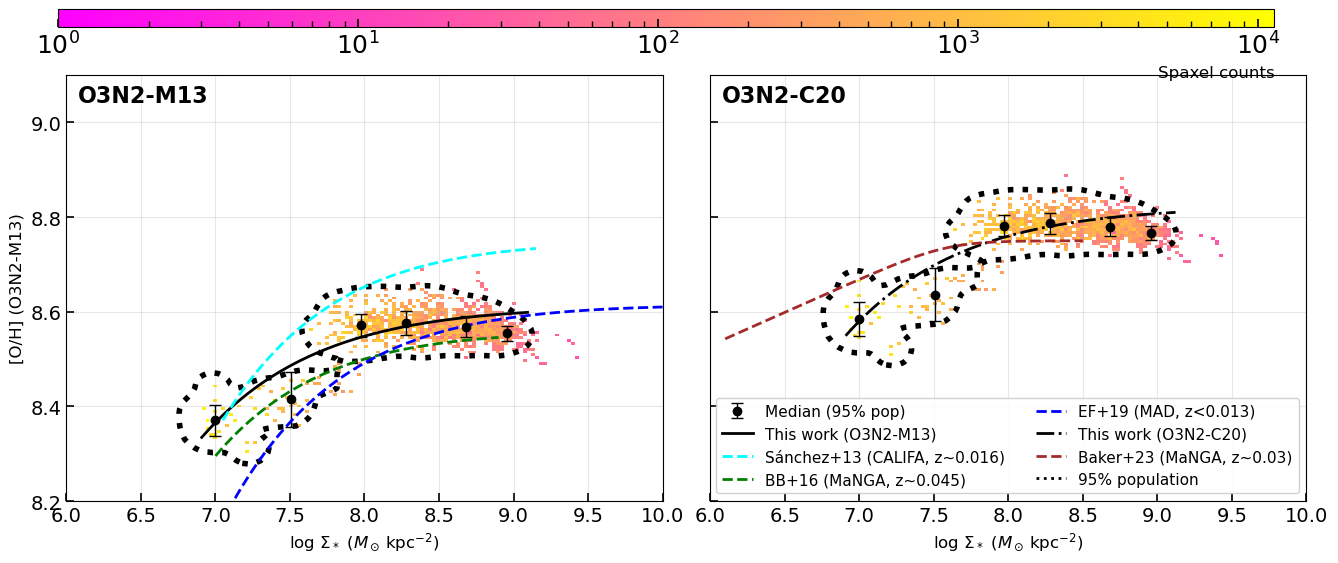


COMPLETED: Two-panel rMZR comparison (O3N2-M13 vs O3N2-C20)
Galaxies included: NGC4396, NGC4501
Excluded: NGC4383


In [14]:
# ------------------------------------------------------------------
# rMZR comparison: O3N2-M13 vs O3N2-C20 (HII only)
# Two-panel layout:
#   Left : rMZR 2D histogram (O3N2-M13) with literature curves
#   Right: rMZR 2D histogram (O3N2-C20) with Baker+23 curve
# Color-coded by spaxel counts (shared log-scale colorbar, spring colormap)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from pathlib import Path
from astropy.io import fits
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f"{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits") as h:
        sigM = h["LOGMASS_SURFACE_DENSITY"].data
    with fits.open(f"{gal}_v3tk_SNR200_gas_bin_maps_extended.fits") as h:
        sigSFR_HII = h["LOGSFR_SURFACE_DENSITY_HII"].data
        oh_o3n2_m13_HII = h["O_H_O3N2_M13_HII"].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
    """Calculate median and std in bins; keep bins with >= min_pixels unique points."""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        x_in_bin = x_data[in_bin]
        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_pixels:
            x_median = np.median(x_in_bin)
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(x_median)
            valid_bin_indices.append(i)
    return (np.array(valid_centers), np.array(medians), np.array(stds), np.array(counts), np.array(valid_bin_indices))

def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
    """Return mask for points inside the 95% density contour within given ranges."""
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if not np.any(mask_finite):
        empty_mask = np.zeros_like(x_vals, dtype=bool)
        return (empty_mask, None, None) if return_contour else empty_mask
    x = x_vals[mask_finite]
    y = y_vals[mask_finite]
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
    H_flat = np.sort(H_smooth.ravel())[::-1]
    H_cumsum = np.cumsum(H_flat)
    level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
    level_95 = H_flat[level_idx]
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_idx = (x - x_range[0]) / dx - 0.5
    y_idx = (y - y_range[0]) / dy - 0.5
    densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode="constant", cval=0.0)
    mask_local = densities >= level_95
    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local
    if return_contour:
        return full_mask, level_95, (X, Y, H_smooth)
    return full_mask

def compute_spaxel_counts(x_vals, y_vals, x_range, y_range, nbins=150):
    """Assign per-point counts from a 2D histogram over the requested range."""
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    H, xedges, yedges = np.histogram2d(x_vals[mask_finite], y_vals[mask_finite], bins=nbins, range=[x_range, y_range])
    x_idx = np.clip(np.digitize(x_vals, xedges) - 1, 0, nbins - 1)
    y_idx = np.clip(np.digitize(y_vals, yedges) - 1, 0, nbins - 1)
    counts = np.zeros_like(x_vals, dtype=float)
    counts[mask_finite] = H[x_idx[mask_finite], y_idx[mask_finite]]
    return counts, H

def plot_literature_mzr_fits(ax, show_legend=True):
    """Overlay literature rMZR curves (Sánchez+13, BB+16, EF+19)."""
    plot_data = []
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.74, 0.013, 9.50
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, "Sánchez+13 (CALIFA, z~0.016)", "--", "cyan"))
    x_bb = np.linspace(7.0, 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, "BB+16 (MaNGA, z~0.045)", "--", "green"))
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef17 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef17, "EF+19 (MAD, z<0.013)", "--", "blue"))
    handles = []
    for x, y, label, linestyle, color in plot_data:
        (line,) = ax.plot(x, y, label=label if show_legend else None, linewidth=2, linestyle=linestyle, color=color)
        handles.append(line)
    return handles

def plot_literature_baker(ax, show_legend=True):
    """Overlay Baker+23 collapsed rFMR curve."""
    plot_data = []
    x_baker = np.linspace(6.1, 8.5, 200)
    logSigmaSFR_ref = -2.0
    Z0_B = 8.75
    gamma_B = 0.14
    phi_B = 2.73
    m0_B = 8.58
    m1_B = 0.50
    logM0_B = m0_B + m1_B * logSigmaSFR_ref
    M0_B = 10.0 ** logM0_B
    Sigma_star_B = 10.0 ** x_baker
    y_baker23 = Z0_B - (gamma_B / phi_B) * np.log10(1.0 + (Sigma_star_B / M0_B) ** (-phi_B))
    plot_data.append((x_baker, y_baker23, "Baker+23 (MaNGA, z~0.03)", "--", "brown"))
    handles = []
    for x, y, label, linestyle, color in plot_data:
        (line,) = ax.plot(x, y, label=label if show_legend else None, linewidth=2, linestyle=linestyle, color=color)
        handles.append(line)
    return handles

bins = sorted(Path(".").glob("*_v3tk_SNR200_spatial_binning_maps_extended.fits"))
galaxies = [f.name.split("_")[0] for f in bins]
excluded_galaxies = {"NGC4383"}
included_galaxies = []
all_logSigmaM_HII = []
all_oh_o3n2_m13_HII = []
all_oh_o3n2_c20_HII = []

print("=" * 80)
print("Collecting data from all galaxies for HII regions (O3N2-M13 and O3N2-C20)...")
print("=" * 80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue
    bin_file = Path(f"{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits")
    gas_file = Path(f"{gal}_v3tk_SNR200_gas_bin_maps_extended.fits")
    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (logSigmaM, _, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
        with fits.open(gas_file) as h:
            oh_o3n2_c20_HII = h["O_H_O3N2_C20_HII"].data
        common_mask_m13 = np.isfinite(logSigmaM) & np.isfinite(oh_o3n2_m13_HII)
        common_mask_c20 = np.isfinite(logSigmaM) & np.isfinite(oh_o3n2_c20_HII)
        print(f"  {gal}: HII pixels M13={np.sum(common_mask_m13)}, C20={np.sum(common_mask_c20)}")
        all_logSigmaM_HII.extend(logSigmaM[common_mask_m13].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_m13].flatten())
        all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_c20].flatten())
    else:
        print(f"  {gal}: Data files not found")

all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)
print(f"\nTotal combined pixels (HII) M13: {len(all_oh_o3n2_m13_HII)}, C20: {len(all_oh_o3n2_c20_HII)}")

# Plot setup
common_ylim = (8.2, 9.1)
x_range_rMZR = (6, 10)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True, sharex=True)
plt.subplots_adjust(wspace=0.08, top=0.82)
ax_left, ax_right = axes

# Left panel: O3N2-M13
print("\n--- Left panel: O3N2-M13 rMZR ---")
mask_m13 = np.isfinite(all_logSigmaM_HII) & np.isfinite(all_oh_o3n2_m13_HII)
hist_m13, xedges_m13, yedges_m13 = np.histogram2d(
    all_logSigmaM_HII[mask_m13],
    all_oh_o3n2_m13_HII[mask_m13],
    bins=150,
    range=[x_range_rMZR, common_ylim],
)
mask_95_m13, level_95_m13, contour_data_m13 = compute_density_mask(all_logSigmaM_HII, all_oh_o3n2_m13_HII, x_range_rMZR, common_ylim, return_contour=True)
img_m13 = ax_left.pcolormesh(
    xedges_m13,
    yedges_m13,
    np.ma.masked_where(hist_m13.T == 0, hist_m13.T),
    cmap="spring",
    norm=LogNorm(vmin=1),
    shading="auto",
)
ax_left.contour(contour_data_m13[0], contour_data_m13[1], contour_data_m13[2].T, levels=[level_95_m13], colors="k", linewidths=4, linestyles=":")
mass_centers_m13, medians_m13, stds_m13, counts_median_m13, valid_idx_m13 = calculate_binned_stats(all_logSigmaM_HII[mask_95_m13], all_oh_o3n2_m13_HII[mask_95_m13], bin_width=0.4, min_pixels=20)
median_left = None
if len(mass_centers_m13) > 1:
    median_left = ax_left.errorbar(mass_centers_m13, medians_m13, yerr=stds_m13, fmt="o", color="k", markersize=6, linewidth=1, capsize=4, label="Median (95% pop)")
p0 = [8.5, 0.0002, 12.5]
bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])
fit_line_left = None
x_fit_m13 = None
y_fit_m13 = None
try:
    popt_m13, pcov_m13 = curve_fit(mzr_model, all_logSigmaM_HII[mask_95_m13], all_oh_o3n2_m13_HII[mask_95_m13], p0=p0, bounds=bounds, maxfev=5000)
    x_fit_m13 = np.linspace(np.min(all_logSigmaM_HII[mask_95_m13]), np.max(all_logSigmaM_HII[mask_95_m13]), 150)
    y_fit_m13 = mzr_model(x_fit_m13, *popt_m13)
    fit_line_left, = ax_left.plot(x_fit_m13, y_fit_m13, "k-", linewidth=2, label="This work (O3N2-M13)")
    perr_m13 = np.sqrt(np.diag(pcov_m13))
    print(f"M13 fit: a={popt_m13[0]:.3f} ± {perr_m13[0]:.3f}, b={popt_m13[1]:.5f} ± {perr_m13[1]:.5f}, c={popt_m13[2]:.3f} ± {perr_m13[2]:.3f}")
except Exception as e:
    print(f"M13 fit failed: {e}")
lit_handles_left = plot_literature_mzr_fits(ax_left, show_legend=True)

ax_left.set_ylabel("[O/H] (O3N2-M13)", fontsize=12)
ax_left.set_xlim(*x_range_rMZR)
ax_left.set_ylim(*common_ylim)
ax_left.grid(True, alpha=0.3)
ax_left.text(0.02, 0.98, "O3N2-M13", transform=ax_left.transAxes, ha="left", va="top", fontsize=16, fontweight="bold")

# Right panel: O3N2-C20
print("\n--- Right panel: O3N2-C20 rMZR ---")
mask_c20 = np.isfinite(all_logSigmaM_HII) & np.isfinite(all_oh_o3n2_c20_HII)
hist_c20, xedges_c20, yedges_c20 = np.histogram2d(
    all_logSigmaM_HII[mask_c20],
    all_oh_o3n2_c20_HII[mask_c20],
    bins=150,
    range=[x_range_rMZR, common_ylim],
)
mask_95_c20, level_95_c20, contour_data_c20 = compute_density_mask(all_logSigmaM_HII, all_oh_o3n2_c20_HII, x_range_rMZR, common_ylim, return_contour=True)
img_c20 = ax_right.pcolormesh(
    xedges_c20,
    yedges_c20,
    np.ma.masked_where(hist_c20.T == 0, hist_c20.T),
    cmap="spring",
    norm=LogNorm(vmin=1),
    shading="auto",
)
ax_right.contour(contour_data_c20[0], contour_data_c20[1], contour_data_c20[2].T, levels=[level_95_c20], colors="k", linewidths=4, linestyles=":")
mass_centers_c20, medians_c20, stds_c20, counts_median_c20, valid_idx_c20 = calculate_binned_stats(all_logSigmaM_HII[mask_95_c20], all_oh_o3n2_c20_HII[mask_95_c20], bin_width=0.4, min_pixels=20)
fit_line_right = None
median_right = None
x_fit_c20 = None
y_fit_c20 = None
if len(mass_centers_c20) > 1:
    median_right = ax_right.errorbar(mass_centers_c20, medians_c20, yerr=stds_c20, fmt="o", color="k", markersize=6, linewidth=1, capsize=4, label=None)
    try:
        popt_c20, pcov_c20 = curve_fit(mzr_model, all_logSigmaM_HII[mask_95_c20], all_oh_o3n2_c20_HII[mask_95_c20], p0=p0, bounds=bounds, maxfev=5000)
        x_fit_c20 = np.linspace(np.min(all_logSigmaM_HII[mask_95_c20]), np.max(all_logSigmaM_HII[mask_95_c20]), 150)
        y_fit_c20 = mzr_model(x_fit_c20, *popt_c20)
        fit_line_right, = ax_right.plot(x_fit_c20, y_fit_c20, "k-.", linewidth=2, label="This work (O3N2-C20)")
        perr_c20 = np.sqrt(np.diag(pcov_c20))
        print(f"C20 fit: a={popt_c20[0]:.3f} ± {perr_c20[0]:.3f}, b={popt_c20[1]:.5f} ± {perr_c20[1]:.5f}, c={popt_c20[2]:.3f} ± {perr_c20[2]:.3f}")
    except Exception as e:
        print(f"C20 fit failed: {e}")
baker_handles = plot_literature_baker(ax_right, show_legend=True)
ax_right.set_xlim(*x_range_rMZR)
ax_right.set_ylim(*common_ylim)
ax_right.grid(True, alpha=0.3)
ax_right.set_xlabel(r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12)
ax_left.set_xlabel(r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12)
ax_right.text(0.02, 0.98, "O3N2-C20", transform=ax_right.transAxes, ha="left", va="top", fontsize=16, fontweight="bold")

# # Show both fits on both panels when available
# fit_line_left_on_right = None
# fit_line_right_on_left = None
# if x_fit_m13 is not None and y_fit_m13 is not None:
#     fit_line_left_on_right, = ax_right.plot(x_fit_m13, y_fit_m13, "k-", linewidth=2, alpha=0.7, label=None)
# if x_fit_c20 is not None and y_fit_c20 is not None:
#     fit_line_right_on_left, = ax_left.plot(x_fit_c20, y_fit_c20, "k-.", linewidth=2, alpha=0.7, label=None)

# Consolidated legend on right panel
contour_handle = Line2D([0], [0], color="k", linestyle=":", linewidth=2, label="95% population")
legend_handles = []
legend_labels = []
for h in [median_left, fit_line_left]:
    if h:
        legend_handles.append(h)
        legend_labels.append(h.get_label())
for h in lit_handles_left:
    legend_handles.append(h)
    legend_labels.append(h.get_label())
for h in [fit_line_right]:
    if h:
        legend_handles.append(h)
        legend_labels.append(h.get_label())
for h in baker_handles:
    legend_handles.append(h)
    legend_labels.append(h.get_label())
legend_handles.append(contour_handle)
legend_labels.append(contour_handle.get_label())
if legend_handles:
    ax_right.legend(legend_handles, legend_labels, loc="lower right", fontsize=11, framealpha=0.9, ncol=2)

# Shared log-scale colorbar (top, spanning both panels)
vmax_shared = np.nanmax([hist_m13.max(), hist_c20.max()]) if hist_m13.size and hist_c20.size else None
if vmax_shared is not None and vmax_shared > 0:
    norm = LogNorm(vmin=1, vmax=vmax_shared)
    img_m13.set_norm(norm)
    img_c20.set_norm(norm)
    cax = fig.add_axes([0.12, 0.9, 0.76, 0.03])
    cbar = fig.colorbar(img_m13, cax=cax, orientation="horizontal")
    cbar.set_label("Spaxel counts", fontsize=12, loc="right")
    cbar.ax.tick_params(labelsize=18)
    cbar.cmap = plt.cm.spring

# plt.savefig("Plot_Paper_1_referee/MAUVE_MUSE_rMZR_O3N2M13_vs_C20_counts.png", dpi=600, bbox_inches="tight")
# plt.savefig("Plot_Paper_1_referee/MAUVE_MUSE_rMZR_O3N2M13_vs_C20_counts.pdf", bbox_inches="tight")
plt.show()

print("\n" + "=" * 80)
print("COMPLETED: Two-panel rMZR comparison (O3N2-M13 vs O3N2-C20)")
print("=" * 80)
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")

In [15]:
# # ------------------------------------------------------------------
# # Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# # Using O3N2-M13 indicator only
# # 2x2 subplot layout:
# #   Top-left: rMZR scatter
# #   Top-right: Z_gas-Σ_SFR scatter
# #   Bottom-left: rMZR median trends
# #   Bottom-right: Z_gas-Σ_SFR median trends
# # ------------------------------------------------------------------
# import numpy as np
# import matplotlib.pyplot as plt
# from pathlib import Path
# from astropy.io import fits
# import scipy.stats as stats
# import scipy.ndimage as ndimage
# from scipy.optimize import curve_fit

# def load_maps_o3n2_m13(gal):
#     """Load O3N2-M13 metallicity calibration for HII regions"""
#     with fits.open(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits') as h:
#         sigM = h['LOGMASS_SURFACE_DENSITY'].data
#     with fits.open(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits') as h:
#         sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
#         oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
#     return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

# def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
#     """Calculate median and std in bins - only keep bins with >= min_pixels unique datapoints"""
#     x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
#     bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
#     medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
#     for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
#         in_bin = (x_data >= bin_start) & (x_data < bin_end)
#         y_in_bin = y_data[in_bin]
#         if len(np.unique(y_in_bin)) >= min_pixels:
#             medians.append(np.median(y_in_bin))
#             stds.append(np.std(y_in_bin))
#             counts.append(len(y_in_bin))
#             valid_centers.append(bin_centers[i])
#             valid_bin_indices.append(i)
#     return (np.array(valid_centers), np.array(medians), np.array(stds), np.array(counts), np.array(valid_bin_indices))

# def mzr_model(x, a, b, c):
#     return a + b * (x - c) * np.exp(-(x - c))

# def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
#     """Return mask for points inside the 95% density contour within given ranges."""
#     mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
#     if not np.any(mask_finite):
#         empty_mask = np.zeros_like(x_vals, dtype=bool)
#         return (empty_mask, None, None) if return_contour else empty_mask
#     x = x_vals[mask_finite]
#     y = y_vals[mask_finite]
#     H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
#     H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
#     H_flat = np.sort(H_smooth.ravel())[::-1]
#     H_cumsum = np.cumsum(H_flat)
#     level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
#     level_95 = H_flat[level_idx]
#     x_centers = (xedges[:-1] + xedges[1:]) / 2
#     y_centers = (yedges[:-1] + yedges[1:]) / 2
#     X, Y = np.meshgrid(x_centers, y_centers)
#     dx = (x_range[1] - x_range[0]) / nbins
#     dy = (y_range[1] - y_range[0]) / nbins
#     x_idx = (x - x_range[0]) / dx - 0.5
#     y_idx = (y - y_range[0]) / dy - 0.5
#     densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
#     mask_local = densities >= level_95
#     full_mask = np.zeros_like(x_vals, dtype=bool)
#     full_mask[np.where(mask_finite)[0]] = mask_local
#     if return_contour:
#         return full_mask, level_95, (X, Y, H_smooth)
#     return full_mask

# def plot_literature_mzr_fits(ax, show_legend=True):
#     plot_data = []
#     x_sanchez = np.linspace(7.05, 9.15, 200)
#     a5, b5, c5 = 8.74, 0.013, 9.50
#     y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
#     plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', ':', 'olive'))
#     x_bb = np.linspace(7., 8.9, 200)
#     a2, b2, c2 = 8.55, 0.014, 9.14
#     y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
#     plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', '--', 'brown'))
#     x_ef = np.linspace(6.5, 10.0, 200)
#     a4, b4, c4 = 8.61, 0.008, 10.0
#     y_ef17 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
#     plot_data.append((x_ef, y_ef17, 'Erroz-Ferrer+17', '-.', 'pink'))
#     for x, y, label, linestyle, color in plot_data:
#         ax.plot(x, y, label=label if show_legend else None, linewidth=2, linestyle=linestyle, color=color)

# bins = sorted(Path('.').glob('*_v3tk_SNR200_spatial_binning_maps_extended.fits'))
# galaxies = [f.name.split('_')[0] for f in bins]
# excluded_galaxies = {'NGC4383'}
# included_galaxies = []
# all_logSigmaM_HII = []
# all_logSigmaSFR_HII = []
# all_oh_o3n2_m13_HII = []

# print("="*80)
# print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
# print("="*80)

# for gal in galaxies:
#     if gal in excluded_galaxies:
#         print(f"  {gal}: excluded from analysis")
#         continue
#     bin_file = Path(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits')
#     gas_file = Path(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits')
#     if bin_file.exists() and gas_file.exists():
#         included_galaxies.append(gal)
#         (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
#         common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII))
#         print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
#         all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
#         all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
#         all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
#     else:
#         print(f"  {gal}: Data files not found")

# all_logSigmaM_HII = np.array(all_logSigmaM_HII)
# all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
# all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
# print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# print("\n" + "="*80)
# print("STEP 2: Defining 8 SFR bins for rMZR")
# print("="*80)
# n_bins = 8
# sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
# bin_labels = ['<-3.5', '-3.5–-3.0', '-3.0–-2.5', '-2.5–-2.0', '-2.0–-1.5', '-1.5–-1.0', '-1.0–-0.5', '>-0.5']
# for i, label in enumerate(bin_labels):
#     print(f"  Bin {i+1}: {label}")
# colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# print("\n" + "="*80)
# print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
# print("="*80)
# n_bins_sigmaM = 8
# sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]
# bin_labels_sigmaM = ['<6.5', '6.5–7.0', '7.0–7.5', '7.5–8.0', '8.0–8.5', '8.5–9.0', '9.0–9.5', '>9.5']
# for i, label in enumerate(bin_labels_sigmaM):
#     print(f"  Bin {i+1}: {label}")
# colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# print("\n" + "="*80)
# print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
# print("="*80)
# common_ylim = (8.2, 8.9)
# x_range_rMZR = (6, 10)
# x_range_Zgas = (-5.0, 0.5)
# print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
# plt.subplots_adjust(wspace=0.05, hspace=0.05)
# oh_data_HII = all_oh_o3n2_m13_HII
# calib_name_HII = 'O3N2-M13'
# print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
# print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
# ax_rMZR_scatter = axes[0, 0]
# ax_Zgas_scatter = axes[0, 1]
# ax_rMZR_median = axes[1, 0]
# ax_Zgas_median = axes[1, 1]

# print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")
# legend_handles_sfr, legend_labels_sfr = [], []
# valid_bins_rMZR = 0
# for i in range(n_bins):
#     in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i + 1])
#     n_pixels_HII = np.sum(in_bin_HII)
#     if n_pixels_HII >= 10:
#         x_bin_all = all_logSigmaM_HII[in_bin_HII]
#         y_bin_all = oh_data_HII[in_bin_HII]
#         scatter_hii = ax_rMZR_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sfr[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
#         legend_handles_sfr.append(scatter_hii)
#         legend_labels_sfr.append(bin_labels[i])
#         mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
#         x_bin = x_bin_all[mask_95_bin]
#         y_bin = y_bin_all[mask_95_bin]
#         if len(x_bin) >= 10:
#             mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_bin, y_bin, bin_width=0.4, min_pixels=20)
#             if len(mass_centers_HII) > 1:
#                 ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, color=colors_sfr[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
#                 for j in range(len(valid_bin_indices_HII) - 1):
#                     current_bin_idx = valid_bin_indices_HII[j]
#                     next_bin_idx = valid_bin_indices_HII[j + 1]
#                     if next_bin_idx - current_bin_idx == 1:
#                         ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sfr[i], linewidth=2, alpha=0.8)
#                 valid_bins_rMZR += 1

# ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
# ax_rMZR_scatter.grid(True, alpha=0.3)
# ax_rMZR_scatter.set_xlim(*x_range_rMZR)
# ax_rMZR_scatter.set_ylim(common_ylim)
# ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
# ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
# ax_rMZR_median.grid(True, alpha=0.3)
# ax_rMZR_median.set_xlim(*x_range_rMZR)
# ax_rMZR_median.set_ylim(common_ylim)
# legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR})$ bins', title_fontsize=12)
# ax_rMZR_median.add_artist(legend1)
# print(f"  rMZR valid bins: {valid_bins_rMZR}")

# print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")
# legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
# valid_bins_Zgas = 0
# for i in range(n_bins_sigmaM):
#     in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i + 1])
#     n_pixels_HII = np.sum(in_bin_HII)
#     if n_pixels_HII >= 10:
#         x_bin_all = all_logSigmaSFR_HII[in_bin_HII]
#         y_bin_all = oh_data_HII[in_bin_HII]
#         scatter_hii = ax_Zgas_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sigmaM[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
#         legend_handles_sigmaM.append(scatter_hii)
#         mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_Zgas, common_ylim)
#         x_bin = x_bin_all[mask_95_bin]
#         y_bin = y_bin_all[mask_95_bin]
#         spearman_text = "N/A"
#         if len(x_bin) > 1:
#             y_mean, y_std = np.nanmean(y_bin), np.nanstd(y_bin)
#             x_mean, x_std = np.nanmean(x_bin), np.nanstd(x_bin)
#             mask_clip = (np.abs(y_bin - y_mean) < 3 * y_std) & (np.abs(x_bin - x_mean) < 3 * x_std)
#             x_clipped = x_bin[mask_clip]
#             y_clipped = y_bin[mask_clip]
#             sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_clipped, y_clipped, bin_width=0.4, min_pixels=20)
#             if len(sfr_centers_HII) > 1:
#                 if len(x_clipped) > 10:
#                     corr, _ = stats.spearmanr(x_clipped, y_clipped)
#                     spearman_text = f"{corr:.2f}"
#                 ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, color=colors_sigmaM[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
#                 for j in range(len(valid_bin_indices_HII) - 1):
#                     current_bin_idx = valid_bin_indices_HII[j]
#                     next_bin_idx = valid_bin_indices_HII[j + 1]
#                     if next_bin_idx - current_bin_idx == 1:
#                         ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sigmaM[i], linewidth=2, alpha=0.8)
#                 valid_bins_Zgas += 1
#         legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

# ax_Zgas_scatter.grid(True, alpha=0.3)
# ax_Zgas_scatter.set_xlim(*x_range_Zgas)
# ax_Zgas_scatter.set_ylim(common_ylim)
# ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
# ax_Zgas_median.grid(True, alpha=0.3)
# ax_Zgas_median.set_xlim(*x_range_Zgas)
# ax_Zgas_median.set_ylim(common_ylim)
# ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', ncol=3, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_*)$ bins with Spearman coefficient', title_fontsize=12)
# print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1_referee/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1_referee/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
# plt.show()

# print("\n" + "="*80)
# print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
# print("="*80)
# print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
# print(f"Galaxies included: {', '.join(included_galaxies)}")
# print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
# print("\nPanel summary:")
# print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
# print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
# print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
# print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
# print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  NGC4396: HII=120537 pixels
  NGC4501: HII=299577 pixels

Total combined pixels (HII): 420114

STEP 2: Defining 8 SFR bins for rMZR
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5–-2.0
  Bin 5: -2.0–-1.5
  Bin 6: -1.5–-1.0
  Bin 7: -1.0–-0.5
  Bin 8: >-0.5

STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR
  Bin 1: <6.5
  Bin 2: 6.5–7.0
  Bin 3: 7.0–7.5
  Bin 4: 7.5–8.0
  Bin 5: 8.0–8.5
  Bin 6: 8.5–9.0
  Bin 7: 9.0–9.5
  Bin 8: >9.5

STEP 4: Creating combined 2x2 plot (O3N2-M13 only)

Using uniform y-axis range: 8.2 to 8.9

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.303 to 8.691

--- Processing rMZR (8 Σ_SFR bins) ---
    rMZR bin 4 -2.5–-2.0: typical yerr (median σ/√N) = 0.0001
    rMZR bin 5 -2.0–-1.5: typical yerr (median σ/√N) = 0.0001
    rMZR bin 6 -1.5–-1.0: typical yerr (median σ/√N) = 0.0002
  rMZR valid bins: 3

--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---


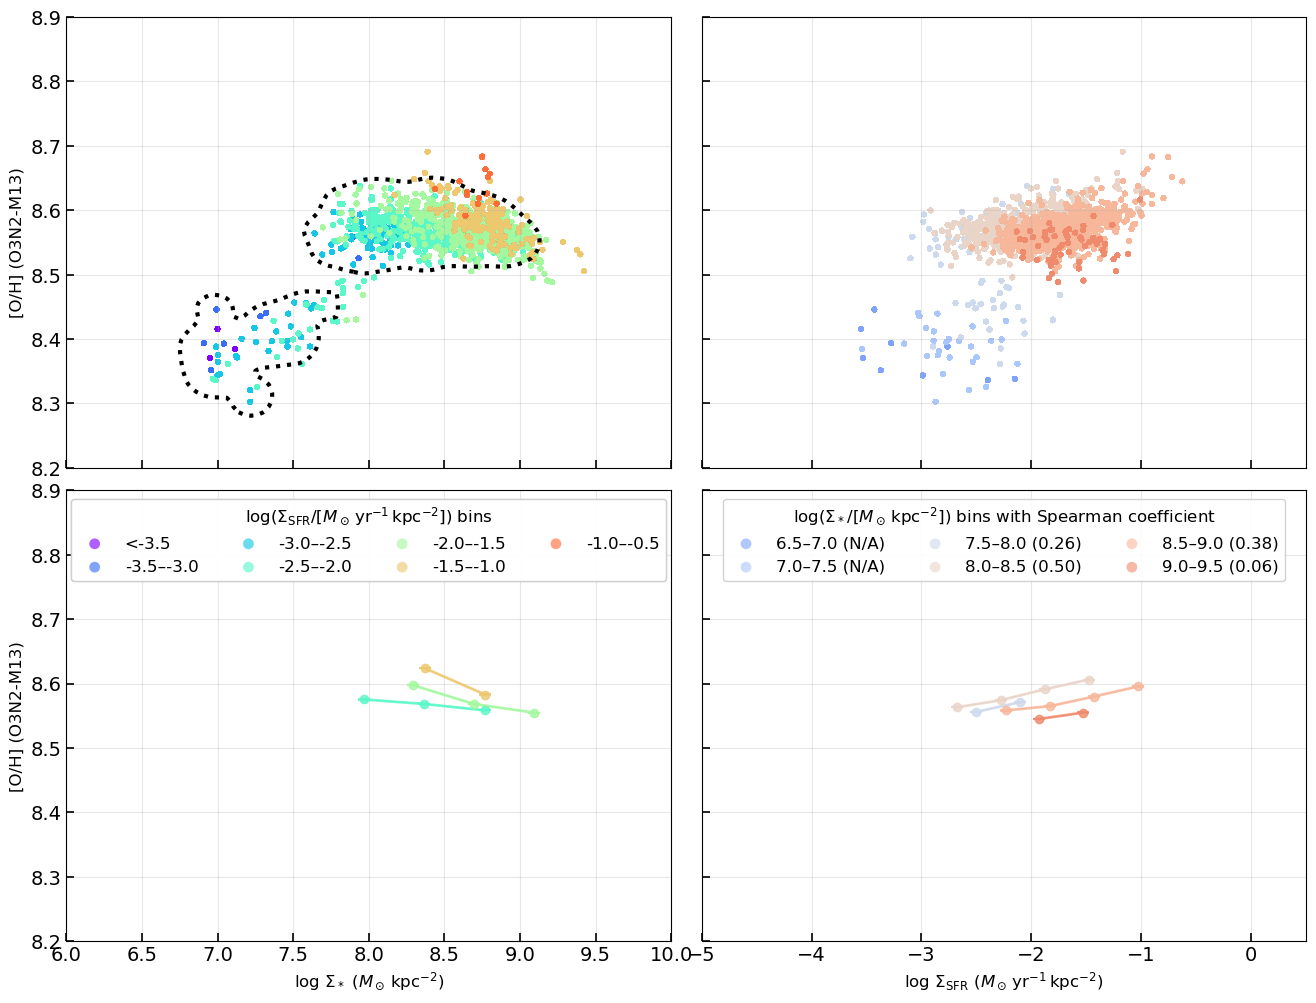


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 2 galaxies
Galaxies included: NGC4396, NGC4501
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [16]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= min_pixels unique datapoints"""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    return (np.array(valid_centers), np.array(medians), np.array(stds), np.array(counts), np.array(valid_bin_indices))

def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
    """Return mask for points inside the 95% density contour within given ranges."""
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if not np.any(mask_finite):
        empty_mask = np.zeros_like(x_vals, dtype=bool)
        return (empty_mask, None, None) if return_contour else empty_mask
    x = x_vals[mask_finite]
    y = y_vals[mask_finite]
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
    H_flat = np.sort(H_smooth.ravel())[::-1]
    H_cumsum = np.cumsum(H_flat)
    level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
    level_95 = H_flat[level_idx]
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_idx = (x - x_range[0]) / dx - 0.5
    y_idx = (y - y_range[0]) / dy - 0.5
    densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
    mask_local = densities >= level_95
    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local
    if return_contour:
        return full_mask, level_95, (X, Y, H_smooth)
    return full_mask

def plot_literature_mzr_fits(ax, show_legend=True):
    plot_data = []
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.74, 0.013, 9.50
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', ':', 'olive'))
    x_bb = np.linspace(7., 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', '--', 'brown'))
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef17 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef17, 'Erroz-Ferrer+17', '-.', 'pink'))
    for x, y, label, linestyle, color in plot_data:
        ax.plot(x, y, label=label if show_legend else None, linewidth=2, linestyle=linestyle, color=color)

bins = sorted(Path('.').glob('*_v3tk_SNR200_spatial_binning_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
included_galaxies = []
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue
    bin_file = Path(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits')
    gas_file = Path(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits')
    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII))
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)
n_bins = 8
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
bin_labels = ['<-3.5', '-3.5–-3.0', '-3.0–-2.5', '-2.5–-2.0', '-2.0–-1.5', '-1.5–-1.0', '-1.0–-0.5', '>-0.5']
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)
n_bins_sigmaM = 8
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]
bin_labels_sigmaM = ['<6.5', '6.5–7.0', '7.0–7.5', '7.5–8.0', '8.0–8.5', '8.5–9.0', '9.0–9.5', '>9.5']
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)
common_ylim = (8.2, 8.9)
x_range_rMZR = (6, 10)
x_range_Zgas = (-5.0, 0.5)
print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'
print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

mask_95_all_rMZR, level_95_all_rMZR, contour_data_rMZR = compute_density_mask(all_logSigmaM_HII, oh_data_HII, x_range_rMZR, common_ylim, return_contour=True)
max_typical_yerr_rMZR = np.nan
max_typical_yerr_Zgas = np.nan

print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")
legend_handles_sfr, legend_labels_sfr = [], []
valid_bins_rMZR = 0
for i in range(n_bins):
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i + 1])
    n_pixels_HII = np.sum(in_bin_HII)
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaM_HII[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sfr[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
        x_bin = x_bin_all[mask_95_bin]
        y_bin = y_bin_all[mask_95_bin]
        if len(x_bin) >= 10:
            mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_bin, y_bin, bin_width=0.4, min_pixels=20)
            if len(mass_centers_HII) > 1:
                yerr_HII = stds_HII / np.sqrt(counts_HII)
                typical_yerr = np.nanmedian(yerr_HII)
                print(f"    rMZR bin {i+1} {bin_labels[i]}: typical yerr (median σ/√N) = {typical_yerr:.4f}")
                if np.isfinite(typical_yerr):
                    max_typical_yerr_rMZR = np.nanmax([max_typical_yerr_rMZR, typical_yerr])
                ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=yerr_HII, color=colors_sfr[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sfr[i], linewidth=2, alpha=0.8)
                valid_bins_rMZR += 1

if contour_data_rMZR is not None and level_95_all_rMZR is not None:
    ax_rMZR_scatter.contour(contour_data_rMZR[0], contour_data_rMZR[1], contour_data_rMZR[2].T, levels=[level_95_all_rMZR], colors='k', linewidths=3, linestyles=':')
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(*x_range_rMZR)
ax_rMZR_scatter.set_ylim(common_ylim)
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(*x_range_rMZR)
ax_rMZR_median.set_ylim(common_ylim)
legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR}/[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}])$ bins', title_fontsize=12)
legend1_handles = getattr(legend1, "legend_handles", None)
if legend1_handles is None:
    legend1_handles = getattr(legend1, "legendHandles", [])
for handle in legend1_handles:
    try:
        handle.set_sizes([60])
    except Exception:
        pass
ax_rMZR_median.add_artist(legend1)
# if np.isfinite(max_typical_yerr_rMZR):
#     ax_rMZR_median.errorbar(x_range_rMZR[0] + 0.2, common_ylim[0] + 0.05, yerr=max_typical_yerr_rMZR, color='k', marker='o', markersize=4, linewidth=1, capsize=4, capthick=1.5)
print(f"  rMZR valid bins: {valid_bins_rMZR}")

print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")
legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i + 1])
    n_pixels_HII = np.sum(in_bin_HII)
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sigmaM[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
        legend_handles_sigmaM.append(scatter_hii)
        mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_Zgas, common_ylim)
        x_bin = x_bin_all[mask_95_bin]
        y_bin = y_bin_all[mask_95_bin]
        spearman_text = "N/A"
        if len(x_bin) > 1:
            y_mean, y_std = np.nanmean(y_bin), np.nanstd(y_bin)
            x_mean, x_std = np.nanmean(x_bin), np.nanstd(x_bin)
            mask_clip = (np.abs(y_bin - y_mean) < 3 * y_std) & (np.abs(x_bin - x_mean) < 3 * x_std)
            x_clipped = x_bin[mask_clip]
            y_clipped = y_bin[mask_clip]
            sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_clipped, y_clipped, bin_width=0.4, min_pixels=20)
            if len(sfr_centers_HII) > 1:
                if len(x_clipped) > 10:
                    corr, _ = stats.spearmanr(x_clipped, y_clipped)
                    spearman_text = f"{corr:.2f}"
                yerr_HII = stds_HII / np.sqrt(counts_HII)
                typical_yerr = np.nanmedian(yerr_HII)
                print(f"    Zgas-ΣSFR bin {i+1} {bin_labels_sigmaM[i]}: typical yerr (median σ/√N) = {typical_yerr:.4f}")
                if np.isfinite(typical_yerr):
                    max_typical_yerr_Zgas = np.nanmax([max_typical_yerr_Zgas, typical_yerr])
                ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=yerr_HII, color=colors_sigmaM[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sigmaM[i], linewidth=2, alpha=0.8)
                valid_bins_Zgas += 1
        legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(*x_range_Zgas)
ax_Zgas_scatter.set_ylim(common_ylim)
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(*x_range_Zgas)
ax_Zgas_median.set_ylim(common_ylim)
legend2 = ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', ncol=3, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}])$ bins with Spearman coefficient', title_fontsize=12)
legend2_handles = getattr(legend2, "legend_handles", None)
if legend2_handles is None:
    legend2_handles = getattr(legend2, "legendHandles", [])
for handle in legend2_handles:
    try:
        handle.set_sizes([60])
    except Exception:
        pass
# if np.isfinite(max_typical_yerr_Zgas):
#     ax_Zgas_median.errorbar(x_range_Zgas[0] + 0.2, common_ylim[0] + 0.05, yerr=max_typical_yerr_Zgas, color='k', marker='o', markersize=4, linewidth=1, capsize=4, capthick=1.5)
print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1_referee/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1_referee/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  NGC4396: HII=120537 pixels
  NGC4501: HII=299577 pixels

Total combined pixels (HII): 420114

STEP 2: Defining 8 SFR bins for rMZR
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5–-2.0
  Bin 5: -2.0–-1.5
  Bin 6: -1.5–-1.0
  Bin 7: -1.0–-0.5
  Bin 8: >-0.5

STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR
  Bin 1: <6.5
  Bin 2: 6.5–7.0
  Bin 3: 7.0–7.5
  Bin 4: 7.5–8.0
  Bin 5: 8.0–8.5
  Bin 6: 8.5–9.0
  Bin 7: 9.0–9.5
  Bin 8: >9.5

STEP 4: Creating combined 2x2 plot (O3N2-M13 only)

Using uniform y-axis range: 8.2 to 8.9

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.303 to 8.691

--- Processing rMZR (8 Σ_SFR bins) ---
    rMZR bin 4 -2.5–-2.0: typical yerr (median IQR) = 0.0239
    rMZR bin 5 -2.0–-1.5: typical yerr (median IQR) = 0.0268
    rMZR bin 6 -1.5–-1.0: typical yerr (median IQR) = 0.0277
  rMZR valid bins: 3

--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---
   

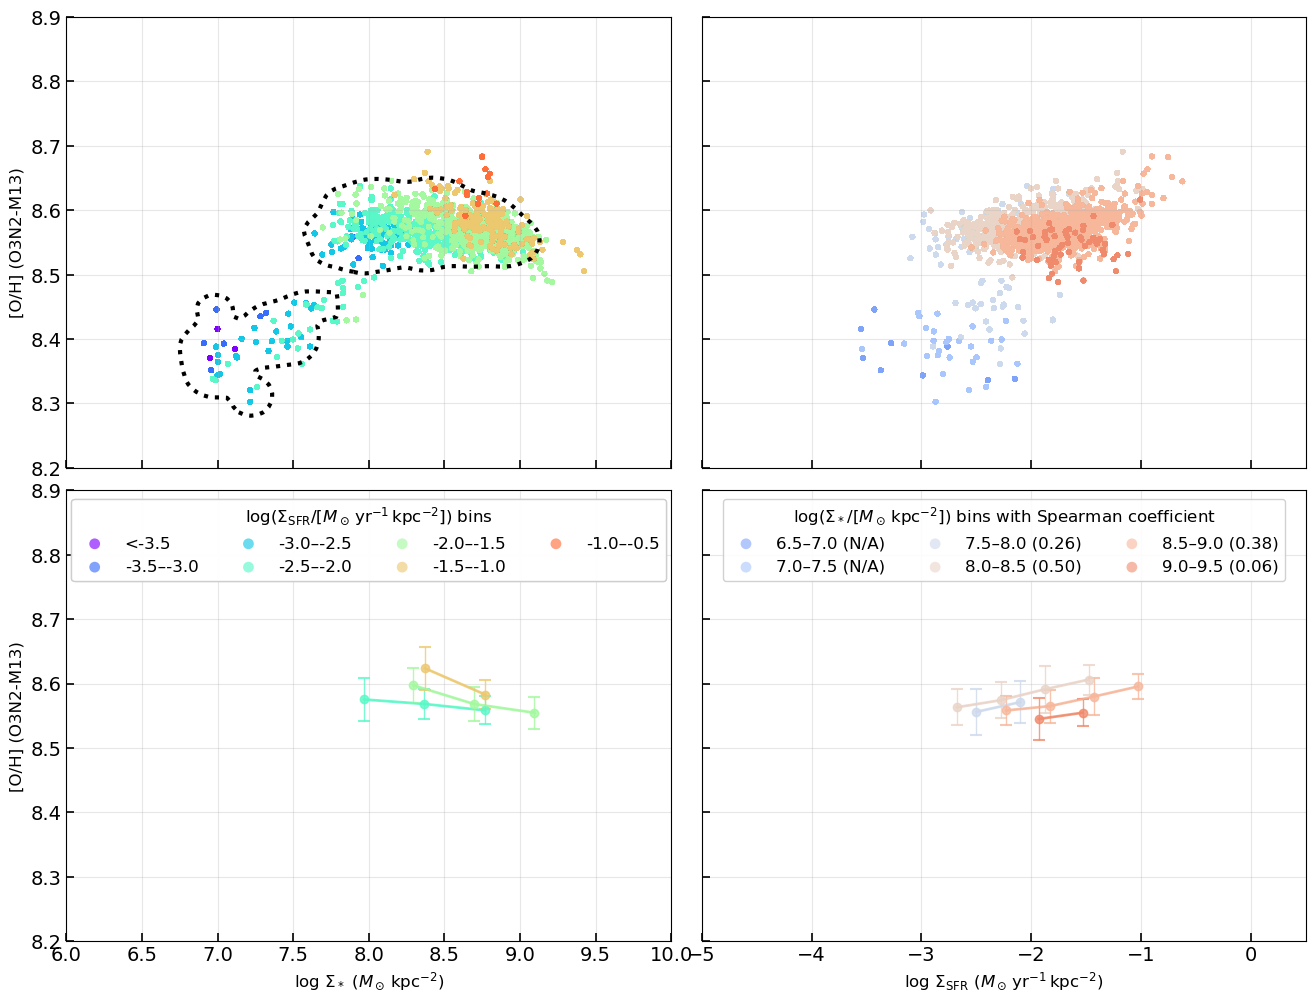


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 2 galaxies
Galaxies included: NGC4396, NGC4501
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [17]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
    """Calculate median and IQR in bins - only keep bins with >= min_pixels unique datapoints"""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    medians, iqrs, counts, valid_centers, valid_bin_indices = [], [], [], [], []
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_pixels:
            med = np.median(y_in_bin)
            q25, q75 = np.percentile(y_in_bin, [25, 75])
            iqr = q75 - q25
            medians.append(med)
            iqrs.append(iqr)
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    return (np.array(valid_centers), np.array(medians), np.array(iqrs), np.array(counts), np.array(valid_bin_indices))

def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
    """Return mask for points inside the 95% density contour within given ranges."""
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if not np.any(mask_finite):
        empty_mask = np.zeros_like(x_vals, dtype=bool)
        return (empty_mask, None, None) if return_contour else empty_mask
    x = x_vals[mask_finite]
    y = y_vals[mask_finite]
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
    H_flat = np.sort(H_smooth.ravel())[::-1]
    H_cumsum = np.cumsum(H_flat)
    level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
    level_95 = H_flat[level_idx]
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_idx = (x - x_range[0]) / dx - 0.5
    y_idx = (y - y_range[0]) / dy - 0.5
    densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
    mask_local = densities >= level_95
    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local
    if return_contour:
        return full_mask, level_95, (X, Y, H_smooth)
    return full_mask

def plot_literature_mzr_fits(ax, show_legend=True):
    plot_data = []
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.74, 0.013, 9.50
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', ':', 'olive'))
    x_bb = np.linspace(7., 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', '--', 'brown'))
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef17 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef17, 'Erroz-Ferrer+17', '-.', 'pink'))
    for x, y, label, linestyle, color in plot_data:
        ax.plot(x, y, label=label if show_legend else None, linewidth=2, linestyle=linestyle, color=color)

bins = sorted(Path('.').glob('*_v3tk_SNR200_spatial_binning_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
included_galaxies = []
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue
    bin_file = Path(f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits')
    gas_file = Path(f'{gal}_v3tk_SNR200_gas_bin_maps_extended.fits')
    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII))
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)
n_bins = 8
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
bin_labels = ['<-3.5', '-3.5–-3.0', '-3.0–-2.5', '-2.5–-2.0', '-2.0–-1.5', '-1.5–-1.0', '-1.0–-0.5', '>-0.5']
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)
n_bins_sigmaM = 8
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]
bin_labels_sigmaM = ['<6.5', '6.5–7.0', '7.0–7.5', '7.5–8.0', '8.0–8.5', '8.5–9.0', '9.0–9.5', '>9.5']
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)
common_ylim = (8.2, 8.9)
x_range_rMZR = (6, 10)
x_range_Zgas = (-5.0, 0.5)
print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'
print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

mask_95_all_rMZR, level_95_all_rMZR, contour_data_rMZR = compute_density_mask(all_logSigmaM_HII, oh_data_HII, x_range_rMZR, common_ylim, return_contour=True)
max_typical_yerr_rMZR = np.nan
max_typical_yerr_Zgas = np.nan

print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")
legend_handles_sfr, legend_labels_sfr = [], []
valid_bins_rMZR = 0
for i in range(n_bins):
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i + 1])
    n_pixels_HII = np.sum(in_bin_HII)
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaM_HII[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sfr[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
        x_bin = x_bin_all[mask_95_bin]
        y_bin = y_bin_all[mask_95_bin]
        if len(x_bin) >= 10:
            mass_centers_HII, medians_HII, iqrs_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_bin, y_bin, bin_width=0.4, min_pixels=20)
            if len(mass_centers_HII) > 1:
                yerr_HII = iqrs_HII
                typical_yerr = np.nanmedian(yerr_HII)
                print(f"    rMZR bin {i+1} {bin_labels[i]}: typical yerr (median IQR) = {typical_yerr:.4f}")
                if np.isfinite(typical_yerr):
                    max_typical_yerr_rMZR = np.nanmax([max_typical_yerr_rMZR, typical_yerr])
                ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=yerr_HII, color=colors_sfr[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sfr[i], linewidth=2, alpha=0.8)
                valid_bins_rMZR += 1

if contour_data_rMZR is not None and level_95_all_rMZR is not None:
    ax_rMZR_scatter.contour(contour_data_rMZR[0], contour_data_rMZR[1], contour_data_rMZR[2].T, levels=[level_95_all_rMZR], colors='k', linewidths=3, linestyles=':')
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(*x_range_rMZR)
ax_rMZR_scatter.set_ylim(common_ylim)
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(*x_range_rMZR)
ax_rMZR_median.set_ylim(common_ylim)
legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR}/[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}])$ bins', title_fontsize=12)
legend1_handles = getattr(legend1, "legend_handles", None)
if legend1_handles is None:
    legend1_handles = getattr(legend1, "legendHandles", [])
for handle in legend1_handles:
    try:
        handle.set_sizes([60])
    except Exception:
        pass
ax_rMZR_median.add_artist(legend1)
# if np.isfinite(max_typical_yerr_rMZR):
#     ax_rMZR_median.errorbar(x_range_rMZR[0] + 0.2, common_ylim[0] + 0.05, yerr=max_typical_yerr_rMZR, color='k', marker='o', markersize=4, linewidth=1, capsize=4, capthick=1.5)
print(f"  rMZR valid bins: {valid_bins_rMZR}")

print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")
legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i + 1])
    n_pixels_HII = np.sum(in_bin_HII)
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sigmaM[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
        legend_handles_sigmaM.append(scatter_hii)
        mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_Zgas, common_ylim)
        x_bin = x_bin_all[mask_95_bin]
        y_bin = y_bin_all[mask_95_bin]
        spearman_text = "N/A"
        if len(x_bin) > 1:
            y_mean, y_std = np.nanmean(y_bin), np.nanstd(y_bin)
            x_mean, x_std = np.nanmean(x_bin), np.nanstd(x_bin)
            mask_clip = (np.abs(y_bin - y_mean) < 3 * y_std) & (np.abs(x_bin - x_mean) < 3 * x_std)
            x_clipped = x_bin[mask_clip]
            y_clipped = y_bin[mask_clip]
            sfr_centers_HII, medians_HII, iqrs_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_clipped, y_clipped, bin_width=0.4, min_pixels=20)
            if len(sfr_centers_HII) > 1:
                if len(x_clipped) > 10:
                    corr, _ = stats.spearmanr(x_clipped, y_clipped)
                    spearman_text = f"{corr:.2f}"
                yerr_HII = iqrs_HII
                typical_yerr = np.nanmedian(yerr_HII)
                print(f"    Zgas-ΣSFR bin {i+1} {bin_labels_sigmaM[i]}: typical yerr (median IQR) = {typical_yerr:.4f}")
                if np.isfinite(typical_yerr):
                    max_typical_yerr_Zgas = np.nanmax([max_typical_yerr_Zgas, typical_yerr])
                ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=yerr_HII, color=colors_sigmaM[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sigmaM[i], linewidth=2, alpha=0.8)
                valid_bins_Zgas += 1
        legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(*x_range_Zgas)
ax_Zgas_scatter.set_ylim(common_ylim)
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(*x_range_Zgas)
ax_Zgas_median.set_ylim(common_ylim)
legend2 = ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', ncol=3, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}])$ bins with Spearman coefficient', title_fontsize=12)
legend2_handles = getattr(legend2, "legend_handles", None)
if legend2_handles is None:
    legend2_handles = getattr(legend2, "legendHandles", [])
for handle in legend2_handles:
    try:
        handle.set_sizes([60])
    except Exception:
        pass
# if np.isfinite(max_typical_yerr_Zgas):
#     ax_Zgas_median.errorbar(x_range_Zgas[0] + 0.2, common_ylim[0] + 0.05, yerr=max_typical_yerr_Zgas, color='k', marker='o', markersize=4, linewidth=1, capsize=4, capthick=1.5)
print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1_referee/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1_referee/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

SNR200 root: /Users/Igniz/Desktop/ICRAR/extended/SNR200
Original search roots:
  /Users/Igniz/Desktop/ICRAR/extended
  /Users/Igniz/Desktop/ICRAR/extended/SNR200
  /Users/Igniz/Desktop/ICRAR


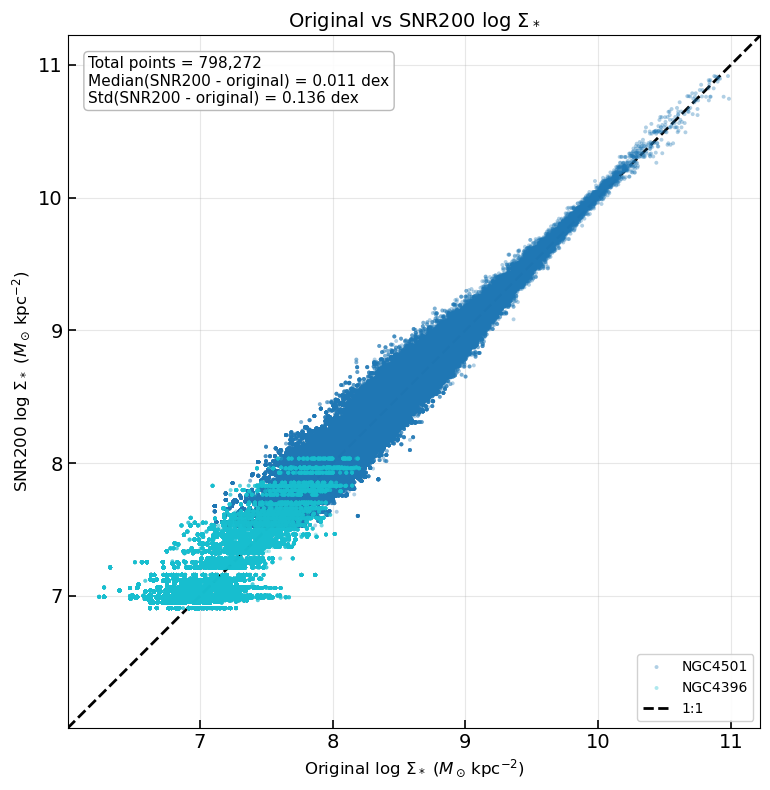

Matched original files:
  NGC4501: /Users/Igniz/Desktop/ICRAR/extended/NGC4501_spatial_binning_maps_extended.fits
  NGC4396: /Users/Igniz/Desktop/ICRAR/extended/NGC4396_spatial_binning_maps_extended.fits


In [18]:
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

def dedupe_paths(paths):
    unique_paths = []
    seen = set()
    for path in paths:
        path = path.resolve()
        if path.exists() and path not in seen:
            unique_paths.append(path)
            seen.add(path)
    return unique_paths

def find_snr200_root():
    cwd = Path.cwd().resolve()
    candidate_dirs = [cwd, cwd / 'SNR200', cwd.parent / 'SNR200']
    for directory in dedupe_paths(candidate_dirs):
        if any(directory.glob('*_v3tk_SNR200_spatial_binning_maps_extended.fits')):
            return directory
    raise FileNotFoundError('Could not find any *_v3tk_SNR200_spatial_binning_maps_extended.fits files.')

def find_original_file(gal, roots):
    direct_names = [
        f'{gal}_v3tk_spatial_binning_maps_extended.fits',
        f'{gal}_spatial_binning_maps_extended.fits',
    ]

    for root in roots:
        for name in direct_names:
            candidate = root / name
            if candidate.exists():
                return candidate

    for root in roots:
        for name in direct_names:
            matches = sorted(
                path for path in root.rglob(name)
                if 'SNR200' not in path.name and 'SNR200' not in str(path.parent)
            )
            if matches:
                return matches[0]

    return None

SNR200_ROOT = find_snr200_root()
ORIGINAL_ROOTS = dedupe_paths([
    SNR200_ROOT.parent,
    SNR200_ROOT.parent / 'original',
    Path.cwd(),
    *list(Path.cwd().parents)[:2],
])

snr200_files = sorted(SNR200_ROOT.glob('*_v3tk_SNR200_spatial_binning_maps_extended.fits'))
galaxies = [path.name.split('_')[0] for path in snr200_files]

print(f'SNR200 root: {SNR200_ROOT}')
print('Original search roots:')
for root in ORIGINAL_ROOTS:
    print(f'  {root}')

matched = []
missing = []

for gal in galaxies:
    snr200_file = SNR200_ROOT / f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits'
    original_file = find_original_file(gal, ORIGINAL_ROOTS)

    if original_file is None:
        missing.append(gal)
        continue

    with fits.open(original_file) as h_orig, fits.open(snr200_file) as h_snr:
        original_mass = h_orig['LOGMASS_SURFACE_DENSITY'].data
        snr200_mass = h_snr['LOGMASS_SURFACE_DENSITY'].data

    common_mask = np.isfinite(original_mass) & np.isfinite(snr200_mass)
    if np.any(common_mask):
        matched.append({
            'gal': gal,
            'original_file': original_file,
            'original_mass': original_mass[common_mask].ravel(),
            'snr200_mass': snr200_mass[common_mask].ravel(),
        })

if not matched:
    tried_names = ', '.join(f'{gal}_v3tk_spatial_binning_maps_extended.fits' for gal in galaxies)
    raise FileNotFoundError(
        'No original spatial-binning extended FITS files were found. '
        'Put the original files near the SNR200 directory or edit ORIGINAL_ROOTS in this cell. '
        f'Tried names like: {tried_names}'
    )

matched = sorted(matched, key=lambda item: (item['gal'] == 'NGC4396', item['gal']))

fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.tab10(np.linspace(0, 1, max(len(matched), 1)))

all_original = []
all_snr200 = []

for color, item in zip(colors, matched):
    x = item['original_mass']
    y = item['snr200_mass']
    all_original.append(x)
    all_snr200.append(y)
    zorder = 4 if item['gal'] == 'NGC4396' else 3
    ax.scatter(
        x,
        y,
        s=8,
        alpha=0.35,
        color=color,
        edgecolors='none',
        rasterized=True,
        zorder=zorder,
        label=item['gal'],
    )

all_original = np.concatenate(all_original)
all_snr200 = np.concatenate(all_snr200)
delta_mass = all_snr200 - all_original

min_mass = np.nanmin([all_original.min(), all_snr200.min()])
max_mass = np.nanmax([all_original.max(), all_snr200.max()])
pad = 0.05 * (max_mass - min_mass if max_mass > min_mass else 1.0)
plot_limits = (min_mass - pad, max_mass + pad)

ax.plot(plot_limits, plot_limits, 'k--', linewidth=2, label='1:1')
ax.set_xlim(*plot_limits)
ax.set_ylim(*plot_limits)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r'Original $\log\,\Sigma_*$ ($M_\odot\,\mathrm{kpc}^{-2}$)', fontsize=12)
ax.set_ylabel(r'SNR200 $\log\,\Sigma_*$ ($M_\odot\,\mathrm{kpc}^{-2}$)', fontsize=12)
ax.set_title(r'Original vs SNR200 $\log\,\Sigma_*$', fontsize=14)

summary_text = (
    f'Total points = {len(all_original):,}\n'
    f'Median(SNR200 - original) = {np.nanmedian(delta_mass):.3f} dex\n'
    f'Std(SNR200 - original) = {np.nanstd(delta_mass):.3f} dex'
)
ax.text(
    0.03,
    0.97,
    summary_text,
    transform=ax.transAxes,
    va='top',
    fontsize=11,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='0.7'),
)

ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

print('Matched original files:')
for item in matched:
    print(f"  {item['gal']}: {item['original_file']}")
if missing:
    print(f"Missing original files for: {', '.join(missing)}")
